# Energy spectra in 2D

In [1]:
import os
import sys
import gc
import math as m
import numpy as np
import scipy
import pandas as pd
import pylab
from scipy import *
from scipy.signal import butter, filtfilt, hilbert
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.append('/projects/DEIKE/cmartinb/jupyter_notebook/project_specific/turbulence')
sys.path.append('/projects/DEIKE/cmartinb/functions')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from prepare import load_object, save_object, field
#from defs import Case, Interface2D
#from phase import extract_phase
from funciones import * 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pylab
import numpy as np
from scipy.signal import find_peaks
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.interpolate
os.chdir('/projects/DEIKE/cmartinb/')

In [2]:
params = {'legend.fontsize': 'x-Large',
          'figure.figsize': (15, 6),
         'axes.labelsize': 30,
         'axes.titlesize':30,
         'xtick.labelsize':30,
         'ytick.labelsize':30,
    'font.family': 'STIXGeneral', 
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'text.usetex': True, # Enable LaTeX rendering
}

plt.rcParams.update(params)
pylab.rcParams.update(params)


In [3]:
# DEFINE CASE SO WE CAN AUTHOMATIZE IT 
kpHs = '0p08' # 0p16 
uoc = '0p25' # 0p50 0p75
reW = '2.5e4' #1.0e5
reA = 720
maxLevel = 10
Bo=200

if reW == '1.0e5':
    Re_water = 1 * 10**5
else:
    Re_water = 2.5 * 10**4

if maxLevel == 11:
    N = 1024
else:
    N = 512 

#Common parameters 
kp = 4
u = 0.25
lambdap = 2*m.pi/kp

rho1 = 1
rho2 = 1.25*10**(-3)

L0 = 2*np.pi;


ak, c, omegap, nu_water, g, uoc_val, sigma, Tp= calculate_parameters(kpHs, uoc , u ,kp, Bo, rho1, rho2)
print('ak is', ak, 'c is' ,c, 'w_p$ is', omegap, '$\nu_w$ is' , nu_water, 'g is' ,g, 'N', N)

ak is 0.08 c is 1.0 w_p$ is 4.0 $
u_w$ is 6.283185307179586e-05 g is 3.9801242545040707 N 512


In [4]:
print(Tp)

1.5707963267948966


In [5]:
work_dir = f'/projects/DEIKE/nscapin/broadband_reorder/re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}/'
#work_dir = f'/projects/DEIKE/cmartinb/cases_multiphase_broadbanded/re{reA}_bo{Bo}_kpHs{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}/'

data = np.loadtxt(work_dir+'eta/global_int.out')
#re720_bo0200_P0p16_uoc0p50_reW1.0e5_L10
istep_c =data[:, 1]
time = data[:,0] 
print(time.shape)

(1337,)


In [6]:
#L0 = 2*np.pi; N = 512;
tstart = time[0]
#kp = 4; omegap = (1*kp)**0.5

In [7]:
graph_path = f'/projects/DEIKE/cmartinb/notebooks/graphs/re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}/2Dspectra/'
if not os.path.exists(graph_path):
    os.makedirs(graph_path)

In [8]:
eta_series = np.load(f'/projects/DEIKE/cmartinb/eta/eta_series_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}.npy', allow_pickle=True)
print(eta_series.shape)

(1337, 512, 512)


In [9]:
indice = np.argmax(omegap*(time - tstart) > 5)
print(indice)

eta_series_trimmed = eta_series[indice:, :]

print(eta_series_trimmed.shape)
time = time[indice:]

eta_series = eta_series_trimmed
print(time.shape)

print((time[-1]-time[0])/Tp)

26
(1311, 512, 512)
(1311,)
40.93749998206866


In [10]:
indice = np.argmax(omegap*(time - tstart) > 5)
print("Índice de corte:", indice)

eta_series_trimmed = eta_series[indice:, :] - np.mean(eta_series[indice:, :])
print("Shape de eta recortado:", eta_series_trimmed.shape)

time = time[indice:]
eta_series = eta_series_trimmed
print("Shape de time:", time.shape)

# =============================
# RMS GLOBAL
# =============================
rms_global = np.sqrt(np.mean(eta_series**2))
print("RMS global de eta:", rms_global)

Delta = L0 / 2**maxLevel

# ====== RMS / Delta ======
rms_over_delta = rms_global / Delta
print(f"RMS(eta) / Delta = {rms_over_delta}")


Índice de corte: 0
Shape de eta recortado: (1311, 512, 512)
Shape de time: (1311,)
RMS global de eta: 0.0047780834
RMS(eta) / Delta = 0.7787065280695595


# $\eta(x,y)$

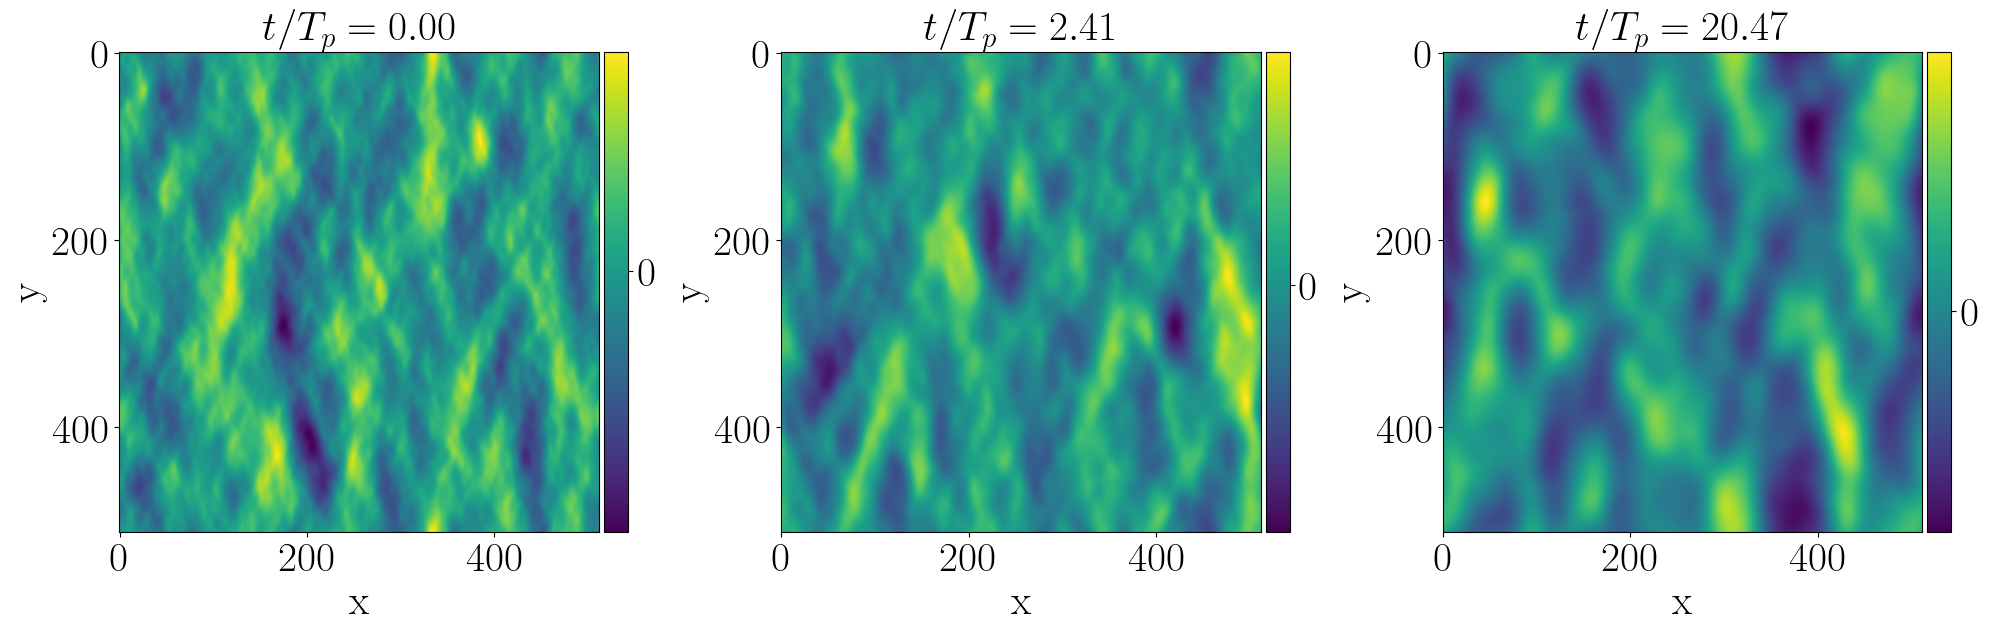

In [11]:
ind_time = [0,154,-1] #index of the times we are interested in (depends on length of time) 
num_rows = 1
num_cols = 3

kp = 4; omegap = (1*kp)**0.5

tstart=time[0]


fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 13))
j = 0

for i in ind_time:
    eta = eta_series[i]
    
    #vmin = 0
    #vmax = 5
    #levels = np.linspace(vmin, vmax, 1000)
    
    ax = axes[j % num_cols]
    im = ax.imshow(eta)  
    
    ax.set_aspect('equal')
    ax.set_title(label=r'$ t/T_{p}=%.2f$'%((time[i]-tstart)* omegap / (2 * np.pi)))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax, orientation='vertical', extendrect = 'False')

    
    #cbar = fig.colorbar(im, ax=axs, pad=0.04, orientation='vertical',  extendrect = 'False', shrink= 0.6)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x)}$'))
    cbar.ax.yaxis.set_major_locator(plt.FixedLocator([-20, -15, -10, -5, 0]))
    #ax.figure.savefig(graph_path + f'/eta_{(omegap*(time[i]-tstart))}.png')
    
    j += 1

plt.savefig(graph_path + f'/eta.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## PDF of $\eta(x,y)$

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3663230/3066885450.py:20: SyntaxWarning: invalid escape sequence '\e'
  plt.title('PDF of surface elevation $\eta(x,y)$ initial time')


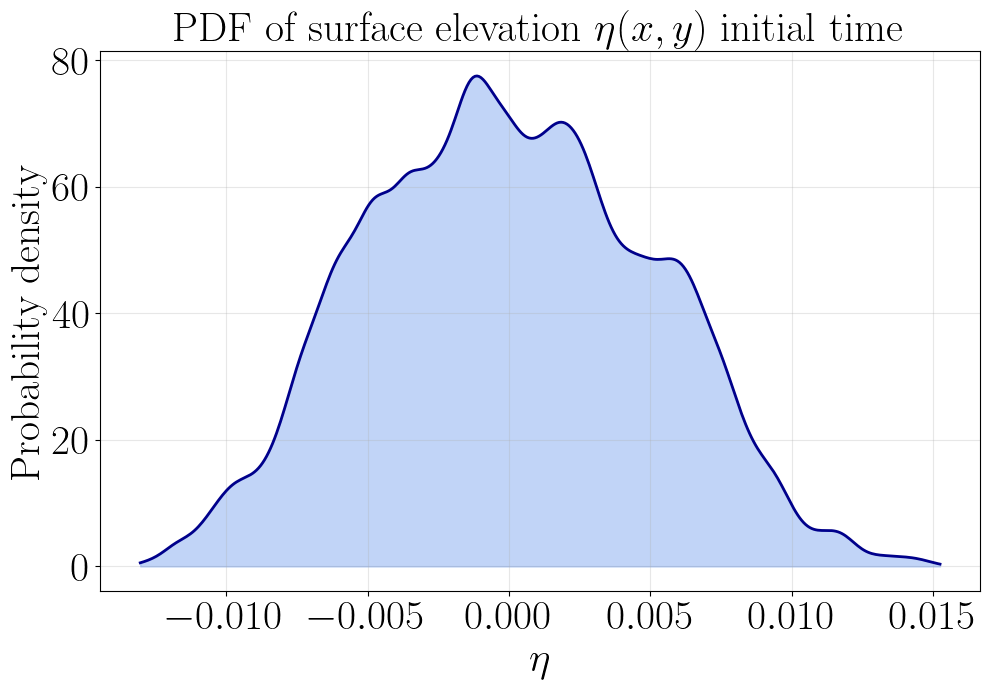

In [12]:
from scipy.stats import gaussian_kde

# --- selecciona el campo 2D ---
eta = np.asarray(eta_series[i])   # shape: (Nx, Ny)

# --- vectoriza y limpia NaNs ---
vals = eta[np.isfinite(eta)].ravel()

# --- cálculo de PDF (kernel density estimate) ---
kde = gaussian_kde(vals)
x_vals = np.linspace(vals.min(), vals.max(), 400)
pdf_vals = kde(x_vals)

# --- gráfica ---
plt.figure(figsize=(10,7))
plt.plot(x_vals, pdf_vals, color='darkblue', lw=2)
plt.fill_between(x_vals, pdf_vals, color='cornflowerblue', alpha=0.4)
plt.xlabel(r'$\eta$')
plt.ylabel('Probability density')
plt.title('PDF of surface elevation $\eta(x,y)$ initial time')
ax.figure.savefig(graph_path + f'/eta_PDF.png')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Potential energy 

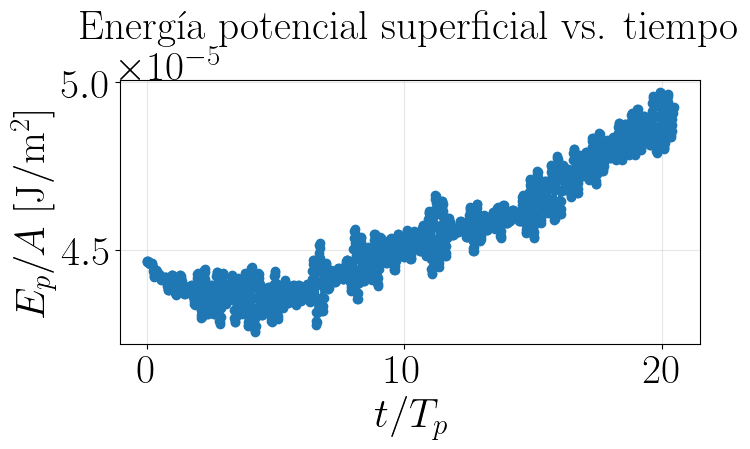

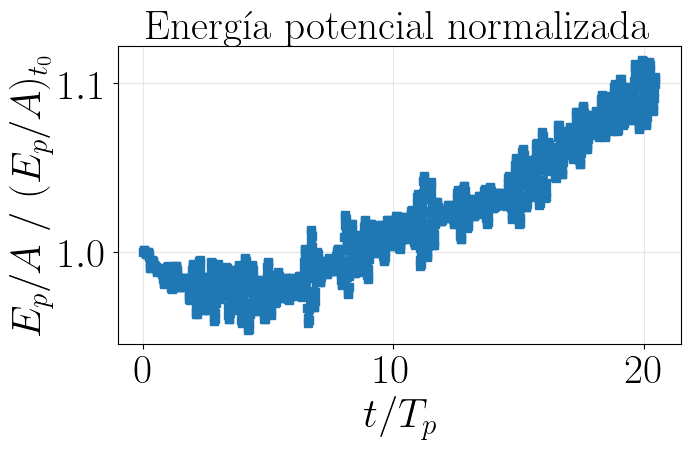

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- parámetros físicos (ajusta si procede) ---
rho = rho1

# --- tiempos no dimensionales: t/Tp ---
t_over_Tp = (time - tstart) * omegap / (2*np.pi)

# si quieres limitar a ciertos índices (p.ej. ind_time), usa esa lista; si no, usa todo
#idx_list = ind_time if 'ind_time' in globals() else range(len(eta_series))

Ep_per_area = []  # J/m^2
t_plot      = []

for i in range(len(eta_series)):
    eta = np.array(eta_series[i])              # η(x,y) en ese instante
    m2  = np.mean((eta-np.mean(eta))**2)                     # <η^2> (ignora NaNs si los hubiera)
    EpA = 0.5 * rho * g * m2                     # energía potencial por unidad de área
    Ep_per_area.append(EpA)
    t_plot.append(t_over_Tp[i])

Ep_per_area = np.asarray(Ep_per_area)
t_plot      = np.asarray(t_plot)

# --- gráfica simple ---
plt.figure(figsize=(7.2, 4.6))
plt.plot(t_plot, Ep_per_area, marker='o', lw=2)
plt.xlabel(r'$t/T_p$')
plt.ylabel(r'$E_p/A\ \mathrm{[J/m^2]}$')
plt.title('Energía potencial superficial vs. tiempo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- (opcional) normalizado por el valor del primer punto que plotes ---
if len(Ep_per_area) > 0 and Ep_per_area[0] != 0:
    plt.figure(figsize=(7.2, 4.6))
    plt.plot(t_plot, Ep_per_area / Ep_per_area[0], marker='s', lw=2)
    plt.xlabel(r'$t/T_p$')
    plt.ylabel(r'$E_p/A\ /\ (E_p/A)_{t_0}$')
    plt.title('Energía potencial normalizada')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


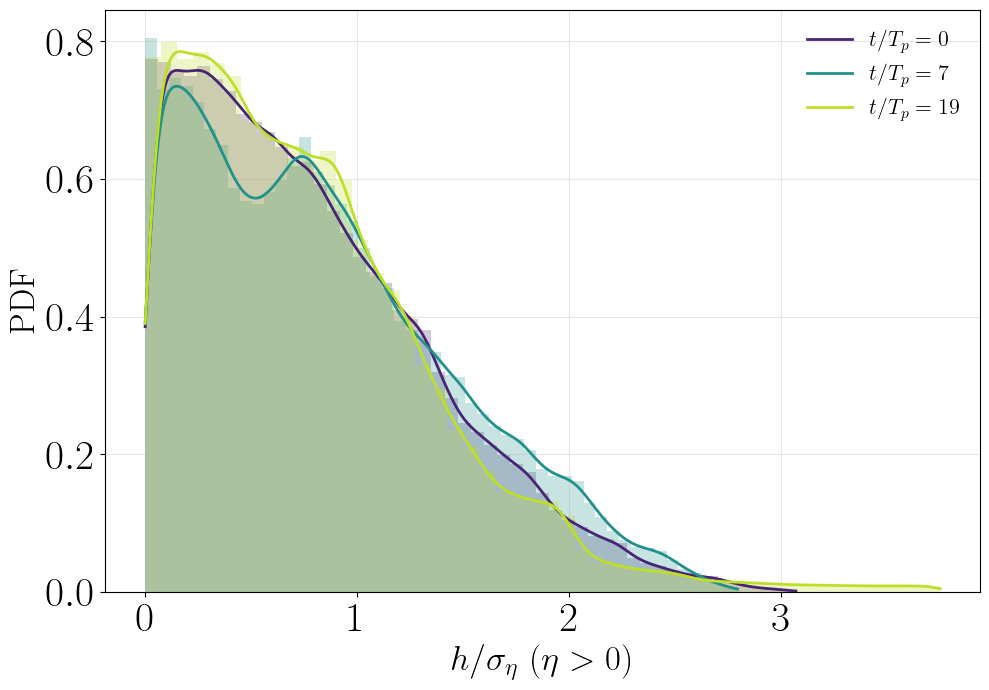

In [14]:
plt.figure(figsize=(10,7))
# índices que marcan INICIO de cada ventana
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)
for i, c in zip(indices, colors):
    eta_i = np.asarray(eta_series[i])
    eta   = eta_i - np.mean(eta_i)

    vals = eta.ravel()
    vals = vals[np.isfinite(vals)]

    # sigma_eta del campo completo (no solo de la parte positiva)
    sigma_eta = np.std(vals)

    # nos quedamos solo con alturas positivas (crestas)
    vals_pos = vals[vals > 0]

    # normalizamos por sigma_eta
    vals_pos_norm = vals_pos / sigma_eta

    kde = gaussian_kde(vals_pos_norm)
    x_vals = np.linspace(vals_pos_norm.min(), vals_pos_norm.max(), 400)
    pdf_vals = kde(x_vals)

    tTp = (time[i] - tstart) * omegap / (2 * np.pi)

    plt.hist(vals_pos_norm,
             bins=50,
             density=True,
             color=c,
             alpha=0.25)

    plt.plot(x_vals, pdf_vals, lw=2, color=c,
             label=rf'$t/T_p = {tTp:.0f}$')

plt.xlabel(r'$h / \sigma_{\eta}$  ($\eta>0$)', fontsize=25)
plt.ylabel('PDF', fontsize=25)
plt.legend(fontsize=16, frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/eta_positive_PDF_sigma_eta_time.pdf',
            dpi=300, bbox_inches='tight')
plt.show()



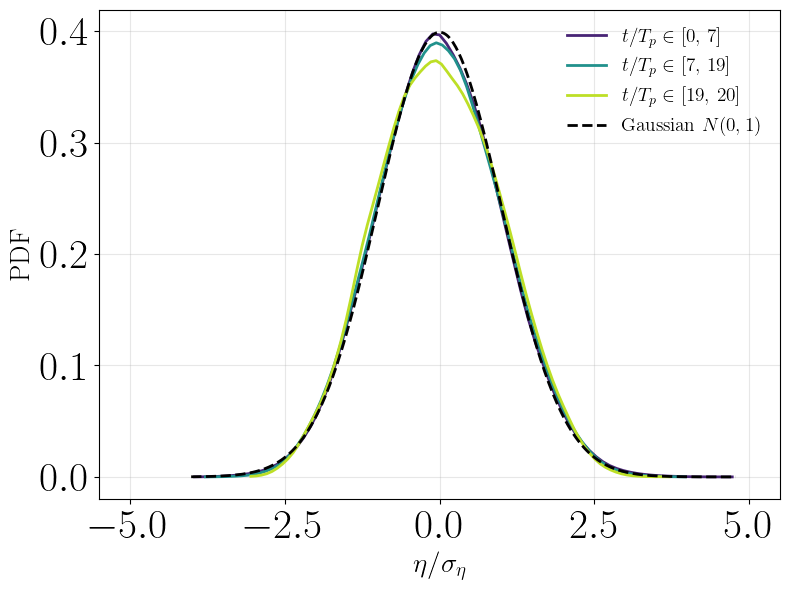

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# índices que marcan INICIO de cada ventana
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --- convertir índices (soportando negativos tipo -120) a absolutos y ordenarlos ---
bounds = []
for idx in indices:
    if idx < 0:
        bounds.append(Nt + idx)
    else:
        bounds.append(idx)

bounds = sorted(bounds)
bounds.append(Nt)   # último límite = final de la serie

plt.figure(figsize=(8, 6))

all_vals_norm = []

for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):
    # acumulamos todos los snapshots en esta ventana de tiempo
    window_vals = []

    for j in range(start, end):
        eta_j = np.asarray(eta_series[j])
        eta_j = eta_j - np.mean(eta_j)       # quitar media del snapshot

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    # sigma_eta de TODA la ventana
    sigma_eta = np.std(window_vals)
    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma -> suavizado gaussiano
    counts, bins = np.histogram(vals_norm, bins=80, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=1.2)

    # tiempo representativo de la ventana (p.ej. el snapshot central)
    mid = (start + end - 1) // 2
    #t    # --- RANGO EN t/Tp PARA LA LEYENDA (como en tu figura) ---
    tTp_start = (time[start]   - tstart) * omegap / (2*np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2*np.pi)


    plt.plot(bin_centers, pdf_smooth, lw=2, color=c,
             label = rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$')

# rango común y gaussiana N(0,1)
x_all = np.concatenate(all_vals_norm)
x_ref = np.linspace(x_all.min(), x_all.max(), 400)
pdf_gauss = norm.pdf(x_ref, loc=0.0, scale=1.0)
plt.plot(x_ref, pdf_gauss, 'k--', lw=2, label=r'Gaussian $N(0,1)$')

plt.xlim([-5.5,5.5])
plt.xlabel(r'$\eta / \sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=False, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist.pdf',
            dpi=300, bbox_inches='tight')
plt.show()


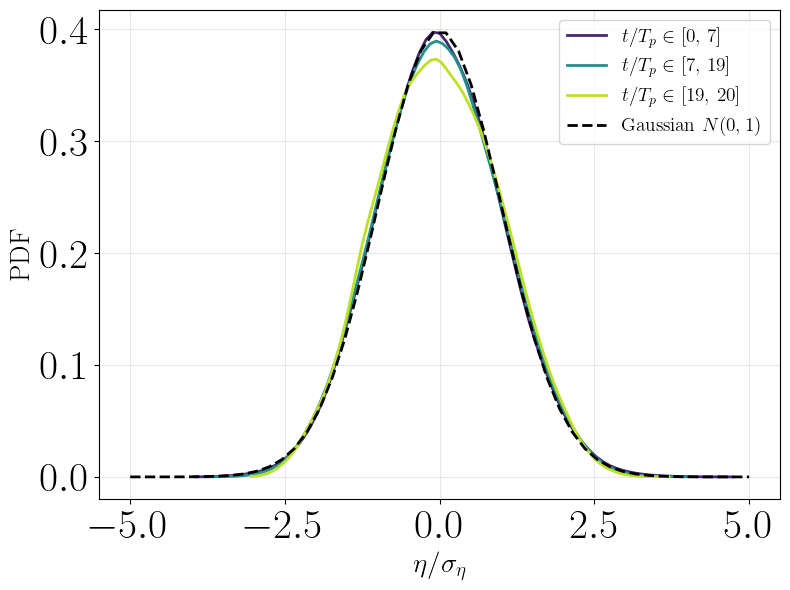

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# --------------------------------------------------
# Índices que marcan el INICIO de cada ventana
# --------------------------------------------------
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --------------------------------------------------
# Convertir índices (soportando negativos) y crear ventanas
# --------------------------------------------------
bounds = []
for idx in indices:
    bounds.append(Nt + idx if idx < 0 else idx)

bounds = sorted(bounds)
bounds.append(Nt)

plt.figure(figsize=(8, 6))
all_vals_norm = []

# --------------------------------------------------
# Loop sobre ventanas
# --------------------------------------------------
for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):

    if end <= start:
        continue

    window_vals = []

    # acumular todos los snapshots de la ventana
    for j in range(start, end):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.mean(eta_j)

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    sigma_eta = np.std(window_vals)
    if sigma_eta <= 0:
        continue

    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma + suavizado
    counts, bins = np.histogram(vals_norm, bins=80, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=1.2)

    # --- RANGO EN t/Tp PARA LA LEYENDA (como en tu figura) ---
    tTp_start = (time[start]   - tstart) * omegap / (2*np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2*np.pi)

    plt.plot(
        bin_centers, pdf_smooth, lw=2, color=c,
        label=rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$'
    )

# --------------------------------------------------
# Gaussiana N(0,1)
# --------------------------------------------------
x_ref = np.linspace(-5, 5)
plt.plot(x_ref, norm.pdf(x_ref, 0.0, 1.0), 'k--', lw=2, label=r'Gaussian $N(0,1)$')

#plt.xlim([-6, 9])  # si quieres exactamente el rango que se ve en tu captura
plt.xlabel(r'$\eta/\sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist.pdf',dpi=300, bbox_inches='tight')
plt.show()

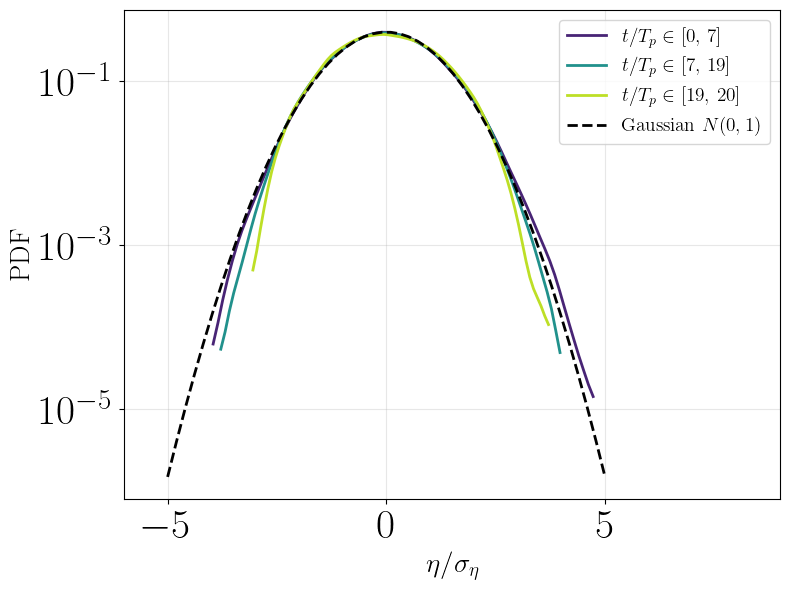

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# --------------------------------------------------
# Índices que marcan el INICIO de cada ventana
# --------------------------------------------------
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --------------------------------------------------
# Convertir índices (soportando negativos) y crear ventanas
# --------------------------------------------------
bounds = []
for idx in indices:
    bounds.append(Nt + idx if idx < 0 else idx)

bounds = sorted(bounds)
bounds.append(Nt)

plt.figure(figsize=(8, 6))
all_vals_norm = []

# --------------------------------------------------
# Loop sobre ventanas
# --------------------------------------------------
for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):

    if end <= start:
        continue

    window_vals = []

    # acumular todos los snapshots de la ventana
    for j in range(start, end):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.mean(eta_j)

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    sigma_eta = np.std(window_vals)
    if sigma_eta <= 0:
        continue

    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma + suavizado
    counts, bins = np.histogram(vals_norm, bins=80, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=1.2)

    # --- RANGO EN t/Tp PARA LA LEYENDA (como en tu figura) ---
    tTp_start = (time[start]   - tstart) * omegap / (2*np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2*np.pi)

    plt.plot(
        bin_centers, pdf_smooth, lw=2, color=c,
        label=rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$'
    )

# --------------------------------------------------
# Gaussiana N(0,1)
# --------------------------------------------------
x_ref = np.linspace(-5, 5)
plt.plot(x_ref, norm.pdf(x_ref, 0.0, 1.0), 'k--', lw=2, label=r'Gaussian $N(0,1)$')
plt.yscale('log')
plt.xlim([-6, 9])  # si quieres exactamente el rango que se ve en tu captura
plt.xlabel(r'$\eta/\sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist.pdf',dpi=300, bbox_inches='tight')
plt.show()

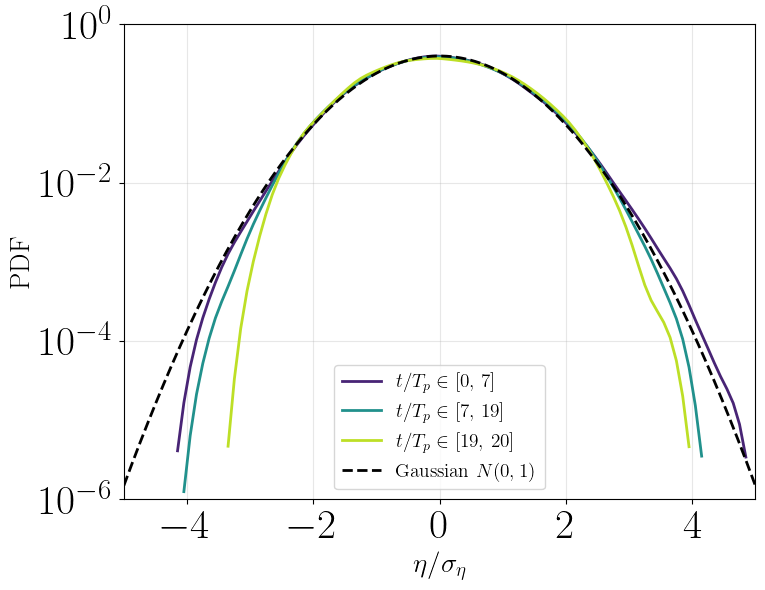

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# --------------------------------------------------
# Índices que marcan el INICIO de cada ventana
# --------------------------------------------------
#indices = [0, 450, -120]
indices = [0, 450, -120]
#indices = [0, -100]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --------------------------------------------------
# Convertir índices (soportando negativos) y crear ventanas
# --------------------------------------------------
bounds = []
for idx in indices:
    bounds.append(Nt + idx if idx < 0 else idx)

bounds = sorted(bounds)
bounds.append(Nt)

plt.figure(figsize=(8, 6))
all_vals_norm = []

# --------------------------------------------------
# Parámetros para el PDF
# --------------------------------------------------
xlim = (-5, 5)
nbins = 100
smooth_sigma = 1.2

# corte de cola (para evitar ruido en log-y)
pdf_floor_plot = 1e-6   # no plotees por debajo de esto
pdf_floor_num  = 1e-12  # evita ceros para log

# --------------------------------------------------
# Loop sobre ventanas
# --------------------------------------------------
for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):

    if end <= start:
        continue

    window_vals = []

    # acumular todos los snapshots de la ventana
    for j in range(start, end):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.nanmean(eta_j)  # robusto a NaNs

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    sigma_eta = np.std(window_vals)
    if sigma_eta <= 0:
        continue

    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma en rango fijo [-5,5] (IMPORTANTE para comparar en colas)
    counts, bins = np.histogram(vals_norm, bins=nbins, range=xlim, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=smooth_sigma)

    # evita ceros para log
    pdf_smooth = np.maximum(pdf_smooth, pdf_floor_num)

    # máscara para no mostrar basura en colas
    mask = pdf_smooth >= pdf_floor_plot

    # rango en t/Tp para la leyenda
    tTp_start = (time[start]   - tstart) * omegap / (2*np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2*np.pi)

    plt.semilogy(
        bin_centers[mask], pdf_smooth[mask],
        lw=2, color=c,
        label=rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$'
    )

# --------------------------------------------------
# Gaussiana N(0,1)
# --------------------------------------------------
x_ref = np.linspace(xlim[0], xlim[1], 400)
pdf_g = norm.pdf(x_ref, 0.0, 1.0)
pdf_g = np.maximum(pdf_g, pdf_floor_num)

plt.semilogy(x_ref, pdf_g, 'k--', lw=2, label=r'Gaussian $N(0,1)$')

# --------------------------------------------------
# Estética
# --------------------------------------------------
plt.xlim(xlim)
plt.ylim(1e-6, 1)  # ajusta si quieres ver más/menos cola
plt.xlabel(r'$\eta/\sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist_logy.pdf',
            dpi=300, bbox_inches='tight')
plt.show()


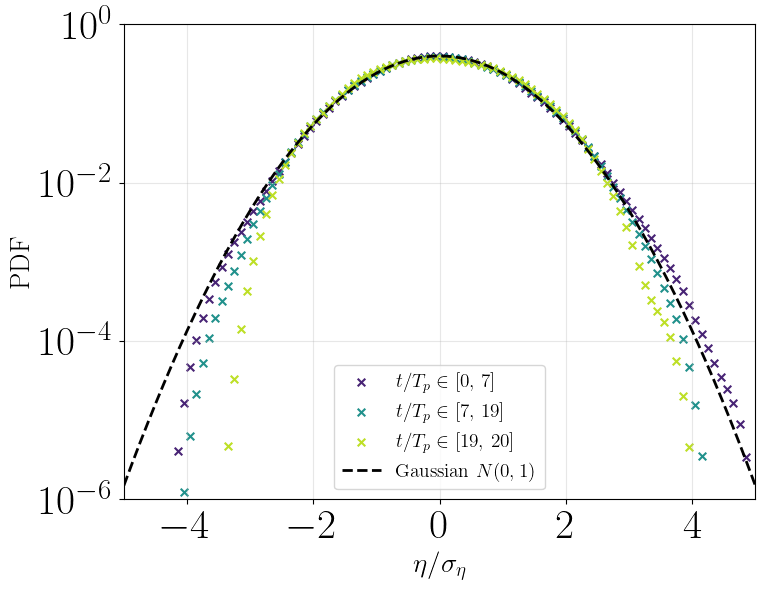

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# --------------------------------------------------
# Índices que marcan el INICIO de cada ventana
# --------------------------------------------------
#indices = [0, 450, -120]
indices = [0, 450, -120]
#indices = [0, -100]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --------------------------------------------------
# Convertir índices (soportando negativos) y crear ventanas
# --------------------------------------------------
bounds = []
for idx in indices:
    bounds.append(Nt + idx if idx < 0 else idx)

bounds = sorted(bounds)
bounds.append(Nt)

plt.figure(figsize=(8, 6))
all_vals_norm = []

# --------------------------------------------------
# Parámetros para el PDF
# --------------------------------------------------
xlim = (-5, 5)
nbins = 100
smooth_sigma = 1.2

# corte de cola (para evitar ruido en log-y)
pdf_floor_plot = 1e-6   # no plotees por debajo de esto
pdf_floor_num  = 1e-12  # evita ceros para log

# --------------------------------------------------
# Loop sobre ventanas
# --------------------------------------------------
for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):

    if end <= start:
        continue

    window_vals = []

    # acumular todos los snapshots de la ventana
    for j in range(start, end):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.nanmean(eta_j)  # robusto a NaNs

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    sigma_eta = np.std(window_vals)
    if sigma_eta <= 0:
        continue

    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma en rango fijo [-5,5] (IMPORTANTE para comparar en colas)
    counts, bins = np.histogram(vals_norm, bins=nbins, range=xlim, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=smooth_sigma)

    # evita ceros para log
    pdf_smooth = np.maximum(pdf_smooth, pdf_floor_num)

    # máscara para no mostrar basura en colas
    mask = pdf_smooth >= pdf_floor_plot

    # rango en t/Tp para la leyenda
    tTp_start = (time[start]   - tstart) * omegap / (2*np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2*np.pi)

    plt.scatter(
        bin_centers[mask], pdf_smooth[mask], color=c, marker ='x', s=30, 
        label=rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$'
    )

# --------------------------------------------------
# Gaussiana N(0,1)
# --------------------------------------------------
x_ref = np.linspace(xlim[0], xlim[1], 400)
pdf_g = norm.pdf(x_ref, 0.0, 1.0)
pdf_g = np.maximum(pdf_g, pdf_floor_num)

plt.plot(x_ref, pdf_g, 'k--', lw=2, label=r'Gaussian $N(0,1)$')
plt.yscale('log')
# --------------------------------------------------
# Estética
# --------------------------------------------------
plt.xlim(xlim)
plt.ylim(1e-6, 1)  # ajusta si quieres ver más/menos cola
plt.xlabel(r'$\eta/\sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist_logy.pdf',
            dpi=300, bbox_inches='tight')
plt.show()


a=2:  P(X<-a)=2.017e-02   P(X>a)=2.355e-02   ratio L/R=0.856
a=3:  P(X<-a)=5.755e-04   P(X>a)=1.115e-03   ratio L/R=0.516
a=4:  P(X<-a)=1.077e-07   P(X>a)=1.593e-05   ratio L/R=0.007
a=5:  P(X<-a)=0.000e+00   P(X>a)=0.000e+00   ratio L/R=0.000


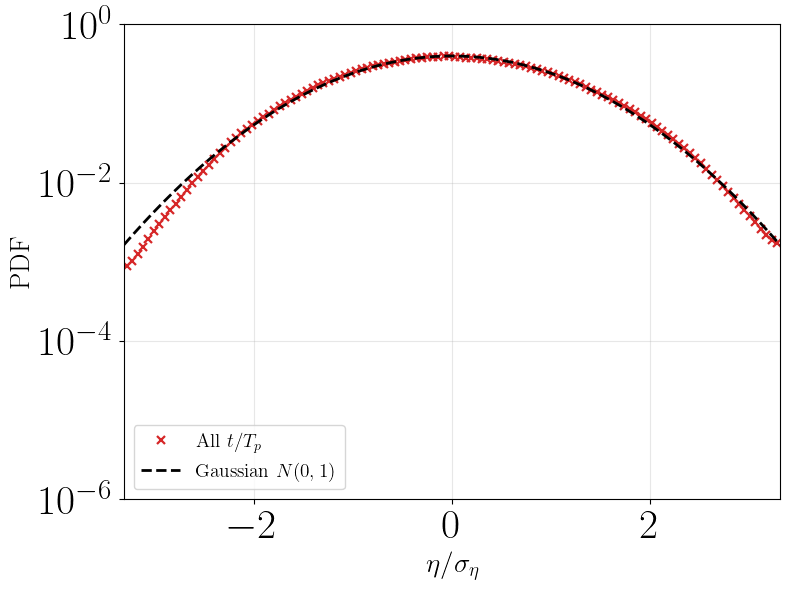

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# ============================================================
# PDF de eta/sigma_eta (ALL times) SIN recortar en x
# - pooling de todos los tiempos (con subsampling opcional)
# - bins SIMÉTRICOS para no sesgar colas
# - opción de normalizar snapshot-a-snapshot (recomendado)
# - opción de smoothing (puedes apagarlo para diagnóstico)
# ============================================================

# -----------------------------
# Parámetros
# -----------------------------
nbins = 120
step_snap = 1

# Plot
ylim = (1e-6, 1)
pdf_floor_plot = 1e-6   # no dibujar por debajo
pdf_floor_num  = 1e-12  # evitar ceros en log

# Estimación de PDF
use_snapshot_normalization = True   # <-- recomendado para "All times"
use_smoothing = True                # <-- pon False para diagnóstico
smooth_sigma = 1.2

# Para definir el rango de bins de forma robusta (evita que 1 outlier dicte todo)
abs_quantile_for_bins = 0.9995  # 0.999 a 0.9999 suele ir bien

# Solo visual (NO afecta al histograma)
xlim_plot = None  # e.g. (-8, 8) o deja None para auto

# -----------------------------
# Construir vals_norm (ALL times)
# -----------------------------
Nt = len(eta_series)
vals_list = []

for j in range(0, Nt, step_snap):
    eta_j = np.asarray(eta_series[j], float)
    eta_j -= np.nanmean(eta_j)

    v = eta_j.ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        continue

    if use_snapshot_normalization:
        s = np.std(v)
        if s > 0:
            vals_list.append(v / s)
    else:
        vals_list.append(v)

if len(vals_list) == 0:
    raise ValueError("No hay datos finitos en eta_series (vals_list está vacío).")

vals_norm = np.concatenate(vals_list)

# Si NO normalizas snapshot-a-snapshot, normaliza globalmente aquí
if not use_snapshot_normalization:
    sigma_eta = np.std(vals_norm)
    if sigma_eta <= 0:
        raise ValueError("sigma_eta <= 0: revisa eta_series (constante o vacío).")
    vals_norm = vals_norm / sigma_eta

# -----------------------------
# Checks rápidos (colas izquierda/derecha)
# -----------------------------
for a in [2, 3, 4, 5]:
    pL = np.mean(vals_norm < -a)
    pR = np.mean(vals_norm >  a)
    print(f"a={a}:  P(X<-a)={pL:.3e}   P(X>a)={pR:.3e}   ratio L/R={pL/(pR+1e-300):.3f}")

# -----------------------------
# Histograma con bins simétricos
# -----------------------------
xmax = np.quantile(np.abs(vals_norm), abs_quantile_for_bins)
if not np.isfinite(xmax) or xmax <= 0:
    xmax = np.max(np.abs(vals_norm))

bins = np.linspace(-xmax, xmax, nbins + 1)
counts, bins = np.histogram(vals_norm, bins=bins, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

pdf = np.maximum(counts, pdf_floor_num)

# Smoothing opcional (solo para “look”, no para diagnóstico)
if use_smoothing:
    pdf = gaussian_filter1d(pdf, sigma=smooth_sigma)
    pdf = np.maximum(pdf, pdf_floor_num)

mask = pdf >= pdf_floor_plot

# -----------------------------
# Figura
# -----------------------------
plt.figure(figsize=(8, 6))

plt.semilogy(
    bin_centers[mask], pdf[mask],
    linestyle="None",
    marker="x",
    markersize=6,
    markeredgewidth=1.6,
    color="tab:red",
    label=r"All $t/T_p$",
)

# Gaussiana N(0,1) en el mismo rango de bins (para comparar colas correctamente)
x_ref = np.linspace(-xmax, xmax, 600)
pdf_g = norm.pdf(x_ref, 0.0, 1.0)
pdf_g = np.maximum(pdf_g, pdf_floor_num)

plt.semilogy(
    x_ref, pdf_g,
    "k--", lw=2,
    label=r"Gaussian $N(0,1)$"
)

# Estética
if xlim_plot is not None:
    plt.xlim(xlim_plot)
else:
    plt.xlim(-xmax, xmax)

plt.ylim(*ylim)
plt.xlabel(r"$\eta/\sigma_{\eta}$", fontsize=20)
plt.ylabel("PDF", fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.savefig(
    graph_path + "/PDF_eta_over_sigma_alltimes_logy_scatter.pdf",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [21]:
from scipy.stats import skew

m_t = []
s_t = []
sk_t = []

for j in range(Nt):
    v = np.asarray(eta_series[j], float).ravel()
    v = v[np.isfinite(v)]
    m_t.append(np.mean(v))
    s_t.append(np.std(v))
    sk_t.append(skew((v - np.mean(v))/np.std(v)))

print("mean range:", np.min(m_t), np.max(m_t))
print("std range :", np.min(s_t), np.max(s_t))
print("skew median:", np.median(sk_t), "min/max:", np.min(sk_t), np.max(sk_t))


mean range: -6.386746235875762e-06 1.6072203834482934e-07
std range : 0.004623433652087815 0.004998567745096562
skew median: 0.05645498314719419 min/max: -0.21469625784349128 0.3458582954296051


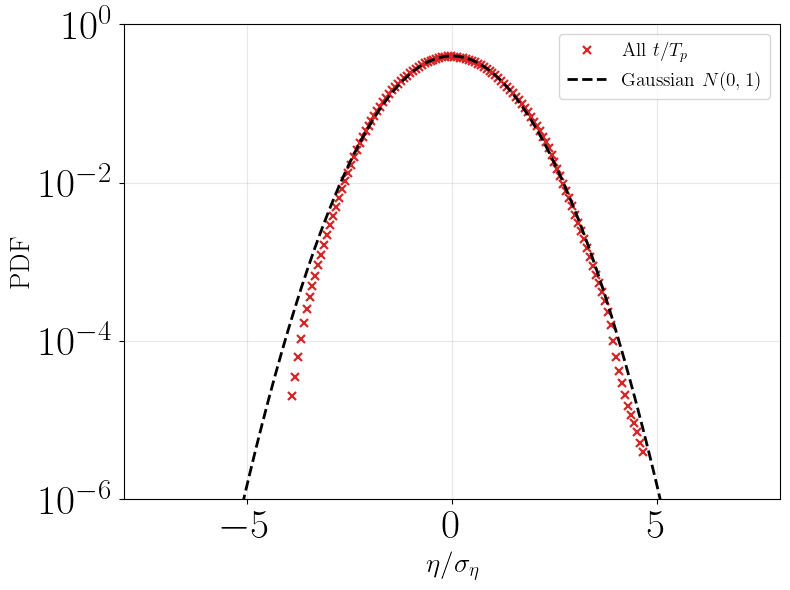

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# ==================================================
# PDF de eta/sigma_eta (ALL times) sin recortar en x
# ==================================================

# -----------------------------
# Parámetros
# -----------------------------
nbins        = 120
smooth_sigma = 1.2

pdf_floor_plot = 1e-6   # solo para NO dibujar ruido en colas
pdf_floor_num  = 1e-12  # evita ceros (log)

step_snap = 1           # >1 si quieres acelerar (p.ej. 5)

# (solo visual: NO afecta al histograma)
xlim_plot = (-8, 8)

# -----------------------------
# Pool de TODOS los tiempos
# -----------------------------
Nt = len(eta_series)
all_vals = []

for j in range(0, Nt, step_snap):
    eta_j = np.asarray(eta_series[j], float)
    eta_j -= np.nanmean(eta_j)

    v = eta_j.ravel()
    v = v[np.isfinite(v)]
    if v.size:
        all_vals.append(v)

all_vals = np.concatenate(all_vals)

# Normalización global (si prefieres snapshot-a-snapshot, dímelo y te lo cambio)
sigma_eta = np.std(all_vals)
if sigma_eta <= 0:
    raise ValueError("sigma_eta <= 0: revisa eta_series (constante o vacío).")

vals_norm = all_vals / sigma_eta

# -----------------------------
# Histograma (SIN range) + suavizado
# -----------------------------
counts, bins = np.histogram(vals_norm, bins=nbins, density=True)
bin_centers  = 0.5 * (bins[:-1] + bins[1:])

pdf_smooth = gaussian_filter1d(counts, sigma=smooth_sigma)
pdf_smooth = np.maximum(pdf_smooth, pdf_floor_num)

# Máscara SOLO para plot
mask = pdf_smooth >= pdf_floor_plot

# -----------------------------
# Figura
# -----------------------------
plt.figure(figsize=(8, 6))

plt.semilogy(
    bin_centers[mask], pdf_smooth[mask],
    linestyle="None",
    marker="x",
    markersize=6,
    markeredgewidth=1.6,
    color="tab:red",
    label=r"All $t/T_p$",
)

# Gaussiana de referencia (en el rango mostrado)
x_ref = np.linspace(xlim_plot[0], xlim_plot[1], 400)
pdf_g = norm.pdf(x_ref, 0.0, 1.0)
pdf_g = np.maximum(pdf_g, pdf_floor_num)

plt.semilogy(
    x_ref, pdf_g,
    "k--", lw=2,
    label=r"Gaussian $N(0,1)$"
)

# Estética
plt.xlim(xlim_plot)         # solo visual
plt.ylim(1e-6, 1)
plt.xlabel(r"$\eta/\sigma_{\eta}$", fontsize=20)
plt.ylabel("PDF", fontsize=20)
plt.legend(frameon=True, fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.savefig(
    graph_path + "/PDF_eta_over_sigma_alltimes_logy_scatter.pdf",
    dpi=300, bbox_inches="tight"
)
plt.show()


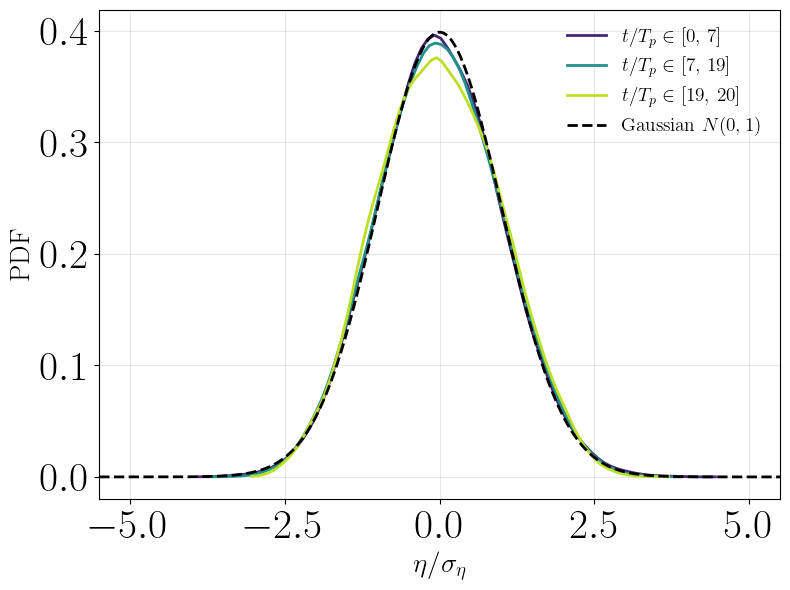

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# --- índices que marcan INICIO de cada ventana ---
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

Nt = len(eta_series)

# --- convertir índices (soportando negativos) y construir límites de ventanas ---
bounds = []
for idx in indices:
    if idx < 0:
        bounds.append(Nt + idx)
    else:
        bounds.append(idx)

bounds = sorted(bounds)
bounds.append(Nt)   # último límite = final

plt.figure(figsize=(8, 6))

# --- parámetros para acelerar ---
step_snap = 5                  # usar 1 de cada 5 snapshots dentro de cada ventana
max_points_per_window = 300_000 # máximo de puntos por ventana para el histograma
rng = np.random.default_rng(0)  # reproducible

all_vals_norm = []

for (start, end), c in zip(zip(bounds[:-1], bounds[1:]), colors):
    window_vals = []

    # acumulamos snapshots submuestreados en tiempo
    for j in range(start, end, step_snap):
        eta_j = np.asarray(eta_series[j], float)

        # quitar media del snapshot (importante)
        eta_j = eta_j - np.nanmean(eta_j)

        vals_j = eta_j.ravel()
        vals_j = vals_j[np.isfinite(vals_j)]
        window_vals.append(vals_j)

    window_vals = np.concatenate(window_vals)

    # submuestrear puntos si hay demasiados (para acelerar)
    if window_vals.size > max_points_per_window:
        idxs = rng.choice(window_vals.size, size=max_points_per_window, replace=False)
        window_vals = window_vals[idxs]

    # sigma_eta de TODA la ventana (con los puntos seleccionados)
    sigma_eta = np.std(window_vals)
    if sigma_eta <= 0:
        continue

    vals_norm = window_vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma -> suavizado gaussiano
    counts, bins = np.histogram(vals_norm, bins=80, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=1.2)

    # rango de tiempos de la ventana en unidades de T_p
    tTp_start = (time[start]   - tstart) * omegap / (2 * np.pi)
    tTp_end   = (time[end - 1] - tstart) * omegap / (2 * np.pi)

    plt.plot(
        bin_centers, pdf_smooth, lw=2, color=c,
        label=rf'$t/T_p \in [{tTp_start:.0f},\,{tTp_end:.0f}]$'
    )

# --- gaussiana N(0,1) de referencia en rango común ---
x_all = np.concatenate(all_vals_norm)
x_ref = np.linspace(-5.5, 5.5, 400)
pdf_gauss = norm.pdf(x_ref, loc=0.0, scale=1.0)
plt.plot(x_ref, pdf_gauss, 'k--', lw=2, label=r'Gaussian $N(0,1)$')

plt.xlim([-5.5, 5.5])
plt.xlabel(r'$\eta / \sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=False, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_timewindows_smoothHist_fast.pdf',
            dpi=300, bbox_inches='tight')
plt.show()


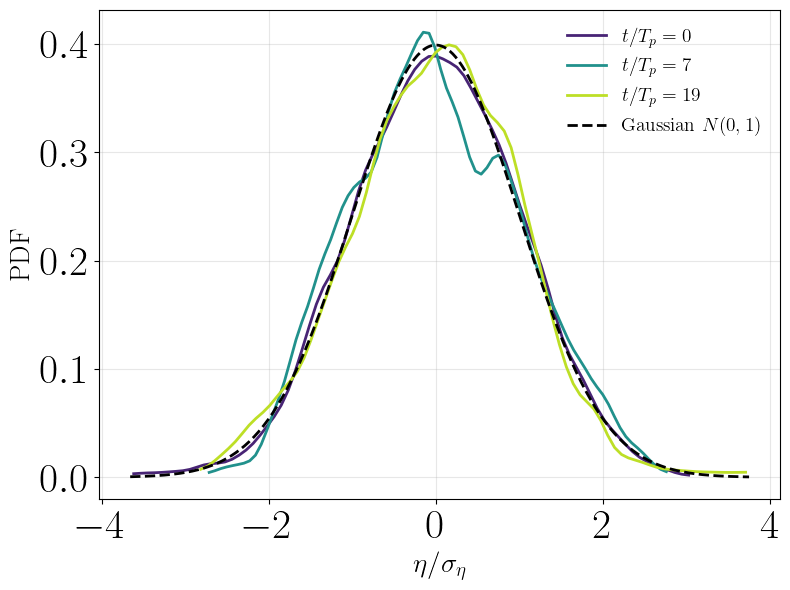

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# snapshots que quieres mostrar
indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

plt.figure(figsize=(8, 6))

all_vals_norm = []

for i, c in zip(indices, colors):
    # campo en ese instante y eliminación de la media del snapshot
    eta_i = np.asarray(eta_series[i])
    eta_i = eta_i - np.mean(eta_i)

    vals = eta_i.ravel()
    vals = vals[np.isfinite(vals)]

    # sigma_eta en ese instante
    sigma_eta = np.std(vals)
    vals_norm = vals / sigma_eta
    all_vals_norm.append(vals_norm)

    # histograma -> suavizado gaussiano (sin pintar las barras)
    counts, bins = np.histogram(vals_norm, bins=80, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pdf_smooth  = gaussian_filter1d(counts, sigma=1.2)

    tTp = (time[i] - tstart) * omegap / (2 * np.pi)

    plt.plot(bin_centers, pdf_smooth, lw=2, color=c,
             label=rf'$t/T_p = {tTp:.0f}$')

# rango común y gaussiana N(0,1)
x_all = np.concatenate(all_vals_norm)
x_ref = np.linspace(x_all.min(), x_all.max(), 400)
pdf_gauss = norm.pdf(x_ref, loc=0.0, scale=1.0)
plt.plot(x_ref, pdf_gauss, 'k--', lw=2, label=r'Gaussian $N(0,1)$')

plt.xlabel(r'$\eta / \sigma_{\eta}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=False, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_eta_over_sigma_alltimes_smoothHist.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

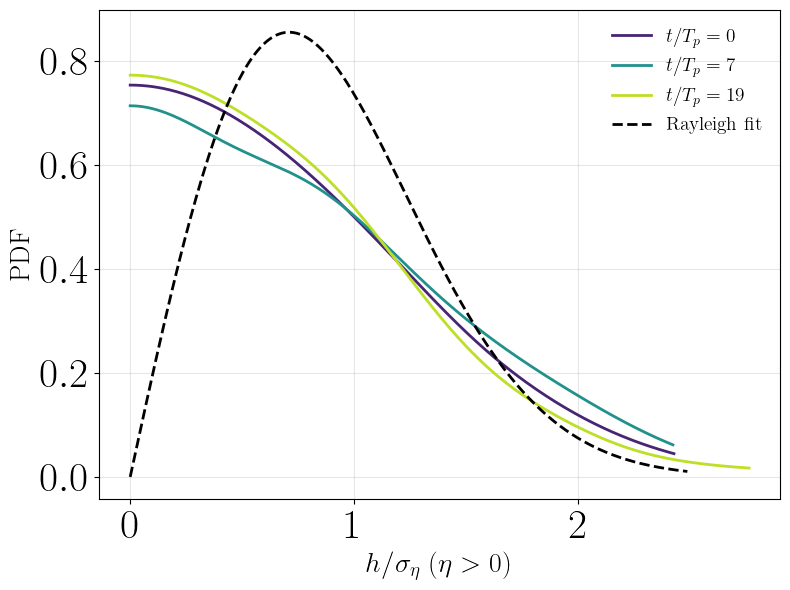

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, rayleigh

indices = [0, 450, -120]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(indices)))

plt.figure(figsize=(8, 6))

all_pos_norm = []

for i, c in zip(indices, colors):
    eta_i = np.asarray(eta_series[i])
    eta_i = eta_i - np.mean(eta_i)

    vals = eta_i.ravel()
    vals = vals[np.isfinite(vals)]

    sigma_eta = np.std(vals)

    # crestas únicamente
    vals_pos = vals[vals > 0]
    vals_pos_norm = vals_pos / sigma_eta
    all_pos_norm.append(vals_pos_norm)

    # KDE con reflexión en 0 (boundary correction)
    vals_reflect = np.concatenate([vals_pos_norm, -vals_pos_norm])
    kde = gaussian_kde(vals_reflect, bw_method=0.25)

    x_max  = np.percentile(vals_pos_norm, 99)
    x_vals = np.linspace(0, x_max, 400)
    pdf_vals = 2.0 * kde(x_vals)   # factor 2 por la reflexión

    tTp = (time[i] - tstart) * omegap / (2 * np.pi)

    plt.plot(x_vals, pdf_vals, lw=2, color=c,
             label=rf'$t/T_p = {tTp:.0f}$')

# Rayleigh ajustada por MLE sobre todos los tiempos
all_pos_norm = np.concatenate(all_pos_norm)
sigma_R = rayleigh.fit(all_pos_norm, floc=0.0)[1]

x_ref = np.linspace(0, np.percentile(all_pos_norm, 99), 400)
pdf_R = rayleigh.pdf(x_ref, loc=0.0, scale=sigma_R)
plt.plot(x_ref, pdf_R, 'k--', lw=2, label='Rayleigh fit')

plt.xlabel(r'$h / \sigma_{\eta}$ ($\eta>0$)', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.legend(frameon=False, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_path + '/PDF_crests_over_sigma_Rayleigh_KDEreflect.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

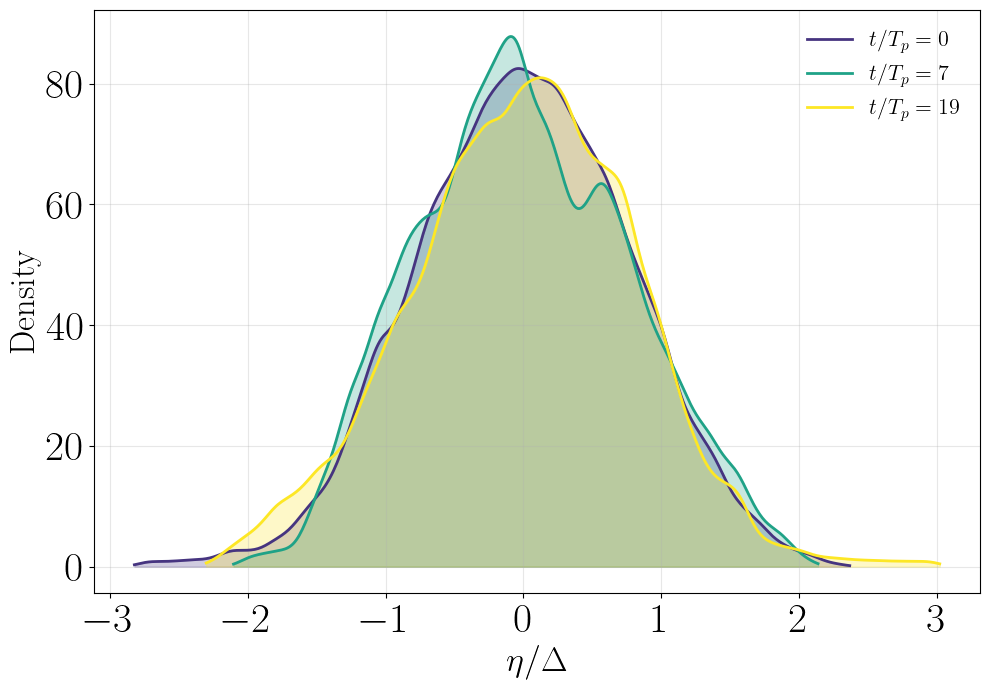

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- índices seleccionados ---
indices = [0, 450, -120]
deltamax = 2*np.pi/(2**(10))
# --- paleta de colores bonita y coherente ---
colors = plt.cm.viridis(np.linspace(0.15, 1, len(indices)))  # tonos verdes-azules
# otras opciones: 'plasma', 'cividis', 'magma', 'cool', 'cubehelix'

plt.figure(figsize=(10,7))

for i, c in zip(indices, colors):
    eta = np.asarray(eta_series[i] - np.mean(eta_series))  # η(x,y)
    vals = eta[np.isfinite(eta)].ravel()                   # flatten & clean NaNs

    kde = gaussian_kde(vals)
    x_vals = np.linspace(vals.min(), vals.max(), 400)
    pdf_vals = kde(x_vals)

    tTp = (time[i] - tstart) * omegap / (2 * np.pi)
    plt.plot(x_vals/deltamax, pdf_vals, lw=2, color=c,
             label=rf'$t/T_p = {tTp:.0f}$')
    plt.fill_between(x_vals/deltamax, pdf_vals, color=c, alpha=0.25)

# --- estética ---
plt.xlabel(r'$\eta/\Delta$', fontsize=25)
plt.ylabel('Density', fontsize=25)
#plt.title(r'PDF of $\eta(x,y)$ at different times', fontsize=20)
plt.legend(fontsize=16, frameon=False)
plt.grid(True, alpha=0.3)
plt.savefig(graph_path + f'/eta_PDF_time_delta.pdf')
plt.tight_layout()

plt.show()

# $E(k_x, k_y)$

var 2.2425991e-05
mean -1.794831e-10
sum F 2.2425992006410423e-05
integral 2.2425992006411697e-05
sum polar integrated 2.2374550095291465e-05
var 2.1727972e-05
mean 3.774403e-11
sum F 2.1727969709644543e-05
integral 2.1727969709645777e-05
sum polar integrated 2.1667519107434966e-05
var 2.475697e-05
mean 2.0600055e-10
sum F 2.4756968699280802e-05
integral 2.4756968699282215e-05
sum polar integrated 2.4744315657079863e-05


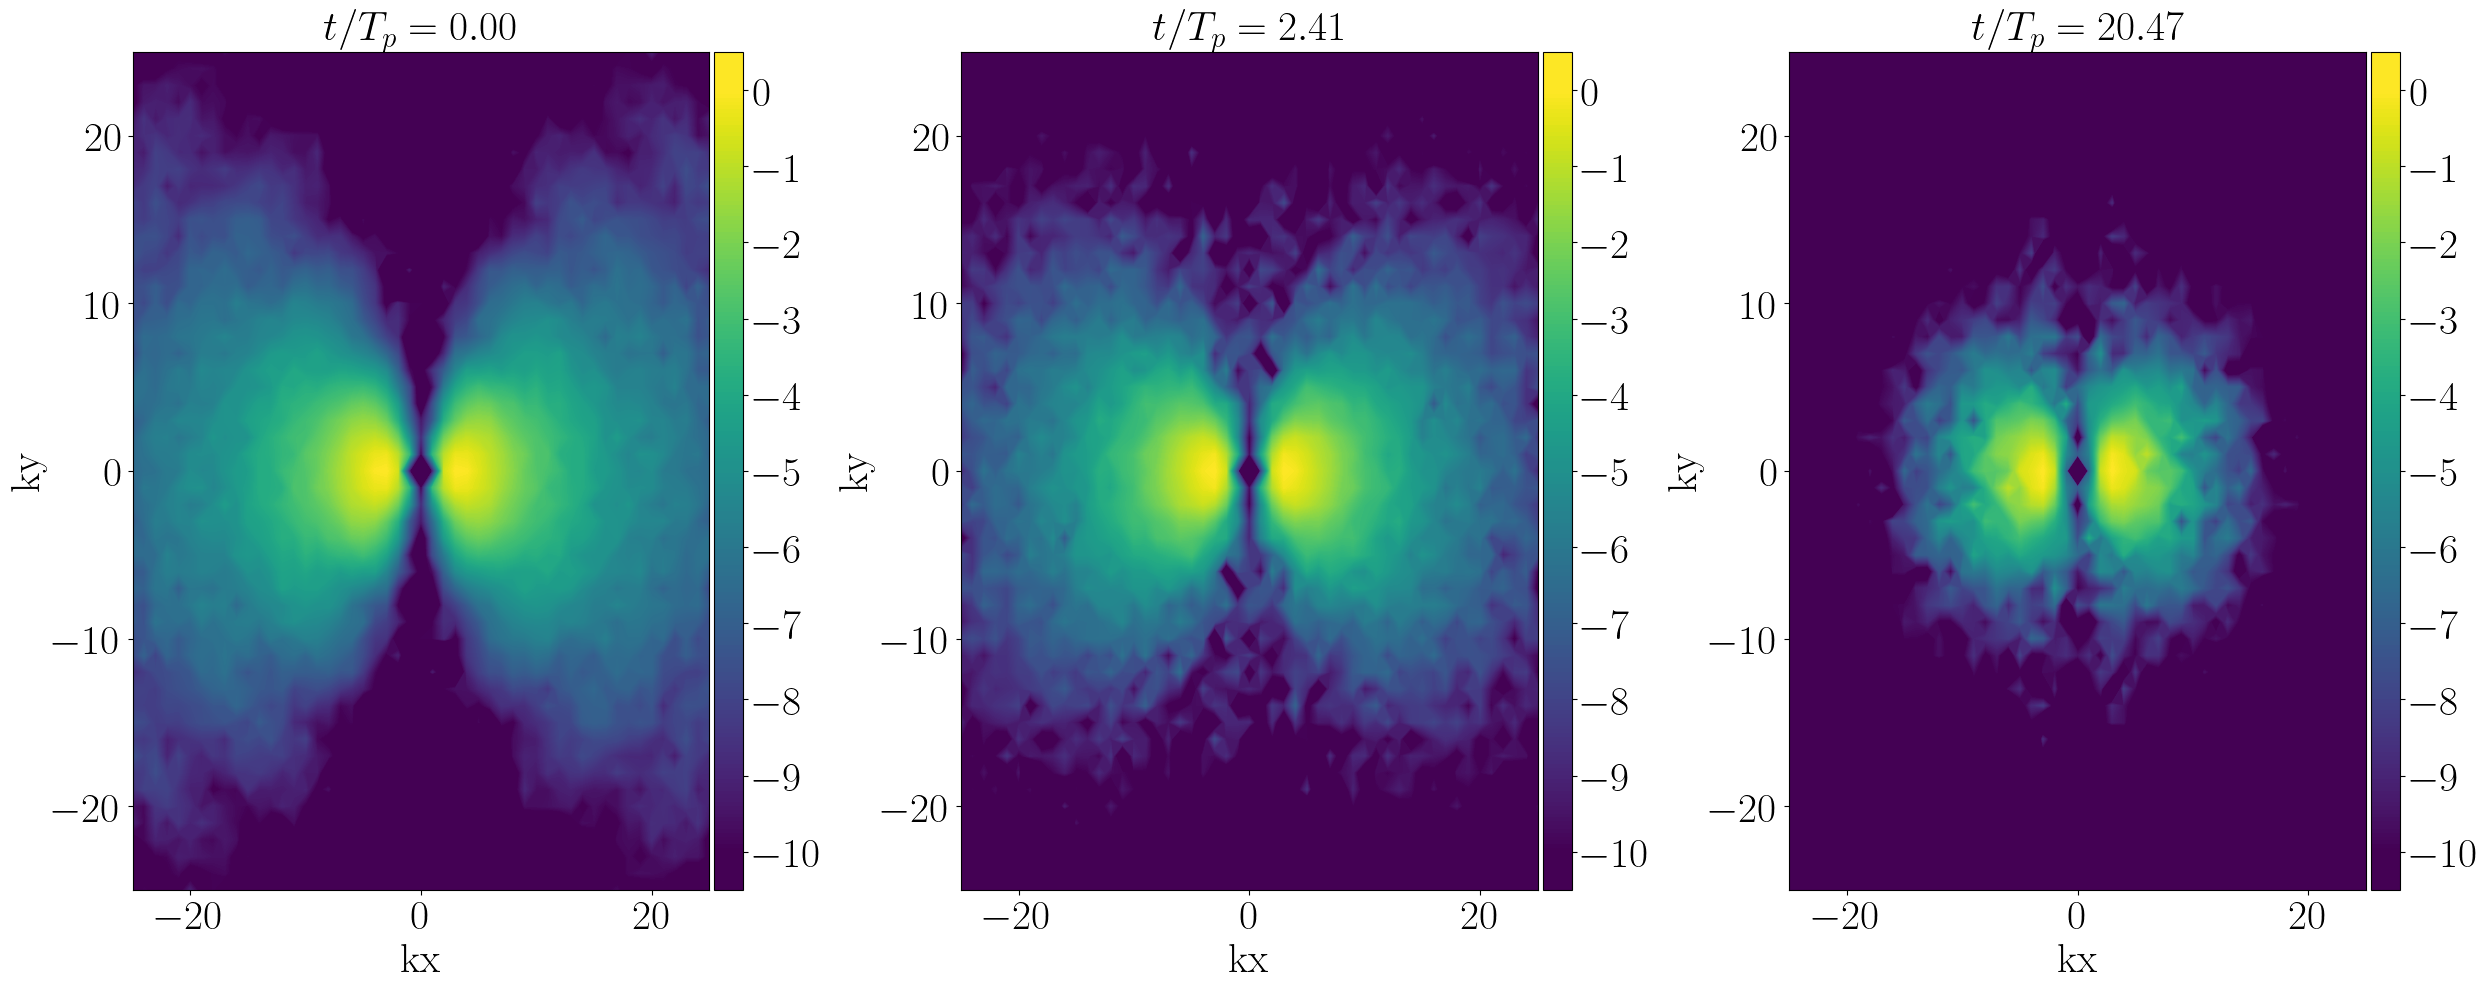

In [27]:
num_rows = 1
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 10))
j = 0
lim = 200
L = 2*np.pi
for i in ind_time:
    
    eta = eta_series[i]
    
    k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, variance, integral, polar_integral, kx, ky = spectrum_integration(eta - np.mean(eta), N, L, CHECK=True) #ypu can chose to check the normalization
    
    norm = np.argmax(F_center)
    
    vmin = -10
    vmax = 0
    levels = np.linspace(vmin, vmax, 200)
    
    ax = axes[j % num_cols]
    
    im = ax.contourf(kx, ky, np.log(F_center/np.max(F_center)), extend='both', levels=levels)
    
    #ax.set_aspect('equal')
    ax.set_title(label=r'$t/T_p=%.2f$' % (omegap * (time[i] - tstart)/(2*np.pi)))
    ax.set_xlabel('kx')
    ax.set_ylabel('ky')
    ax.set_ylim([-25, 25])
    ax.set_xlim([-25, 25])
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax, orientation='vertical', extendrect = 'False')
    
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x)}$'))
    #cbar.ax.yaxis.set_major_locator(plt.FixedLocator([-20, -15, -10, -5, 0]))
    ax.figure.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/Ekxky_{(omegap*(time[i]-tstart))}.png')
    j += 1
    
plt.savefig(graph_path + f'/F_kxky_time.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# $E(k, \theta)$

var 2.2425991e-05
mean -1.794831e-10
sum F 2.2425992006410423e-05
integral 2.2425992006411697e-05
sum polar integrated 2.2374550095291465e-05
var 2.1727972e-05
mean 3.774403e-11
sum F 2.1727969709644543e-05
integral 2.1727969709645777e-05
sum polar integrated 2.1667519107434966e-05
var 2.475697e-05
mean 2.0600055e-10
sum F 2.4756968699280802e-05
integral 2.4756968699282215e-05
sum polar integrated 2.4744315657079863e-05


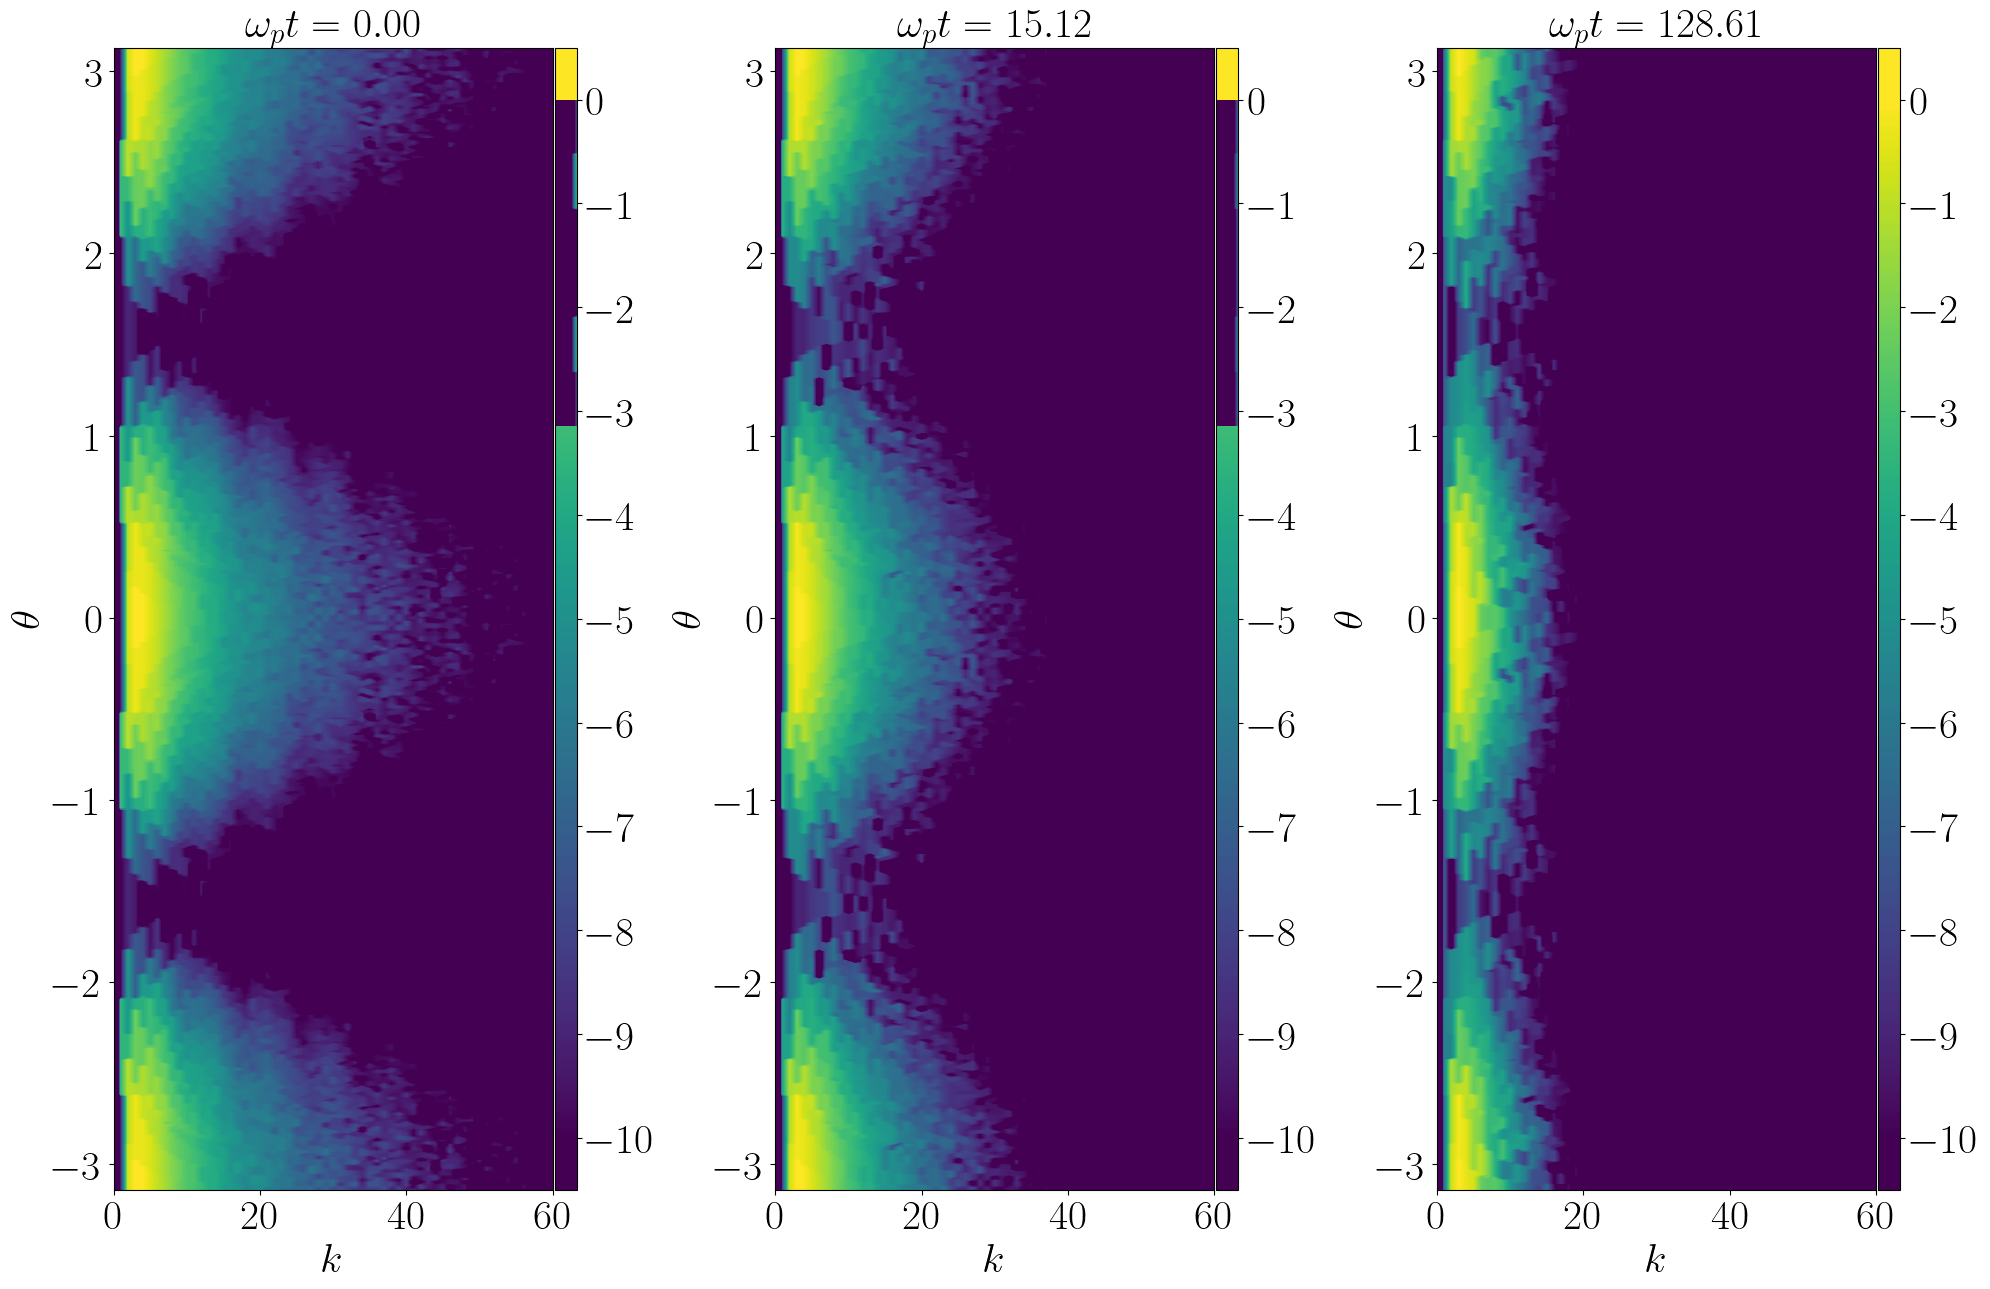

In [28]:
num_rows = 1
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 13))
j = 0

variance =[]
integral = []
polar_integral = []

for i in ind_time:
    eta = eta_series[i]
    
    k, F_center, F_center_polar_integrated , F_center_polar , k_tile, kxp_tile, kyp_tile , theta_tile , theta , variance, integral, polar_integral , kx, ky = spectrum_integration(eta-np.mean(eta), N,L,CHECK=True)
    
    vmin = -10
    vmax= 0
    levels = np.linspace(vmin, vmax, 200)
    
    
    plt.contourf(k_tile,theta_tile,np.log(F_center_polar/np.max(F_center_polar)), levels=levels,  extend='both' )#, cmap='viridis')
    
    ax = axes[j % num_cols]

    im = ax.contourf(k_tile,theta_tile,np.log(F_center_polar/np.max(F_center_polar)), levels=levels ,  extend='both')#, cmap='viridis')
    
    #ax.scatter(4,0,marker ='*', s=1, alpha= 1, c='r' )
    
    ax.set_title(label=r'$\omega_{p} t=%.2f$'%(omegap*(time[i]-tstart)))
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.02)
    cbar = fig.colorbar(im, cax=cax, orientation='vertical', extendrect = 'False', fraction = 0.05, pad = 0.02,aspect =10)
    
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x)}$'))
    #cbar.ax.yaxis.set_major_locator(plt.FixedLocator([-20, -15, -10, -5, 0]))
    
    ax.set_xlim([0,60])
    ax.set_xlabel('$k$')
    ax.set_ylabel(r"$ \theta $")
    ax.figure.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/Ektheta_{(omegap*(time[i]-tstart))}.png')
    j += 1
    
plt.savefig(graph_path + f'/F_ktheta_time.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
#plt.savefig("g1_tend", dpi=300)
plt.show()

# $E(k,t)$

<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3663230/3719216567.py:53: SyntaxWarning: invalid escape sequence '\p'
  plt.text(2, 10**(-4.5), f'$ \propto k^{{-5/2}}$', c='grey', fontsize = 20)
/tmp/ipykernel_3663230/3719216567.py:54: SyntaxWarning: invalid escape sequence '\p'
  plt.text(6.3, 10**(-6.1), f'$\propto k^{{-3}}$', c='grey', fontsize = 20)
/tmp/ipykernel_3663230/3719216567.py:68: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
/tmp/ipykernel_3663230/3719216567.py:69: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathdefault{\Phi_{0}(k)}$', fo

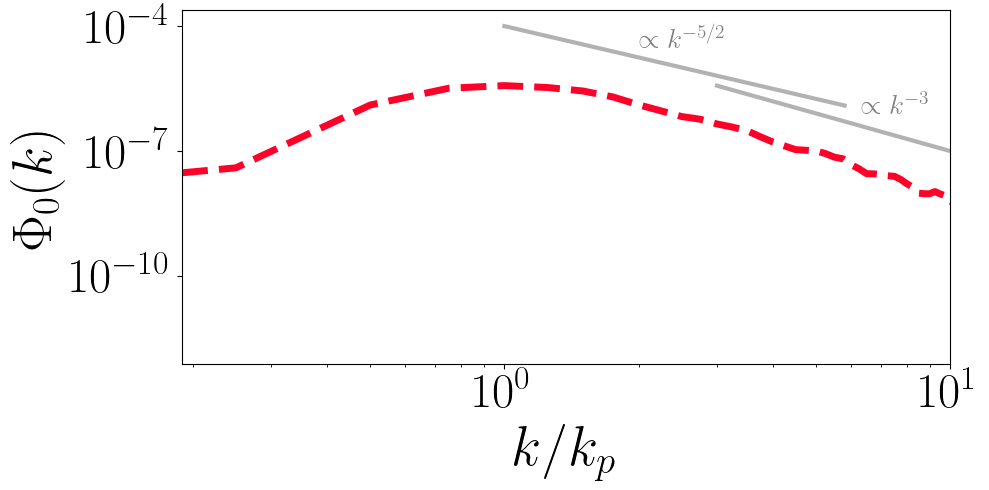

In [29]:
color_map = plt.cm.gist_rainbow
fig = plt.figure(figsize=(10, 5))
ax = fig.gca()

num_rows = 2
num_cols = 3

kp = 4
j = 0

variance = []
integral = []
polar_integral = []

# modes growth
energy_mode = []
coordx_mode = []
k_second = []

energy_secondmode = []
coordx_secondmode =[]
pylab.rcParams.update(params)

filtered_coordx_mode = []
filtered_energy_mode = []

#Loop in time


#for i in range(len(eta_series)):
for i in [0]:
    eta = eta_series[i]
    #print(i, variance)
    k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky = spectrum_integration(
        eta - np.mean(eta), N, L, CHECK=False)
    #print('k', k, 'kx', kx[int(len(kx)/2):])
    #k = kx[int(len(kx)/2):]
    dk = k[1] - k[0]

    psd = ax.plot(k/4, F_center_polar_integrated, '--', color=plt.cm.get_cmap('gist_rainbow')(j), alpha=1, linewidth=5)
        
    j += 1


color_values =  (omegap*(np.array(time)-time[0]))


k_scale = np.linspace(1, 5.8)
k_scale2 = np.linspace(3, 10)
# Multiply by a factor to shift the gray line vertically (adjust 1e-3 to co
plt.plot(k_scale2, 1e-4 * k_scale2**(-3), lw = 3, c='grey', alpha=0.6)
plt.plot(k_scale, 1e-4 * k_scale**(-5/2), lw = 3, c='grey', alpha=0.6)
plt.text(2, 10**(-4.5), f'$ \propto k^{{-5/2}}$', c='grey', fontsize = 20)
plt.text(6.3, 10**(-6.1), f'$\propto k^{{-3}}$', c='grey', fontsize = 20)

norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])  


fig.tight_layout()
#cbar.set_label('$\omega_{p} t$')
plt.yscale('log')
plt.xscale('log')
plt.xlim([0,10])
#plt.ylim([10**-11,10**-3])
plt.yscale('log')
plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
plt.ylabel('$\mathdefault{\Phi_{0}(k)}$', fontsize=40)

# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=35)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=35)  # Opcional: tamaño para etiquetas menores

#plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/kpHs{kpHs}uoc{uoc}_Ekinitial.png', dpi=300, bbox_inches='tight')
plt.savefig(graph_path + f'/Ekinitial.png', dpi=300, bbox_inches='tight')
fig.tight_layout()

In [30]:
import math as m
variance = []
ak = []
def spectrum_integration(eta, N,L,z_values,CHECK=True):
    """ This function performs azimuthal integration of the 2D spectrum (Notice it's 2D instead of 3D with the frequency as well).
        When in doubt, enable CHECK so that the integration is printed out at each step to make sure that 
        units are consistent and we always recover the variance of the data. """  
    #print('N=%g' %N + ', L=%g' %L)
    varr =  np.var(eta)
    
    if CHECK: print('var', np.var(eta))
    
    variance.append(varr)
    if CHECK:print('mean', np.mean(eta))
    
    T0 = 2*np.pi # L0/k = 2pi/4pi
    deltaf = 1/ 2*np.pi
    wavenumber = 2*np.pi*np.fft.fftfreq(N,L/N)
    kx = np.fft.fftshift(wavenumber); ky = kx
    kx_tile, ky_tile = np.meshgrid(kx,ky)
    theta = 2*np.pi*np.arange(-N/2,N/2)/(N)
    
    k = wavenumber[0:int(N/2)]
    dkx = kx[1] - kx[0]; dky = ky[1] - ky[0]
    dk = k[1]-k[0]; dtheta = theta[1]-theta[0]
    dkx = kx[1]-kx[0]; dky = ky[1]-ky[0]
    
    spectrum = np.fft.fft2(eta)/(N*N)**0.5  # FFT normalization 
    F = np.absolute(spectrum)**2/N**2/(dkx*dky) # Per area normalization
    
    if CHECK: print ('sum F', np.sum(F))
    F_center = np.fft.fftshift(F,axes=(0,1)) # Further normalization by independent variables
    
    k_tile, theta_tile = np.meshgrid(k,theta)
    kxp_tile, kyp_tile = pol2cart(k_tile, theta_tile)
    
    integ = np.sum(F_center)*dkx*dky
    if CHECK:print('integral',np.sum(F_center)*dkx*dky)
    
    integral.append(integ)
    ak.append(4*varr/2*k_tile)
    F_center_polar = scipy.interpolate.griddata((kx_tile.ravel(),ky_tile.ravel()), F_center.ravel(), (kxp_tile, kyp_tile), method='nearest', fill_value=0)
    F_center_polar_integrated = np.sum(F_center_polar*k_tile, axis=0)*dtheta # Azimuthal integration
    eps = 1e-10
    int_pol = np.sum(F_center_polar_integrated)*dk
    #print('denominator',np.sqrt(g*k_tile+sigma/rho1*k_tile**3))
    denominator = np.sqrt(g*k+sigma/rho1*k**3)
    denominator = np.where(denominator < eps, 1e-20, denominator)  # Reemplaza valores pequeños por eps
    
    drift = 2*np.sum(F_center_polar_integrated*k**2/denominator)*dk
    drift_pizzo = 2*np.sum(F_center_polar_integrated*k*np.sqrt(g*k))*dk
    drifts = []
    print('integration starts')
    for z in z_values: 
        #print(z)
        driftt = 2 * np.sum(F_center_polar_integrated * k**2 * np.exp(2 * k * z) / denominator) * dk
        drifts.append(driftt)
    
    #print('integrator', F_center_polar_integrated*k_tile,'integrator and den', F_center_polar_integrated*k_tile/np.sqrt(g*k_tile+sigma/rho1*k_tile**3),'drift', drift)
    print(drift)
    if CHECK: print ('sum polar integrated', np.sum(F_center_polar_integrated)*dk)
    
    polar_integral.append(int_pol)
    
    return k, F_center, F_center_polar_integrated , F_center_polar , k_tile, kxp_tile, kyp_tile , theta_tile , theta , varr, integ, polar_integral , kx, ky, drift, drift_pizzo, drifts, ak 


var 2.2425991e-05
mean -1.794831e-10
sum F 2.2425992006410423e-05
integral 2.2425992006411697e-05
integration starts
0.0004494209563110945
sum polar integrated 2.2374550095291465e-05
integral 0.0018666907994510167 drift pizzo 0.0018666907994510167


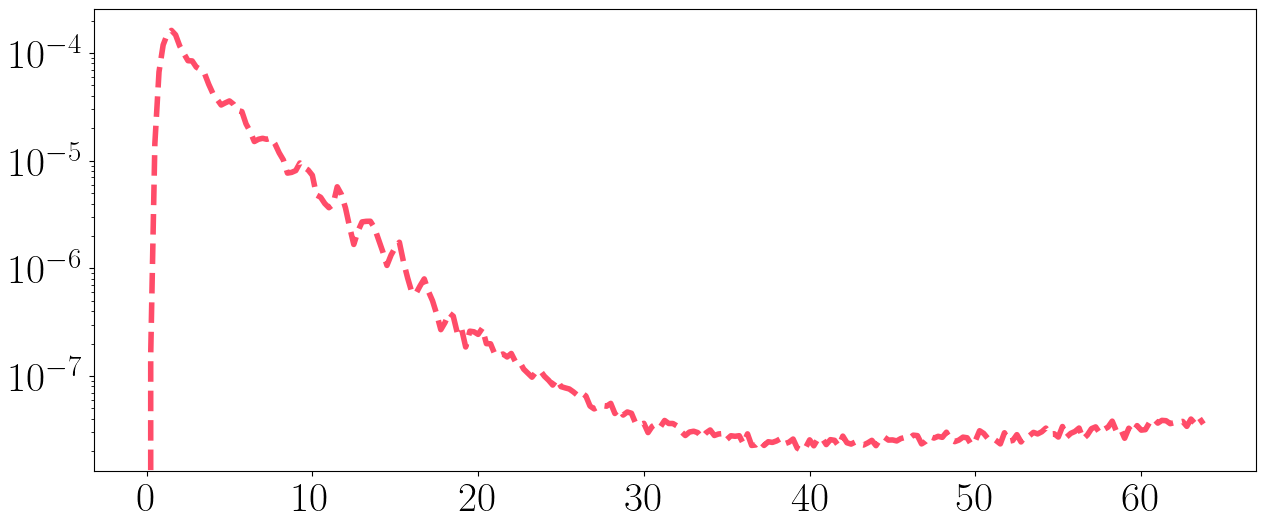

In [31]:
eta = eta_series[0]
z_values = np.arange(1,1-2*np.pi , -0.01) #1-2*np.pi
k, F_center, F_center_polar_integrated_t0, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky, drift , drift_small, drifts, ak= spectrum_integration(
            eta - np.mean(eta), N, L, z_values, CHECK=True)
plt.plot(k/4, 2*F_center_polar_integrated*k*np.sqrt(g*k), '--',color=color_map(j / len(eta_series)), alpha=0.7, linewidth=4)
print('integral',2*np.sum(F_center_polar_integrated*k*np.sqrt(g*k))*dk, 'drift pizzo',drift_small)
plt.yscale('log')

<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3663230/3471995959.py:53: SyntaxWarning: invalid escape sequence '\p'
  plt.text(2, 10**(-4.5)/np.max(F_center_polar_integrated_t0), f'$ \propto k^{{-5/2}}$', c='grey', fontsize = 20)
/tmp/ipykernel_3663230/3471995959.py:54: SyntaxWarning: invalid escape sequence '\p'
  plt.text(6.3, 10**(-6.1)/np.max(F_center_polar_integrated_t0), f'$\propto k^{{-3}}$', c='grey', fontsize = 20)
/tmp/ipykernel_3663230/3471995959.py:68: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
/tmp/ipykernel_3663230/3471995959.py:69: SyntaxWarning: i

var 2.2425991e-05
mean -1.794831e-10
sum F 2.2425992006410423e-05
integral 2.2425992006411697e-05
integration starts
0.0004494209563110945
sum polar integrated 2.2374550095291465e-05


/tmp/ipykernel_3663230/3471995959.py:65: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,10])


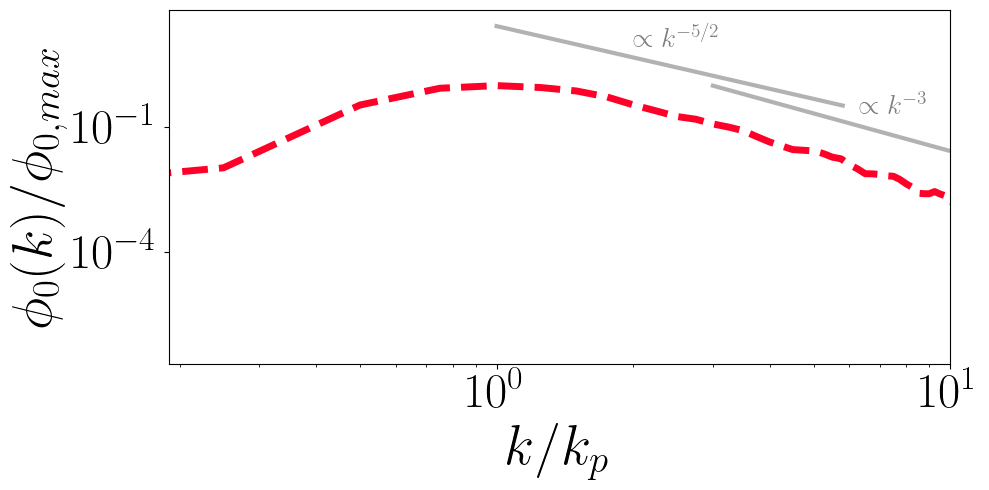

In [32]:
color_map = plt.cm.gist_rainbow
fig = plt.figure(figsize=(10, 5))
ax = fig.gca()

num_rows = 2
num_cols = 3

kp = 4
j = 0

variance = []
integral = []
polar_integral = []

# modes growth
energy_mode = []
coordx_mode = []
k_second = []

energy_secondmode = []
coordx_secondmode =[]
pylab.rcParams.update(params)

filtered_coordx_mode = []
filtered_energy_mode = []

#Loop in time


#for i in range(len(eta_series)):
for i in [0]:
    eta = eta_series[i]
    #print(i, variance)
    k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky, drift , drift_small, drifts, ak= spectrum_integration(
            eta - np.mean(eta), N, L, z_values, CHECK=True)
    #print('k', k, 'kx', kx[int(len(kx)/2):])
    #k = kx[int(len(kx)/2):]
    dk = k[1] - k[0]

    psd = ax.plot(k/4, F_center_polar_integrated/np.max(F_center_polar_integrated_t0), '--', color=plt.cm.get_cmap('gist_rainbow')(j), alpha=1, linewidth=5)
        
    j += 1


color_values =  (omegap*(np.array(time)-time[0]))


k_scale = np.linspace(1, 5.8)
k_scale2 = np.linspace(3, 10)
# Multiply by a factor to shift the gray line vertically (adjust 1e-3 to co
plt.plot(k_scale2, 1e-4 * k_scale2**(-3)/np.max(F_center_polar_integrated_t0), lw = 3, c='grey', alpha=0.6)
plt.plot(k_scale, 1e-4 * k_scale**(-5/2)/np.max(F_center_polar_integrated_t0), lw = 3, c='grey', alpha=0.6)
plt.text(2, 10**(-4.5)/np.max(F_center_polar_integrated_t0), f'$ \propto k^{{-5/2}}$', c='grey', fontsize = 20)
plt.text(6.3, 10**(-6.1)/np.max(F_center_polar_integrated_t0), f'$\propto k^{{-3}}$', c='grey', fontsize = 20)

norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])  


fig.tight_layout()
#cbar.set_label('$\omega_{p} t$')
plt.yscale('log')
plt.xscale('log')
plt.xlim([0,10])
#plt.ylim([10**-11,10**-3])
plt.yscale('log')
plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
plt.ylabel('$\mathdefault{\phi_{0}(k)}/\phi_{0,max}$', fontsize=40)

# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=35)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=35)  # Opcional: tamaño para etiquetas menores

#plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/kpHs{kpHs}uoc{uoc}_Ekinitial.png', dpi=300, bbox_inches='tight')
plt.savefig(graph_path + f'/Ekinitial.png', dpi=300, bbox_inches='tight')
fig.tight_layout()

<>:172: SyntaxWarning: invalid escape sequence '\m'
<>:173: SyntaxWarning: invalid escape sequence '\m'
<>:172: SyntaxWarning: invalid escape sequence '\m'
<>:173: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3663230/243227023.py:172: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
/tmp/ipykernel_3663230/243227023.py:173: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathdefault{\phi(k)/ \phi_{0,max}$', fontsize=40)
/tmp/ipykernel_3663230/243227023.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('viridis')


var 2.2425991e-05
mean -1.794831e-10
sum F 2.2425992006410423e-05
integral 2.2425992006411697e-05
integration starts
0.0004494209563110945
sum polar integrated 2.2374550095291465e-05
var 2.2440861e-05
mean -4.6611603e-11
sum F 2.2440860490340347e-05
integral 2.2440860490341615e-05
integration starts
0.0004481737591182594
sum polar integrated 2.2380522333920958e-05
var 2.2442347e-05
mean 6.82121e-13
sum F 2.2442347845776752e-05
integral 2.2442347845778026e-05
integration starts
0.0004465336394050732
sum polar integrated 2.237314617153682e-05
var 2.2434411e-05
mean 1.6396484e-10
sum F 2.2434410869186325e-05
integral 2.2434410869187596e-05
integration starts
0.0004444534696142962
sum polar integrated 2.235712697094711e-05
var 2.2424836e-05
mean 1.463718e-10
sum F 2.242483664155489e-05
integral 2.242483664155616e-05
integration starts
0.000442783937504598
sum polar integrated 2.2341426720140057e-05
var 2.2415863e-05
mean 7.5544904e-11
sum F 2.2415862397595872e-05
integral 2.241586239759714

/tmp/ipykernel_3663230/243227023.py:168: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10)


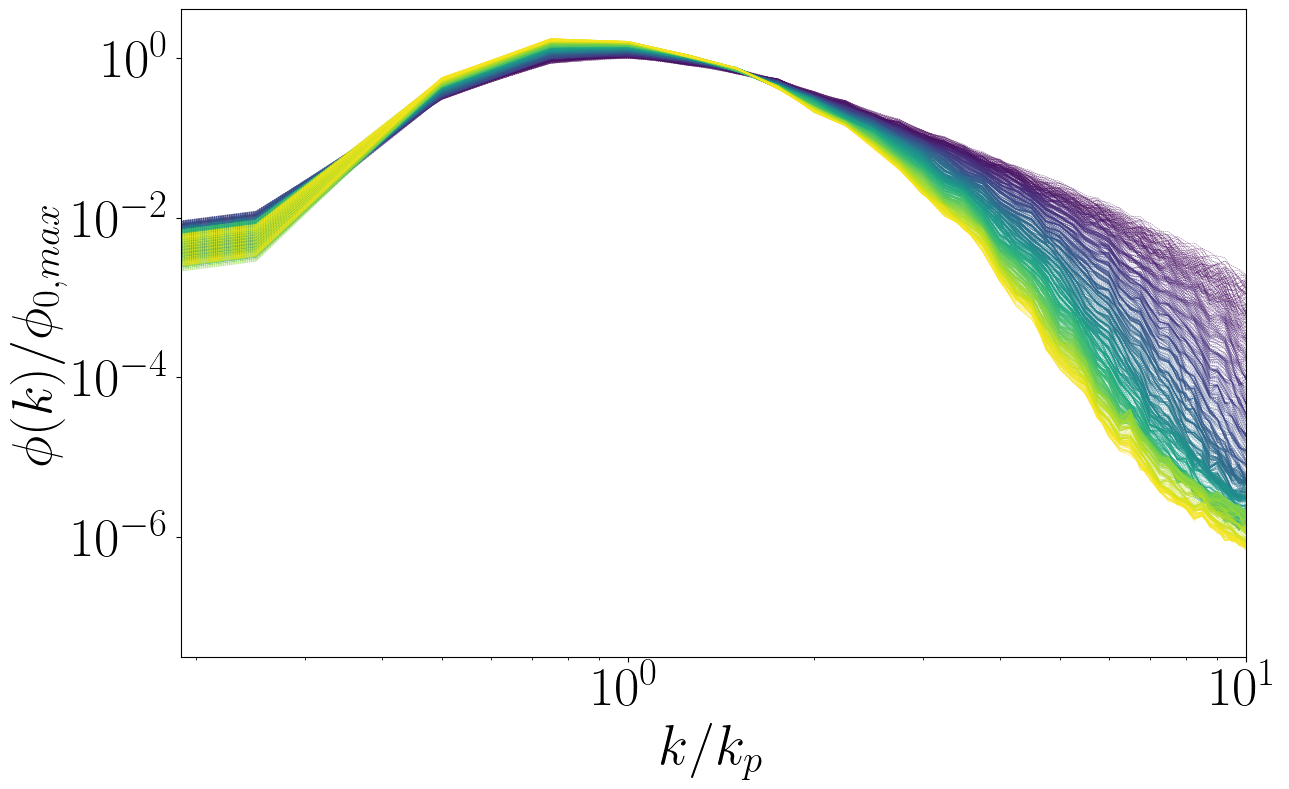

In [33]:
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from scipy import integrate
import csv
import importlib


#module_path = '/home/cm6797/cmocean/cmocean/cmocean/__init__.py'
#spec = importlib.util.spec_from_file_location("cmocean", module_path)
#cmocean = importlib.util.module_from_spec(spec)
#spec.loader.exec_module(cmocean)

z_values = np.arange(1, 1-2*np.pi, -0.001)

color_map = plt.cm.get_cmap('viridis')
fig, ax = plt.subplots(figsize =(13,8))

num_rows = 2
num_cols = 3

j = 0

variance = []
integral = []
polar_integral = []

k_seleccionados =[]

# modes growth
energy_interval_time = []
coordx_mode = []
k_second = []

energy_secondmode = []
coordx_secondmode =[]

F_mode =[]
filtered_coordx_mode = []
filtered_energy_mode = []

E_interval = []
E_total_time = []
stokes_drif = []
variance =[]
integral = []
stokes_drif_pizzo =[]
drifts_time =[]



with open(f'/projects/DEIKE/cmartinb/eta/eta_series_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}_energies.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    for i in range(len(eta_series)):

        #recorre el tiempo

        eta = eta_series[i]
        #print('time', i)
        k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky, drift , drift_small, drifts, ak= spectrum_integration(
            eta - np.mean(eta), N, L, z_values, CHECK=True)

        E_interval = []

        #print(len(drifts))
        norm = np.max(F_center_polar_integrated_t0)

        psd = ax.plot(k/4, F_center_polar_integrated/norm, '--',color=color_map(j / len(eta_series)), alpha=0.7, linewidth=0.3)

        for m in range(41):
            if m == 0:
                # Primer punto
                idx_start, idx_end = 0, 1
            elif m == len(k) - 1:
                # Último punto
                idx_start, idx_end = m - 1, m
            else:
                # Puntos intermedios
                idx_start, idx_end = m - 1, m + 1
                
            F_integral_interval = integrate.trapezoid(F_center_polar_integrated[idx_start:idx_end+1], k[idx_start:idx_end+1])
            
            #print('idx start',idx_start, 'idx end', idx_end )
            
            k_seleccionados.append(k[m]) # lista con la energia de cada intervalo [IN .....IN]

            
            #ax.axvline(x = k[m]/4, color = 'grey', alpha =0.3)
            
            #print('k[idx_start]',k[idx_start],'k[idx_end]', k[idx_end])
            
            #print('i',i,'interval' ,k[idx_start:idx_end+1], 'F_center_polar_integrated',F_center_polar_integrated[idx_start:idx_end+1], 'F ingrated interpol', F_integral_interval,'l',m)
            
            #variance.append(varr)
            
            E_interval.append(F_integral_interval)
            
            writer.writerow([i, m, F_integral_interval, omegap*(time[i]-time[0])/(2 * np.pi)])
        
            E_total = np.sum(F_center_polar_integrated) * dk


            #print('drift',drifts)
            #print('drifts',drifts)
            #drift = np.sum(drift)
        
        E_total_time.append(E_total)
        stokes_drif.append(drift)
        stokes_drif_pizzo.append(drift_small)
        energy_interval_time.append(E_interval) #lista con la energia de todos intervalos para cada tiempo [[I1.... IN]_0.....[IN...IN]_N] en tiempo i
        #variance.append(varr)
        #writer.writerow(E_interval)
        drifts_time.append(drifts)
        
        j += 1

# plot where are the nodes
#for km in k_seleccionados:
    #ax.axvline(x=km/4, color='gray', linestyle='--', linewidth=0.3)

ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.yaxis.set_ticks([10**-7, 10**-4])  # Solo 2 ticks en el eje y

color_values =  (omegap*(np.array(time)-time[0])/ (2 * np.pi))

# Now set the normalization with the correct range

norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])  

# Add the colorbar to the figure
#cbar = plt.colorbar(sm, orientation='horizontal', pad=0.25)

# Set colorbar label and other properties if needed
#cbar.set_label('$t/T_{p}$')


k_scale = np.linspace(1, 10)
k_scale2 = np.linspace(3, 10)
# Multiply by a factor to shift the gray line vertically (adjust 1e-3 to co
#plt.plot(k_scale2, 1e-4 * k_scale2**(-3), lw = 3, c='grey', alpha=0.6)
#plt.plot(k_scale, 1e-4 * k_scale**(-5/2), lw = 3, c='grey', alpha=0.6)
#plt.text(3.5, 10**(-5), f'$\propto 5/2$', c='grey', fontsize = 20)
#plt.text(3.5, 10**(-5), f'$\propto 5/2$', c='grey', fontsize = 20)

ax.yaxis.set_ticks([10**-2, 10**0]) 
# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=40)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=40)  # Opcional: tamaño para etiquetas menores


#plt.hlines(1,0,10, color='gray', linestyle='--', linewidth=2)


fig.tight_layout()
'''
plt.xscale('log')
plt.xlim([0.0000001,10])
plt.yscale('log')
plt.ylim([10**(-4.5),10**(0)])
'''

# 2) then set scales
ax.set_xscale('log')
ax.set_yscale('log')

# 3) then set limits (all positive!)
ax.set_xlim(0, 10)
#ax.set_ylim(10**(-4.5), 10**(0))


plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
plt.ylabel('$\mathdefault{\phi(k)/ \phi_{0,max}$', fontsize=40)
#plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/Ek_total.png')
#plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/kpHs{kpHs}uoc{uoc}/kpHs{kpHs}uoc{uoc}_Ektotal.png', dpi=300, bbox_inches='tight')
plt.savefig(graph_path + f'/Ektime.pdf', dpi=300, bbox_inches='tight')
fig.tight_layout()

In [34]:
#print(E_total_time)
mean = np.mean(np.array(E_total_time))
rms = np.sqrt(mean)
print(f"RMS: {rms}")

delta_grid = 2*np.pi/(2**(10))

print("RMS/delta", rms/delta_grid)

RMS: 0.004773012528030729
RMS/delta 0.7778801021702494


In [35]:
""" CODE CALCUL DRIFT """

#u_s = (kpHs)**2*c*np.exp(2*k*z)

#drift_sk = 2 * E_total_time 

' CODE CALCUL DRIFT '

In [36]:
print(len(drifts_time), len(eta_series))

1311 1311


In [37]:
'''
selected_times_indices = range(0, len(drifts_time), 10)  # Cada 10 tiempos

for i in selected_times_indices:
    drifts_for_this_time = drifts_time[i]  # Obtenemos el drift correspondiente a este tiempo
    
    # Etiqueta de la curva usando el tiempo "físico"
    label_time = f"t = {omegap*(time[i]-time[0])/(2*np.pi):.2f}" if time is not None else f"Time {i}"
    
    # Graficar drift en función de z
    plt.plot(drifts_for_this_time, z_values, label=label_time)

# Limitar los ejes según lo deseado
plt.xlim([0, 0.1])  # Limitar el rango de x
plt.ylim([-0.1, 0.1]) 
plt.xlabel('u(z)')  # Etiqueta en x
plt.ylabel('z')     # Etiqueta en z
#plt.title('Perfil de u(z) para ciertos tiempos seleccionados')
plt.grid(True)
#plt.legend()
plt.show()
'''

'\nselected_times_indices = range(0, len(drifts_time), 10)  # Cada 10 tiempos\n\nfor i in selected_times_indices:\n    drifts_for_this_time = drifts_time[i]  # Obtenemos el drift correspondiente a este tiempo\n    \n    # Etiqueta de la curva usando el tiempo "físico"\n    label_time = f"t = {omegap*(time[i]-time[0])/(2*np.pi):.2f}" if time is not None else f"Time {i}"\n    \n    # Graficar drift en función de z\n    plt.plot(drifts_for_this_time, z_values, label=label_time)\n\n# Limitar los ejes según lo deseado\nplt.xlim([0, 0.1])  # Limitar el rango de x\nplt.ylim([-0.1, 0.1]) \nplt.xlabel(\'u(z)\')  # Etiqueta en x\nplt.ylabel(\'z\')     # Etiqueta en z\n#plt.title(\'Perfil de u(z) para ciertos tiempos seleccionados\')\nplt.grid(True)\n#plt.legend()\nplt.show()\n'

range(0, 1311, 150)


/tmp/ipykernel_3663230/1406706172.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('viridis', len(selected_times_indices))  # Gradación de colores


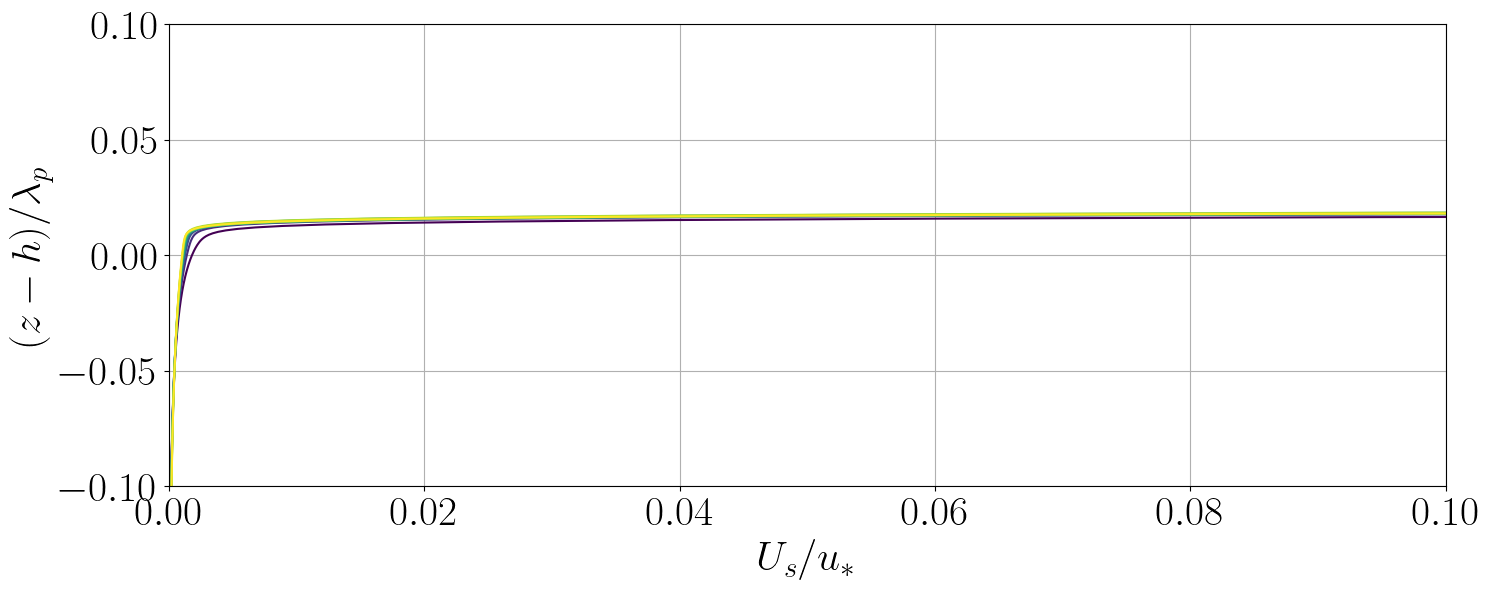

In [38]:
# Selección de índices de tiempos, por ejemplo, cada 150 tiempos
selected_times_indices = range(0, len(drifts_time), 150)  # Ajusta el paso según desees
print(selected_times_indices)
# Mapa de colores
color_map = plt.cm.get_cmap('viridis', len(selected_times_indices))  # Gradación de colores

#plt.figure(figsize=(8, 6))

for idx, i in enumerate(selected_times_indices):
    drifts_for_this_time = drifts_time[i]  # Obtenemos el drift correspondiente a este tiempo
    #print(i, drifts_for_this_time)
    # Etiqueta de la curva usando el tiempo "físico"
    label_time = f"t = {omegap*(time[i]-time[0])/(2*np.pi):.2f}" if time is not None else f"Time {i}"
    
    #drift_normalized = [u_norm/u for u_norm in drifts_for_this_time]
    
    # Graficar drift en función de z con un color del mapa
    plt.plot(np.array(drifts_for_this_time)/u, (z_values)/lambdap, label=label_time, color=color_map(idx))

# Limitar los ejes según lo deseado
plt.xlim([0, 0.1])  # Limitar el rango de x
plt.ylim([-0.1, 0.1]) 
plt.xlabel(r'$U_s/u_*$')  # Etiqueta en x
plt.ylabel(r'$(z-h)/ \lambda_p$')     # Etiqueta en z
plt.grid(True)

# Crear la barra de colores para indicar la escala temporal
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=(omegap*(time[-1]-time[0])/(2*np.pi))))
sm.set_array([])  # No necesitas datos asociados, solo el mapa
#cbar = plt.colorbar(sm)
#cbar.set_label(f'$t/T_p$')
#plt.savefig(graph_path + f'/stokes_drift_zoom.png', dpi=300, bbox_inches='tight')
#plt.legend(fontsize=15, loc='lower right')
plt.tight_layout()
plt.show()


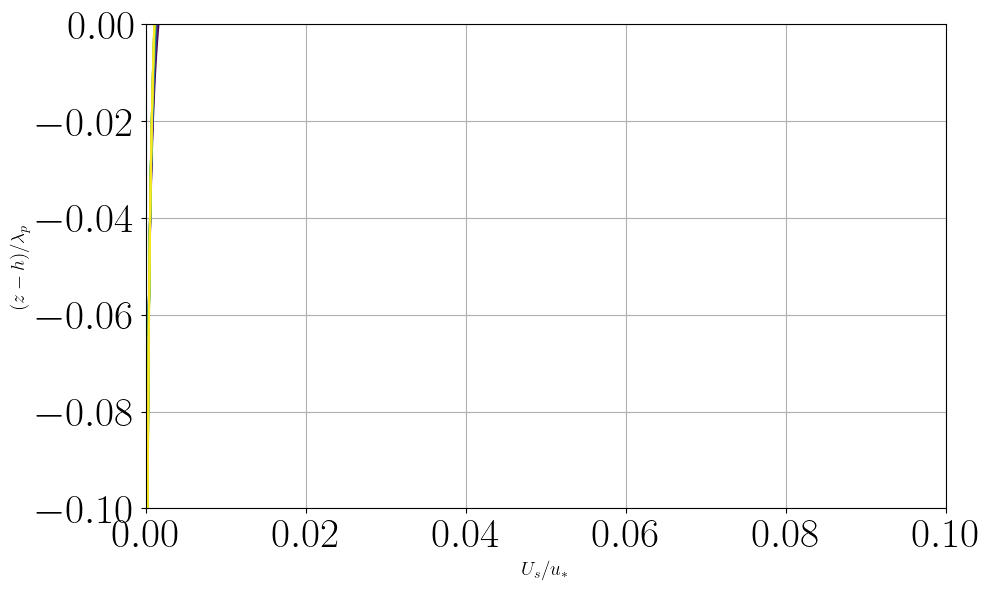

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la ventana
window_size = 150
overlap     = 0.5
step        = int(window_size * (1 - overlap))  # 75

# Convertir lista de perfiles a un array (nt, nz)
drifts_arr = np.array(drifts_time)

# Índices de inicio de cada ventana
starts = range(0, drifts_arr.shape[0] - window_size + 1, step)
n_windows = len(list(starts))

# --- Aquí corregimos el colormap ---
# 1) Sacamos el mapa continuo
base_cmap = plt.colormaps['viridis']
# 2) Muestreamos n_windows colores
colors = base_cmap(np.linspace(0, 1, n_windows))
# ---------------------------------------

plt.figure(figsize=(10, 6))
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start : start + window_size, :]  # (150, nz)
    drift_profile = np.mean(drift_window, axis=0)               # (nz,)

    # Tiempo medio de la ventana
    mid_idx    = start + window_size // 2
    t_mid      = time[mid_idx]
    label_time = f"t = {omegap*(t_mid - time[0])/(2*np.pi):.2f}"

    plt.plot(
        drift_profile / u,
        z_values / lambdap,
        label=label_time,
        color=colors[idx]
    )

plt.xlim([0, 0.1])
plt.ylim([-0.1, 0])
plt.xlabel(r'$U_s / u_*$', fontsize=14)
plt.ylabel(r'$(z-h) / \lambda_p$', fontsize=14)
plt.grid(True)
#plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()


In [40]:

datos = np.load(f'mean_velocity_Bo_{Bo}_kpHs{kpHs}_uoc{uoc}_L{maxLevel}.npz', allow_pickle=True)

phi_avg  = datos['phi_avg']
u_x_avg  = datos['u_x_avg']
intervals = datos['intervals']
times_moyens = datos['times_moyens']
time_normalized = datos['time_normalized']
u_atzero = datos['u_atzero']


[1.1718750028884672, 2.3437500057769345, 3.5156250086654017, 4.687500011553869, 5.859375014442336, 7.031250017330948, 8.203125020219415, 9.37499999127694, 10.546874994165409, 11.718749997053875, 12.890624999942343, 14.06250000283081, 15.234375005719277, 16.406250008607888, 17.578125011496358, 18.750000014384824] [0.00038838789930154737, 0.00035344991752364125, 0.0003322332698963159, 0.0003161736017920201, 0.00030420805289891744, 0.00029613100942096736, 0.0002898565122336914, 0.00028390074152541417, 0.0002786384371718327, 0.00027347081817144254, 0.0002683141629931897, 0.00026420549119247276, 0.0002617288614145033, 0.0002607700301794557, 0.0002598675824782796, 0.0002581851753181121]
DataFrame guardado en: /projects/DEIKE/cmartinb/notebooks/stokes_data/surface_stokes_drift.csv


IndexError: list index out of range

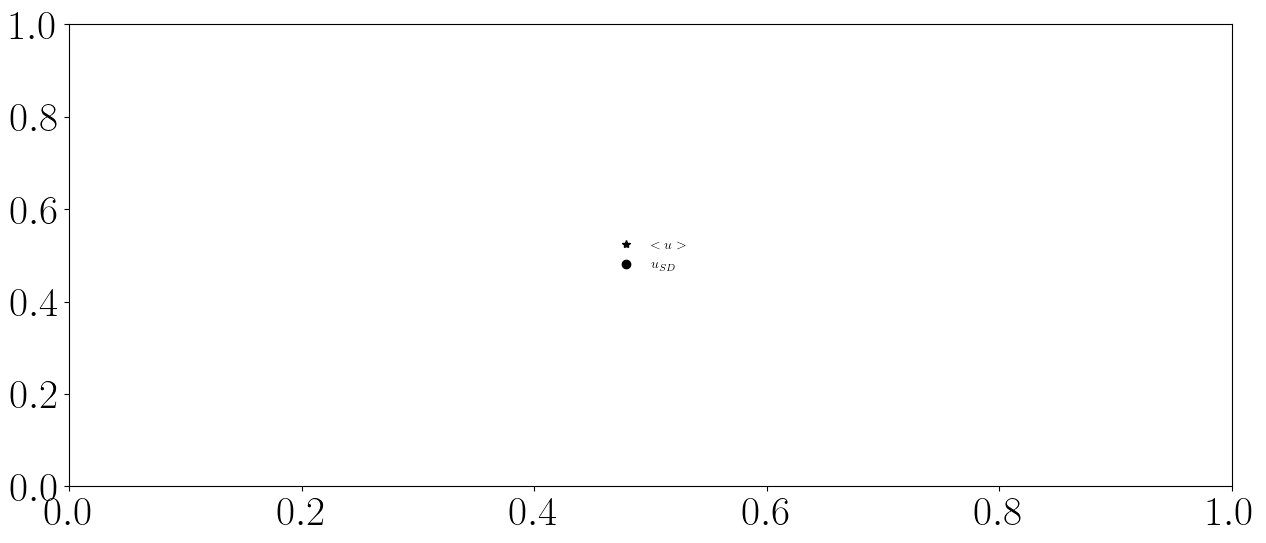

<Figure size 800x400 with 0 Axes>

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
time_mean = [np.mean([time_normalized[start], time_normalized[end]]) for start, end in intervals]
u_atzero_loaded = []
# --- Parámetros globales ya definidos antes ---
# drifts_time: lista o array de shape (nt, nz) con la deriva para cada tiempo y profundidad
# z_values: array de profundidades (nz,)
# time: array de tiempos físicos
# omegap: frecuencia pico de la ola
# graph_path: carpeta donde guardar los ficheros

# Parámetros de la ventana
window_size = 150
overlap     = 0.5
step        = int(window_size * (1 - overlap))  # 75 pasos entre inicios de ventana

interval_colors = plt.cm.viridis(np.linspace(0, 1,15))

# Convertir lista a array 2D (nt, nz)
drifts_arr = np.array(drifts_time)

# Índice más cercano a z = 0
z0_index = np.argmin(np.abs(z_values - 0))

# Construir los índices de inicio de cada ventana (hasta nt-window_size)
starts = range(0, drifts_arr.shape[0] - window_size + 1, step)

# Listas para almacenar resultados
surface_times  = []
surface_drifts = []

for start in starts:
    # 1) extraer la serie de drift en superficie para la ventana
    window_surface = drifts_arr[start : start + window_size, z0_index]
    mean_surface   = np.mean(window_surface)

    # 2) calcular tiempo normalizado en el punto medio de la ventana
    mid_idx = start + window_size // 2
    t_norm  = omegap * (time[mid_idx] - time[0]) / (2 * np.pi)

    surface_times.append(t_norm)
    surface_drifts.append(mean_surface)


    
print(surface_times,surface_drifts)

# 3) Crear DataFrame y guardar a CSV
df_surface = pd.DataFrame({
    't_over_Tp':       surface_times,
    'Stokes_drift_z0': surface_drifts
})

# Crear manejadores de leyenda personalizados
star_handle = plt.Line2D([], [], marker='*', linestyle='', color='black', label=r'$<u>$')
circle_handle = plt.Line2D([], [], marker='o', linestyle='', color='black', label=r'$u_{SD}$')

# Añadir leyenda en el centro del gráfico
plt.legend(
    handles=[star_handle, circle_handle],
    loc='center',
    frameon=False,
    fontsize=10
)
    
colors = interval_colors[:len(df_surface)]
csv_path = "/projects/DEIKE/cmartinb/notebooks/stokes_data/surface_stokes_drift.csv"
df_surface.to_csv(csv_path, index=False)
print(f"DataFrame guardado en: {csv_path}")

# 4) Plot de la serie temporal
plt.figure(figsize=(8, 4))
for i in range(len(intervals)):
    # Graficamos el punto del perfil medio a z=0 para el intervalo "i"
    plt.plot(time_mean[i], u_atzero_loaded[i], marker='*', linestyle='',
             color=interval_colors[i])
plt.scatter(df_surface['t_over_Tp'],
         df_surface['Stokes_drift_z0']/u,
         marker='o',c=colors)
plt.xlabel(r'$t/T_p$')
plt.ylabel(r'$u(z=0)/u_{*}$')
plt.yscale('log')
plt.savefig(graph_path + f'/stokesdriftsurfacelog.pdf', dpi=300, bbox_inches='tight')
#plt.title('Stokes drift ')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Robust + clean version (NO assumption same lengths)
# ============================================================
# Expected to exist before running:
#   drifts_time : list/array (nt, nz)  Stokes drift vs (t,z)
#   z_values    : array (nz,)
#   time        : array (nt,)          physical time (same nt as drifts_time)
#   omegap      : float               peak angular frequency
#   graph_path  : str                 output folder for plots
#   intervals   : list of (start,end) indices for your other data
#   time_normalized : array (nt,)     used to compute time_mean for star points
#   u_atzero_loaded : list/array      star values (may have different length)
#   u           : float               friction velocity for normalization

# ----------------------------
# Window parameters
# ----------------------------
window_size = 150
overlap = 0.5
step = max(1, int(window_size * (1 - overlap)))  # e.g. 75 if overlap=0.5

# ----------------------------
# Prepare arrays safely
# ----------------------------
drifts_arr = np.asarray(drifts_time)
time_arr   = np.asarray(time)

if drifts_arr.ndim != 2:
    raise ValueError(f"drifts_time must be 2D (nt,nz). Got shape {drifts_arr.shape}")

nt, nz = drifts_arr.shape
if time_arr.shape[0] != nt:
    raise ValueError(f"time length ({time_arr.shape[0]}) != drifts_time nt ({nt})")

z_values_arr = np.asarray(z_values)
if z_values_arr.shape[0] != nz:
    raise ValueError(f"z_values length ({z_values_arr.shape[0]}) != drifts_time nz ({nz})")

# closest index to z=0
z0_index = int(np.argmin(np.abs(z_values_arr - 0.0)))

# ----------------------------
# Compute surface Stokes drift in sliding windows
# ----------------------------
starts = range(0, nt - window_size + 1, step)

surface_times  = []
surface_drifts = []

for start in starts:
    end = start + window_size
    window_surface = drifts_arr[start:end, z0_index]
    mean_surface   = np.nanmean(window_surface)

    mid_idx = start + window_size // 2
    t_norm  = omegap * (time_arr[mid_idx] - time_arr[0]) / (2 * np.pi)

    surface_times.append(t_norm)
    surface_drifts.append(mean_surface)

df_surface = pd.DataFrame({
    "t_over_Tp": surface_times,
    "Stokes_drift_z0": surface_drifts
})

csv_path = "/projects/DEIKE/cmartinb/notebooks/stokes_data/surface_stokes_drift.csv"
df_surface.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")
print("Surface series:", len(df_surface), "points")

# ----------------------------
# Build star points robustly (NO same-length assumption)
# ----------------------------
star_x, star_y = [], []

# time_mean is defined from intervals + time_normalized, but keep it robust
time_norm_arr = np.asarray(time_normalized)

time_mean = []
for (start, end) in intervals:
    if start < 0 or end < 0 or start >= time_norm_arr.size or end >= time_norm_arr.size:
        time_mean.append(np.nan)
    else:
        time_mean.append(np.nanmean([time_norm_arr[start], time_norm_arr[end]]))

# pair only valid indices that exist in BOTH lists
n_star = min(len(time_mean), len(u_atzero_loaded))
for i in range(n_star):
    if np.isfinite(time_mean[i]) and np.isfinite(u_atzero_loaded[i]):
        star_x.append(time_mean[i])
        star_y.append(u_atzero_loaded[i])

print("Star series:", len(star_x), "points (after safe pairing)")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 4))

# Colors: enough for whichever series is longer
n_colors = max(len(star_x), len(df_surface), 1)
interval_colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

# stars
if len(star_x) > 0:
    plt.scatter(
        star_x,
        np.asarray(star_y) / u,
        marker="*",
        s=80,
        c=interval_colors[:len(star_x)],
        label=r"$\langle u \rangle$"
    )

# circles (surface Stokes drift)
if len(df_surface) > 0:
    plt.scatter(
        df_surface["t_over_Tp"].to_numpy(),
        (df_surface["Stokes_drift_z0"].to_numpy()) / u,
        marker="o",
        s=25,
        c=interval_colors[:len(df_surface)],
        label=r"$u_{SD}$"
    )

plt.xlabel(r"$t/T_p$")
plt.ylabel(r"$u(z=0)/u_{*}$")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()

# legend (simple + robust)
plt.legend(frameon=False, fontsize=10, loc="best")

out_pdf = graph_path + "/stokesdriftsurfacelog.pdf"
plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved plot: {out_pdf}")

plt.show()


In [ ]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parámetros y arrays ya definidos antes ---
# drifts_time: lista o array de shape (nt, nz) con la deriva para cada tiempo y profundidad
# z_values: array de profundidades (nz,)
# time: array de tiempos físicos
# omegap: frecuencia pico de la ola
# graph_path: carpeta donde guardar los ficheros

# 1. Índice más cercano a z=0
z0_index = np.argmin(np.abs(z_values - 0))

# 2. Extraer deriva en superficie y tiempos normalizados
surface_times = []
surface_drifts = []
colors = interval_colors[:len(df_surface)]
for i in selected_times_indices:
    t_norm = omegap * (time[i] - time[0]) / (2 * np.pi)
    surface_times.append(t_norm)
    surface_drifts.append(drifts_time[i][z0_index])

# 3. Crear DataFrame y guardar
df_surface = pd.DataFrame({
    't_over_Tp': surface_times,
    'Stokes_drift_z0': surface_drifts
})
csv_path = f"surface_stokes_drift.csv"
df_surface.to_csv(csv_path, index=False)
print(f"DataFrame guardado en: {csv_path}")

# 4. Plot de la serie temporal de la deriva en superficie
plt.figure(figsize=(8, 4))
plt.scatter(df_surface['t_over_Tp'], df_surface['Stokes_drift_z0'], marker='o', linestyle='-',c=colors)
plt.xlabel(r'$t/T_p$')
plt.ylabel(r'$U_s(z=0)$ [m/s]')
plt.title('Stokes drift en la superficie vs tiempo normalizado')
plt.grid(True)
# Opcional: guardar también la figura
#plt.savefig(f"/surface_stokes_drift_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()
'''

In [ ]:
# Selección de índices de tiempos, por ejemplo, cada 150 tiempos
#selected_times_indices = range(0, len(drifts_time), 150)  # Ajusta el paso según desees

# Mapa de colores
color_map = plt.cm.get_cmap('viridis', len(selected_times_indices))  # Gradación de colores

#plt.figure(figsize=(8, 6))

for idx, i in enumerate(selected_times_indices):
    drifts_for_this_time = drifts_time[i]  # Obtenemos el drift correspondiente a este tiempo
    
    # Etiqueta de la curva usando el tiempo "físico"
    label_time = f"t = {omegap*(time[i]-time[0])/(2*np.pi):.2f}" if time is not None else f"Time {i}"
    
    drift_normalized = [u_norm/u for u_norm in drifts_for_this_time]
    
    # Graficar drift en función de z con un color del mapa
    plt.plot(drift_normalized, z_values/lambdap, label=label_time, color=color_map(idx))

# Limitar los ejes según lo deseado
plt.xlim([0, 0.8])  # Limitar el rango de x
plt.ylim([-1, 0.2])  # Limitar el rango de z
plt.xlabel(r'$U_s/u_*$')  # Etiqueta en x
plt.ylabel(r'$(z-h)/\lambda_p$')     # Etiqueta en z
plt.grid(True)

# Crear la barra de colores para indicar la escala temporal
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=(omegap*(time[-1]-time[0])/(2*np.pi))))
sm.set_array([])  # No necesitas datos asociados, solo el mapa
#cbar = plt.colorbar(sm)
#cbar.set_label(f'$t/T_p$')
plt.savefig(graph_path + f'/stokes_drift.png', dpi=300, bbox_inches='tight')

#plt.legend(fontsize=15, loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Configuración (si se requiere)
#import pylab
#pylab.rcParams.update(params)

# Normalización del drift de Stokes
stokes_drif_normalized = [x / u for x in stokes_drif]

# Crear subgráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas

# Gráfica 1: Stokes Drift
axes[0].plot([t - time[0] for t in time], [stokes for stokes in stokes_drif], linewidth=2, label=r"$2g \int \Phi (k) k^2 /\omega (k) dk $ ")
axes[0].plot([t - time[0] for t in time], [stokes_drif for stokes_drif in stokes_drif_pizzo], linewidth=2, label=r"$2 \int \Phi (k)  \sqrt{{gk}} k dk $ ")
#axes[0].plot([t - time[0] for t in time], [np.sqrt(g*kp)/kp*(4*var/2*kp)**2 for var in variance] , label = f"$c(k)(ak)^2$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$U_s(z=0)$")
axes[0].legend()

# Gráfica 2: Otras métricas
axes[1].plot([t - time[0] for t in time], [E_total for E_total in E_total_time], linewidth=4, label=r"$\int \Phi (k) dk $")
axes[1].plot([t - time[0] for t in time], [integ for integ in integral], linewidth=3, label=r"$\int F(k_x,k_y ) dk_x dk_y $")
axes[1].plot([t - time[0] for t in time], [var for var in variance], linewidth=2, label=r"$<\eta^2>$")
#axes[1].plot([t - time[0] for t in time], [(16*var*100) for var in variance] , label = f"$k_pH_s$")
print(4*4*variance[0]*100)
axes[1].set_xlabel("t")
axes[1].legend()

# Ajustar el diseño
plt.tight_layout()
plt.savefig(graph_path + f'/normalization_check.png', dpi=300, bbox_inches='tight')

# Mostrar las gráficas
plt.show()


In [ ]:
file_path = f'/projects/DEIKE/cmartinb/mean_velocity/mean_velocity_Bo{Bo}_kpHs{kpHs}_uoc{uoc}_L{maxLevel}.csv'

df_meanvelocity = pd.read_csv(file_path)

phi_avg = df_meanvelocity['phi_avg']
u_x_avg = df_meanvelocity['ux_avg']
time_moyens =  df_meanvelocity['time_moyens']
u_atzero = df_meanvelocity['u_atzero']  


In [ ]:
#print(u_x_avg )

In [ ]:
print(intervals, np.array(drift_normalized).shape)

In [ ]:
cp = np.sqrt(g/kp)
T0 = lambdap/cp
omegap = 2*np.pi/T0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u_ref = 0.25  # tu velocidad de referencia

ux_list = []
phi_list = []
for phi_str, ux_str in zip(df_meanvelocity['phi_avg'],
                           df_meanvelocity['ux_avg']):
    # quitamos corchetes y parseamos todo como float separado por espacios
    phi_vals = np.fromstring(str(phi_str).strip('[]'), sep=' ')
    ux_vals  = np.fromstring(str(ux_str).strip('[]'), sep=' ')
    phi_list.append(phi_vals)
    ux_list.append(ux_vals)

# Ahora ya podemos plotear sin errores
for i, (phi_vals, ux_vals) in enumerate(zip(phi_list, ux_list)):
    normalized_ux = ux_vals 
    plt.plot(normalized_ux, (phi_vals-1)/lambdap, color=interval_colors[i])

plt.xlabel(r'$u / u_{*}$')
plt.ylabel(r'$z-\eta$')
plt.show()



In [ ]:
#
import glob
def get_files(work_dir,string):
    #
    files = np.sort(glob.glob(work_dir+string));
    #
    return files;
#
def get_log(work_dir,string):
    #
    log_file = pd.read_csv(work_dir+string, sep=" ", header=None);
    log_file = log_file.to_numpy();
    #
    return log_file;

In [ ]:
#
T0 = 3.14;
work_dir_L10  = "/projects/DEIKE/nscapin/broadband_reorder/reproc_re720_bo0200_P0p16_uoc0p50_reW2.5e4_L10/"
log_pro_L10   = get_log(work_dir_L10,string='/profiles/log_pro.out');   
time_pro_L10  = (log_pro_L10[:,0]-log_pro_L10[0,0])/T0;
pro_files_L10 = get_files(work_dir_L10,string='/profiles/prof_wat_wfc_*');
print(time_pro_L10)
#
work_dir_L11  = "/projects/DEIKE/nscapin/broadband_reorder/reproc_re720_bo0200_P0p16_uoc0p50_reW2.5e4_L11/"
log_pro_L11   = get_log(work_dir_L11,string='/profiles/log_pro.out');   
time_pro_L11  = (log_pro_L11[:,0]-log_pro_L11[0,0])/T0;
pro_files_L11 = get_files(work_dir_L11,string='/profiles/prof_wat_wfc_*');
print(time_pro_L11)
#

t_v_d = [1, 5, 10, 15, 20, 25, 30,45];

tol = 1;
#
# choose - L10
#
i_v_d_L10 = np.zeros(len(t_v_d),dtype=int);
tol = 1;
for j in range(len(t_v_d)):
    for i in range(len(time_pro_L10)):
        #
        if ( abs(time_pro_L10[i]-t_v_d[j]) ) < tol:
            i_v_d_L10[j] = int(i);
print(i_v_d_L10)
#
# choose - L11
#
i_v_d_L11 = np.zeros(len(t_v_d),dtype=int);
tol = 1;
for j in range(len(t_v_d)):
    for i in range(len(time_pro_L11)):
        #
        if ( abs(time_pro_L11[i]-t_v_d[j]) ) < tol:
            i_v_d_L11[j] = int(i);
print(i_v_d_L11)

In [ ]:
#
N_L10 = 1024;
N_L11 = 2048;
#
# wave following coordinate
#
zgrid_L10_wfc = np.zeros([len(pro_files_L10),N_L10]);
prof_L10_wat_wfc = np.zeros([len(pro_files_L10),N_L10]);
for q in range(0,int(len(pro_files_L10))):
    #print(q)
    istep     = pro_files_L10[q][-13:-4];
    profiles  = pd.read_csv(work_dir_L10+'profiles/prof_wat_wfc_'+str(istep)+'.out', 
                            skiprows=1, sep=None, header=None, engine="python");
    profiles  = np.array(profiles);
    zgrid_L10_wfc[q,:] = profiles[:,0];
    prof_L10_wat_wfc[q,:] = profiles[:,1];

In [ ]:
# --- Plot principal ---
colors = plt.cm.viridis(np.linspace(0, 1, len(pro_files_L10)))
print(len(pro_files_L10))
for q in range(0,len(pro_files_L10)):
#for q in range(len(i_v_d_L10)):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    # filtrar puntos con u >= 0
    mask = z_all < 0
    print(q, ';', len(u_all[mask]), len(z_all[mask]))
    plt.plot(u_all[mask], z_all[mask], color=colors[q], ls='-')

plt.show()

In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# 1) Convertimos condicionalmente (tal como se mostró arriba)
import ast
import numpy as np

# 2) Preparamos la figura
fig, ax = plt.subplots(figsize=(11, 6))
interval_colors = plt.cm.viridis(np.linspace(0, 1, len(pro_files_L10)-9))
interval_colors_stokes = plt.cm.viridis(np.linspace(0, 1, len(df_surface['t_over_Tp'])))
u = 0.25

# define tus tiempos y colores
times  = time_pro_L10
colors = [plt.cm.viridis(norm(t)) for t in times]



# Ahora sí dividimos arrays de floats entre un float
for i, (phi_vals, ux_vals) in enumerate(zip(phi_list, ux_list)):
    normalized_ux = ux_vals / u
    ax.plot(normalized_ux, (phi_vals-1)/lambdap, color=interval_colors[i])


# --- Plot principal ---
for q in range(1,len(pro_files_L10)):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    # filtrar puntos con u >= 0
    mask = z_all < 0
    ax.plot(u_all[mask], z_all[mask], color=colors[q], ls='-')

drifts_arr = np.array(drifts_time)
# 4) (Opcional) Gráfica de "drift profiles" y creación del inset
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start : start + window_size, :]
    drift_profile = np.mean(drift_window, axis=0)
    mid_idx       = start + window_size // 2
    t_mid         = time[mid_idx]
    label_time    = f"t = {omegap*(t_mid - time[0])/(2*np.pi):.2f}"

    ax.plot(
        drift_profile / u,
        z_values / lambdap,
        ':',
        label=label_time,
        color=interval_colors_stokes[idx]
    )

inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])

#ax.set_yticks([10**(-2),10**(-1)]);    ax.set_yticklabels([r'10^{-2}',r'10^{-1}'])
n = len(df_surface['t_over_Tp'])  # aquí n = 15
inset_ax.scatter(
    df_surface['t_over_Tp'],
    df_surface['Stokes_drift_z0'] / u,
    marker='*',
    c=interval_colors_stokes[:n]   # ahora colors tiene longitud 15
)
#for i in range(len(u_atzero)):
    # Graficamos el punto del perfil medio a z=0 para el intervalo "i"
    #inset_ax.plot(time_mean[i], u_atzero[i]/u, marker='o', linestyle='',
             #color=interval_colors[i])

meantime=[]
meanvel=[]
for q in range(1, len(pro_files_L10)-9,2):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    mask = z_all < 0
    if not np.any(mask):
        continue

    # primer nivel bajo z=0
    j0  = np.where(mask)[0][-1]
    u0  = u_all[j0]
    t0  = times[q]
    col = interval_colors[q]

    inset_ax.plot(t0, u0, 'o', color=col, markersize=5)
    meantime.append(t0)
    meanvel.append(u0)

rho=1
rho_air = 1.25*10**(-3)
# superposición teórica
meantime = np.array(meantime)
meanvel  = np.array(meanvel)
# cálculo de la predicción teórica normalizada

vel_surf =2.6* u**2 * rho_air / rho * special.gamma(1) / special.gamma(1.5) * np.sqrt(meantime[0:int(len(meantime)/2)+2] * omegap / (2*np.pi) / nu_water)

vel_surf_norm = vel_surf / u

inset_ax.plot(meantime[0:int(len(meantime)/2)+2] , vel_surf_norm, '--k',
           label=r'$\propto\sqrt{\frac{t}{T_p\nu_w}}$')


inset_ax.set_ylim([10**(-2),0.8])
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$\langle u\rangle_{s}/u_{\ast}$')
inset_ax.set_yscale('log')
#inset_ax.set_xscale('log')
inset_ax.legend(fontsize=24,frameon = False)


# 5) Ejes y leyendas
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.25, 0])

ax.set_ylabel(r'$z/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$\langle u_{w}\rangle/ u_{\ast} $', labelpad=10)

ax.set_yticks([-0.2, -0.1, 0])
# Para Stokes: estrella + línea discontinua
stokes_marker = plt.Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = plt.Line2D([], [], linestyle=':', color='black', linewidth=2)

# Para el promedio: círculo + línea continua
mean_marker = plt.Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line   = plt.Line2D([], [], linestyle='-', color='black', linewidth=2)

# --- Montamos la leyenda con tuples de handles ---
ax.legend(
    [(stokes_marker, stokes_line),
     (mean_marker, mean_line)],
    [r'$u_{SD}$',
     r'$\langle u\rangle$'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)
# 6) Guardar la figura
plt.savefig(graph_path + '/meanuvsstokeslog.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ————————————————————————————————————————
# Asumimos que ya tienes cargadas estas variables:
# phi_list, ux_list               # listas de arrays de reconstrucción
# prof_L10_wat_wfc, zgrid_L10_wfc # matrices de perfiles principales
# time_pro_L10                    # lista de tiempos para cada perfil
# df_surface                      # DataFrame con columnas 't_over_Tp' y 'Stokes_drift_z0'
# lambdap, u                      # escala de longitud y velocidad de referencia
# graph_path                      # ruta donde guardar la figura
# omegap                          # frecuencia angular de la onda
# ————————————————————————————————————————

# 0) Número común de intervalos
N1 = len(phi_list)
N2 = prof_L10_wat_wfc.shape[0]
N3 = len(time_pro_L10)
N  = min(N1, N2, N3)

# 1) Generamos una única rampa de colores y recortamos tiempos
cmap   = plt.cm.viridis
colors = cmap(np.linspace(0, 1, N))
times  = time_pro_L10[:N]

# 2) Creamos figura y ejes
fig, ax = plt.subplots(figsize=(11, 6))

# 3) Dibujamos las reconstrucciones inversas (phi_list vs ux_list)
for i in range(N):
    normalized_ux = ux_list[i] / u
    z_vals        = (phi_list[i] - 1) / lambdap
    ax.plot(normalized_ux, z_vals, color=colors[i], ls='-')

# 4) Dibujamos los perfiles principales
for q in range(1, N):
    u_all = prof_L10_wat_wfc[q, :] / u
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap
    mask  = z_all < 0
    ax.plot(u_all[mask], z_all[mask], color=colors[q], ls='-')

# 5) Inset: Stokes drift y perfiles medios
inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])

# — Stokes drift (asteriscos) —
inset_ax.scatter(
    df_surface['t_over_Tp'][:N],
    df_surface['Stokes_drift_z0'][:N] / u,
    marker='*',
    c=colors[:N],
    s=80
)

# — Puntos de perfil medio (círculos cada 2 intervalos) —
for q in range(1, N, 2):
    u_all = prof_L10_wat_wfc[q, :] / u
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap
    mask  = z_all < 0
    if not np.any(mask):
        continue
    j0 = np.where(mask)[0][-1]
    t0 = times[q]
    inset_ax.plot(t0, u_all[j0], 'o', color=colors[q], markersize=6)

inset_ax.set_yscale('log')
inset_ax.set_ylim([1e-2, 0.8])
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$u_{surf}/u_{\ast}$')

# 6) Etiquetas y límites del gráfico principal
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.25, 0])
ax.set_ylabel(r'$z/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$\langle u_w\rangle / u_{\ast}$', labelpad=10)

# 7) Leyenda combinada
stokes_marker = Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = Line2D([], [], linestyle='--', color='black', linewidth=2)
mean_marker   = Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line     = Line2D([], [], linestyle='-', color='black', linewidth=2)

ax.legend(
    [(stokes_marker, stokes_line), (mean_marker, mean_line)],
    [r'$u_{SD}$', r'$\langle u\rangle$'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)

# 8) Guardar y mostrar
plt.savefig(graph_path + '/meanuvsstokeslog.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
# --- Plot principal ---
print(len(pro_files_L10))
for q in range(0,len(pro_files_L10)):
#for q in range(len(i_v_d_L10)):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    # filtrar puntos con u >= 0
    mask = z_all < 0
    plt.plot(u_all[mask], z_all[mask], color=colors[q], ls='-')


plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ------------------------------------------------------------
# REQUIERE que existan:
#   phi_list, ux_list                      (listas de arrays)
#   prof_L10_wat_wfc, zgrid_L10_wfc         (arrays [nt, nz])
#   time_pro_L10                            (lista/array de tiempos normalizados t/Tp para esos perfiles)
#   drifts_time (o drifts_arr), z_values, time, omegap
#   df_surface con columnas: 't_over_Tp', 'Stokes_drift_z0'
#   lambdap, u, graph_path
#   window_size, overlap (o step), starts (si no, los recalculo abajo)
# ------------------------------------------------------------

# -----------------------------
# 0) Drift array + ventanas
# -----------------------------
drifts_arr = np.array(drifts_time)  # (nt, nz)
nt = drifts_arr.shape[0]

# Si no los tienes definidos fuera, define aquí:
window_size = 150
overlap     = 0.5
step        = max(1, int(window_size * (1 - overlap)))

# starts hasta donde quepa la ventana
starts = list(range(0, nt - window_size + 1, step))

# Tiempos (t/Tp) asociados a cada ventana de drift (punto medio)
drift_window_times = []
for start in starts:
    mid_idx = start + window_size // 2
    t_norm  = omegap * (time[mid_idx] - time[0]) / (2*np.pi)  # t/Tp
    drift_window_times.append(t_norm)

# -----------------------------
# 1) Longitud común N (NO asumimos igualdad)
# -----------------------------
N1 = len(phi_list)
N2 = len(ux_list)
N3 = prof_L10_wat_wfc.shape[0]
N4 = zgrid_L10_wfc.shape[0]
N5 = len(time_pro_L10)
N6 = len(df_surface)
N7 = len(starts)              # número de ventanas drift
N  = min(N1, N2, N3, N4, N5, N6, N7)

if N < 2:
    raise ValueError(f"N demasiado pequeño (N={N}). Revisa longitudes de entradas.")

# Colores coherentes para TODO
cmap   = plt.cm.viridis
colors = cmap(np.linspace(0, 1, N))

# Recortamos todo a N
times_profiles = np.asarray(time_pro_L10[:N])  # t/Tp para perfiles principales
startsN        = starts[:N]
dfN            = df_surface.iloc[:N].copy()

# -----------------------------
# 2) Figura principal
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# (A) Reconstrucciones (phi_list vs ux_list)
for i in range(N):
    z_vals = (np.asarray(phi_list[i]) - 1.0) / lambdap
    u_vals = np.asarray(ux_list[i]) / u
    ax.plot(u_vals, z_vals, color=colors[i], ls='-')

# --- Plot principal ---
colors_m = plt.cm.viridis(np.linspace(0, 1, len(pro_files_L10)))
print(len(pro_files_L10))
for q in range(0,len(pro_files_L10)):
#for q in range(len(i_v_d_L10)):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    # filtrar puntos con u >= 0
    mask = z_all < 0
    print(q, ';', len(u_all[mask]), len(z_all[mask]))
    plt.plot(u_all[mask], z_all[mask], color=colors_m[q], ls='-')

# (C) Perfiles de drift (líneas discontinuas) como en tu ejemplo
for idx in range(N):
    start = startsN[idx]
    drift_window  = drifts_arr[start : start + window_size, :]
    drift_profile = np.mean(drift_window, axis=0)

    ax.plot(
        drift_profile / u,
        z_values / lambdap,
        '--',
        color=colors[idx],
        alpha=0.9
    )

# -----------------------------
# 3) Inset: Stokes drift (★) + punto del perfil medio en z≈0⁻ (o)
# -----------------------------
# ------------------------------------------------------------
# INSET — exactamente como antes
#   ★ Stokes drift (df_surface)
#   ○ perfil medio a z≈0⁻
# ------------------------------------------------------------
inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])

# (★) Stokes drift en superficie desde df_surface
'''
inset_ax.scatter(
    dfN['t_over_Tp'].to_numpy()/Tp,
    (dfN['Stokes_drift_z0'].to_numpy() / u),
    marker='*',
    c=colors,
    s=80
)
'''



inset_ax.scatter(df_surface["t_over_Tp"].to_numpy(),(df_surface["Stokes_drift_z0"].to_numpy()) / u,marker="*",s=25,c=interval_colors[:len(df_surface)],label=r"$u_{SD}$")

# (o) Punto del perfil medio a z~0⁻ (último punto con z<0), uno por intervalo q

# Recortamos todo a N
times_profiles = np.asarray(time_pro_L10[:len(pro_files_L10)])  # t/Tp para perfiles principales
#dfN            = df_surface.iloc[:len(pro_files_L10)].copy()


for q in range(1,len(pro_files_L10),2):
#for q in range(len(i_v_d_L10)):
    u_all = prof_L10_wat_wfc[q, :] / 0.25
    z_all = (zgrid_L10_wfc[q, :] - 1) / lambdap

    # filtrar puntos con u >= 0
    mask = z_all < 0
    if not np.any(mask):
        continue
    j0 = np.where(mask)[0][-1]   # último punto bajo 0
    inset_ax.plot(
        times_profiles[q],
        u_all[j0],
        marker='o',
        linestyle='',
        color=colors_m[q],
        markersize=6
    )

'''
for q in range(1, N):
    u_all = prof_L10_wat_wfc[q, :] / u
    z_all = (zgrid_L10_wfc[q, :] - 1.0) / lambdap
    mask  = z_all < 0

    if not np.any(mask):
        continue

    j0 = np.where(mask)[0][-1]   # último punto bajo 0
    inset_ax.plot(
        times_profiles[q],
        u_all[j0],
        marker='o',
        linestyle='',
        color=colors[q],
        markersize=6
    )
'''
inset_ax.set_yscale('log')
inset_ax.set_ylim([1e-3, 0.8])
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$u_{surf}/u_{\ast}$')


# -----------------------------
# 4) Ejes principales + leyenda
# -----------------------------
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.5, 0])
ax.set_ylabel(r'$(z-\eta)/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$\langle u_w\rangle / u_{\ast}$', labelpad=10)

# Leyenda combinada (igual estilo que usas)
stokes_marker = Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = Line2D([], [], linestyle='--', color='black', linewidth=2)
mean_marker   = Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line     = Line2D([], [], linestyle='-', color='black', linewidth=2)

ax.legend(
    [(stokes_marker, stokes_line), (mean_marker, mean_line)],
    [r'$u_{SD}$', r'$\langle u\rangle$'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)

#ax.grid(True)
plt.tight_layout()
plt.savefig(graph_path + '/meanuvsstokeslog_c.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ============================================================
# REQUIERE que existan:
#   phi_list, ux_list                      (listas de arrays)
#   prof_L10_wat_wfc, zgrid_L10_wfc         (arrays [Nprof, Nz])
#   time_pro_L10                            (array/lista [Nprof] en t/Tp)
#   pro_files_L10                           (lista de ficheros/perfiles -> define Nprof "real")
#   drifts_time, z_values, time, omegap
#   df_surface con columnas ['t_over_Tp','Stokes_drift_z0']
#   lambdap, u, graph_path
# ============================================================

# -----------------------------
# 0) Drift array + ventanas
# -----------------------------
drifts_arr = np.asarray(drifts_time)  # (nt, nz)
nt = drifts_arr.shape[0]

window_size = 150
overlap     = 0.5
step        = max(1, int(window_size * (1 - overlap)))

starts = list(range(0, nt - window_size + 1, step))

# (opcional) tiempos de cada ventana
drift_window_times = []
for start in starts:
    mid_idx = start + window_size // 2
    t_norm  = omegap * (time[mid_idx] - time[0]) / (2*np.pi)  # t/Tp
    drift_window_times.append(t_norm)

# -----------------------------
# 1) Longitudes (NO recortar todo por un min global)
# -----------------------------
N_rec   = min(len(phi_list), len(ux_list))                     # reconstrucciones
N_prof  = min(len(pro_files_L10), prof_L10_wat_wfc.shape[0],
              zgrid_L10_wfc.shape[0], len(time_pro_L10))       # perfiles medios reales
N_drift = len(starts)                                          # ventanas drift
N_sd    = len(df_surface)                                      # puntos Stokes drift

if N_rec < 1:
    raise ValueError("phi_list/ux_list vacíos.")
if N_prof < 2:
    raise ValueError(f"Pocos perfiles medios: N_prof={N_prof}")
if N_sd < 1:
    raise ValueError("df_surface vacío (no hay Stokes drift).")
if N_drift < 1:
    raise ValueError("No hay ventanas drift (revisa window_size/step).")

# Colores:
# - Para el plot principal de perfiles, usamos N_prof
colors_prof = plt.cm.viridis(np.linspace(0, 1, N_prof))

# - Para reconstrucciones, si quieres que compartan colormap, puedes usar también colors_prof
#   o generar uno propio:
colors_rec = plt.cm.viridis(np.linspace(0, 1, max(N_rec, 2)))

# - Para drift profiles, colores por ventana:
colors_drift = plt.cm.viridis(np.linspace(0, 1, max(N_drift, 2)))

# -----------------------------
# 2) Figura principal
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# (A) Reconstrucciones (phi_list vs ux_list)
for i in range(N_rec):
    z_vals = (np.asarray(phi_list[i], float) - 1.0) / lambdap
    u_vals = np.asarray(ux_list[i], float) / u
    ax.plot(u_vals, z_vals, color=colors_rec[i], ls='-')

# (B) Perfiles medios: dibuja TODOS los perfiles disponibles (N_prof)
for q in range(N_prof):
    u_all = np.asarray(prof_L10_wat_wfc[q, :], float) / u
    z_all = (np.asarray(zgrid_L10_wfc[q, :], float) - 1.0) / lambdap

    mask = np.isfinite(u_all) & np.isfinite(z_all) & (z_all < 0)
    if np.any(mask):
        ax.plot(u_all[mask], z_all[mask], color=colors_prof[q], ls='-')

# (C) Drift profiles (líneas discontinuas) — todas las ventanas disponibles
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start:start + window_size, :]
    drift_profile = np.nanmean(drift_window, axis=0)

    ax.plot(
        np.asarray(drift_profile, float) / u,
        np.asarray(z_values, float) / lambdap,
        '--',
        color=colors_drift[idx],
        alpha=0.9
    )

# -----------------------------
# 3) Inset: MISMA longitud para Stokes drift (★) y mean (○)
#     -> elegimos exactamente N_sd puntos del perfil medio repartidos en [0, N_prof-1]
# -----------------------------
inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])

# ★ Stokes drift: tal cual está en df_surface
t_sd = df_surface["t_over_Tp"].to_numpy()
u_sd = df_surface["Stokes_drift_z0"].to_numpy() / u
N_sd = len(t_sd)

# número de puntos que manda el colormap
N_eff = min(N_sd, N_prof)

# Colores del inset: longitud EXACTA N_sd (evita ValueError)
colors_inset = plt.cm.viridis(np.linspace(0, 1, N_eff))

inset_ax.scatter(
    t_sd,
    u_sd,
    marker="*",
    s=70,
    c=colors_inset,
    label=r"$u_{SD}$"
)

# ○ Mean profile points: escogemos N_sd índices del conjunto de perfiles (uniformemente)
# Si tienes menos perfiles que puntos Stokes, recortamos N_sd a N_prof.
'''
if N_sd > N_prof:
    N_sd_eff = N_prof
    t_sd_eff = t_sd[:N_sd_eff]
    u_sd_eff = u_sd[:N_sd_eff]
    colors_inset = plt.cm.viridis(np.linspace(0, 1, N_sd_eff))

    # replot por seguridad (limpio y consistente)
    inset_ax.cla()
    inset_ax.scatter(
        t_sd_eff,
        u_sd_eff,
        marker="*",
        s=70,
        c=colors_inset,
        label=r"$u_{SD}$"
    )
else:
    N_sd_eff = N_sd
'''
# índices de perfiles para que haya EXACTAMENTE N_sd_eff puntos (mismos que estrellas)
idx_prof = np.linspace(1, N_prof - 1, N_sd_eff).round().astype(int)
idx_prof = np.clip(idx_prof, 0, N_prof - 1)

times_profiles = np.asarray(time_pro_L10[:N_prof], float)

for k, q in enumerate(idx_prof):
    u_all = np.asarray(prof_L10_wat_wfc[q, :], float) / u
    z_all = (np.asarray(zgrid_L10_wfc[q, :], float) - 1.0) / lambdap

    mask = np.isfinite(u_all) & np.isfinite(z_all) & (z_all < 0)
    if not np.any(mask):
        continue

    j0 = np.where(mask)[0][-1]  # último punto bajo 0
    inset_ax.plot(
        times_profiles[q],
        u_all[j0],
        marker='o',
        linestyle='',
        color=colors_inset[k],
        markersize=6
    )

inset_ax.set_yscale('log')
inset_ax.set_ylim([1e-2, 0.8])
inset_ax.set_xlim([0, 37])
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$\langle u \rangle_s$')

# -----------------------------
# 4) Ejes principales + leyenda
# -----------------------------
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.5, 0])
ax.set_ylabel(r'$z/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$\langle u_w\rangle / u_{\ast}$', labelpad=10)

stokes_marker = Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = Line2D([], [], linestyle='--', color='black', linewidth=2)
mean_marker   = Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line     = Line2D([], [], linestyle='-', color='black', linewidth=2)

ax.legend(
    [(stokes_marker, stokes_line), (mean_marker, mean_line)],
    [r'$u_{SD}$', r'$\langle u\rangle$'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)

plt.tight_layout()
plt.savefig(graph_path + '/meanuvsstokeslog_c.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ============================================================
# REQUIERE que existan:
#   phi_list, ux_list                      (listas de arrays)
#   prof_L10_wat_wfc, zgrid_L10_wfc         (arrays [Nprof, Nz])
#   time_pro_L10                            (array/lista [Nprof] en t/Tp)
#   pro_files_L10                           (lista de ficheros/perfiles -> define Nprof "real")
#   drifts_time, z_values, time, omegap
#   df_surface con columnas ['t_over_Tp','Stokes_drift_z0']
#   lambdap, u, graph_path
# ============================================================

# -----------------------------
# 0) Drift array + ventanas
# -----------------------------
drifts_arr = np.asarray(drifts_time)  # (nt, nz)
nt = drifts_arr.shape[0]

window_size = 150
overlap     = 0.5
step        = max(1, int(window_size * (1 - overlap)))
starts      = list(range(0, nt - window_size + 1, step))

# (opcional) tiempos de cada ventana
drift_window_times = []
for start in starts:
    mid_idx = start + window_size // 2
    t_norm  = omegap * (time[mid_idx] - time[0]) / (2*np.pi)  # t/Tp
    drift_window_times.append(t_norm)

# -----------------------------
# 1) Longitudes (NO recortar todo por un min global)
# -----------------------------
N_rec   = min(len(phi_list), len(ux_list))                     # reconstrucciones
N_prof  = min(len(pro_files_L10), prof_L10_wat_wfc.shape[0],
              zgrid_L10_wfc.shape[0], len(time_pro_L10))       # perfiles medios reales
N_drift = len(starts)                                          # ventanas drift
N_sd    = len(df_surface)                                      # puntos Stokes drift

if N_rec < 1:
    raise ValueError("phi_list/ux_list vacíos.")
if N_prof < 2:
    raise ValueError(f"Pocos perfiles medios: N_prof={N_prof}")
if N_sd < 1:
    raise ValueError("df_surface vacío (no hay Stokes drift).")
if N_drift < 1:
    raise ValueError("No hay ventanas drift (revisa window_size/step).")

# Colores para cada bloque
colors_prof  = plt.cm.viridis(np.linspace(0, 1, N_prof))
colors_rec   = plt.cm.viridis(np.linspace(0, 1, max(N_rec, 2)))
colors_drift = plt.cm.viridis(np.linspace(0, 1, max(N_drift, 2)))

# -----------------------------
# 2) Figura principal
# -----------------------------
fig, ax = plt.subplots(figsize=(10.5, 6))

# (A) Reconstrucciones (phi_list vs ux_list)
for i in range(N_rec):
    z_vals = (np.asarray(phi_list[i], float) - 1.0) / lambdap
    u_vals = np.asarray(ux_list[i], float) / u
    ax.plot(u_vals, z_vals, color=colors_rec[i], ls='-')

# (B) Perfiles medios: dibuja TODOS los perfiles disponibles (N_prof)
for q in range(N_prof):
    u_all = np.asarray(prof_L10_wat_wfc[q, :], float) / u
    z_all = (np.asarray(zgrid_L10_wfc[q, :], float) - 1.0) / lambdap

    mask = np.isfinite(u_all) & np.isfinite(z_all) & (z_all < 0)
    if np.any(mask):
        ax.plot(u_all[mask], z_all[mask], color=colors_prof[q], ls='-')

# (C) Drift profiles (líneas discontinuas) — todas las ventanas disponibles
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start:start + window_size, :]
    drift_profile = np.nanmean(drift_window, axis=0)

    ax.plot(
        np.asarray(drift_profile, float) / u,
        np.asarray(z_values, float) / lambdap,
        '--',
        color=colors_drift[idx],
        alpha=0.9
    )

# -----------------------------
# 3) Inset: MISMA longitud para Stokes drift (★) y mean (○)
#     + MISMO color (pareja estrella-círculo)
# -----------------------------
# -----------------------------
# 3) INSET: mismos colores EMPAREJADOS POR TIEMPO (★ y ○)
# -----------------------------

inset_ax = ax.inset_axes([0.45, 0.34, 0.52, 0.5])


t_sd = df_surface["t_over_Tp"].to_numpy()
u_sd = df_surface["Stokes_drift_z0"].to_numpy() / u
N_sd = len(t_sd)

times_profiles = np.asarray(time_pro_L10[:N_prof], float)

# manda el menor
N_eff = min(N_sd, N_prof)

# muestreamos N_eff estrellas repartidas en TODO el rango de Stokes (no solo las primeras)
idx_sd = np.linspace(0, N_sd - 1, N_eff).round().astype(int)
t_sd_eff = t_sd[idx_sd]
u_sd_eff = u_sd[idx_sd]

# un solo colormap (mismos colores para ★ y ○)
colors_inset = plt.cm.viridis(np.linspace(0, 1, N_eff))

# ★ Stokes
inset_ax.scatter(
    t_sd_eff,
    u_sd_eff,
    marker="*",
    s=70,
    c=colors_inset
)

# ○ Mean en superficie: para cada estrella, buscamos el perfil con tiempo más cercano
meantime =[]
meanvel =[] 
for k in range(N_eff):
    t_target = t_sd_eff[k]
    q = int(np.argmin(np.abs(times_profiles - t_target)))  # perfil más cercano en tiempo

    u_all = np.asarray(prof_L10_wat_wfc[q, :], float) / u
    z_all = (np.asarray(zgrid_L10_wfc[q, :], float) - 1.0) / lambdap

    mask = np.isfinite(u_all) & np.isfinite(z_all) & (z_all < 0)
    if not np.any(mask):
        continue

    j0 = np.where(mask)[0][-1]  # último punto bajo 0

    # OJO: ponemos el círculo en el MISMO x (t_target) para que quede “pareja” visual
    inset_ax.plot(
        t_target,
        u_all[j0],
        marker='o',
        linestyle='',
        color=colors_inset[k],
        markersize=6
    )

    meantime.append(t_target)
    meanvel.append(u_all[j0])

rho=1
rho_air = 1.25*10**(-3)
# superposición teórica
meantime = np.array(meantime)
meanvel  = np.array(meanvel)
# cálculo de la predicción teórica normalizada

vel_surf =2.6 * u**2 * rho_air / rho * special.gamma(1) / special.gamma(1.5) * np.sqrt(meantime[0:9] * omegap / (2*np.pi) / nu_water)

vel_surf_norm = vel_surf / u

inset_ax.plot(meantime[0:9] , vel_surf_norm, '--k',
           label=r'$\propto\sqrt{\frac{t}{T_p\nu_w}}$')



inset_ax.set_yscale('log')
inset_ax.set_ylim([1e-2, 0.8])
inset_ax.set_xlim([0, 37])
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$\langle u \rangle_s/u_{\ast}$')
inset_ax.legend(fontsize=24,frameon=False )

# -----------------------------
# 4) Ejes principales + leyenda
# -----------------------------
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.5, 0])
ax.set_yticks([0, -0.25, -0.5])
ax.tick_params(axis='y', pad=8)
ax.set_ylabel(r'$z/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$\langle u_w\rangle / u_{\ast}$', labelpad=10)

stokes_marker = Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = Line2D([], [], linestyle='--', color='black', linewidth=2)
mean_marker   = Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line     = Line2D([], [], linestyle='-', color='black', linewidth=2)

ax.legend(
    [(stokes_marker, stokes_line), (mean_marker, mean_line)],
    [r'$u_{SD}$', r'$\langle u_w \rangle $'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)

plt.tight_layout()
plt.savefig(graph_path + '/meanuvsstokeslog_c.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# 1) Convertimos condicionalmente (tal como se mostró arriba)
import ast
import numpy as np

# 2) Preparamos la figura
fig, ax = plt.subplots(figsize=(11, 6))
interval_colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))
u = 0.25
#u =cp

u_atzero_loaded = []

# Ahora sí dividimos arrays de floats entre un float
for i, (phi_vals, ux_vals) in enumerate(zip(phi_list, ux_list)):
    normalized_ux = ux_vals / u
    ax.plot(normalized_ux, (phi_vals-1)/lambdap, color=interval_colors[i])


# 4) (Opcional) Gráfica de "drift profiles" y creación del inset
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start : start + window_size, :]
    drift_profile = np.mean(drift_window, axis=0)
    mid_idx       = start + window_size // 2
    t_mid         = time[mid_idx]
    label_time    = f"t = {omegap*(t_mid - time[0])/(2*np.pi):.2f}"

    ax.plot(
        drift_profile / u,
        z_values / lambdap,
        '--',
        label=label_time,
        color=colors[idx]
    )

inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])
n = len(df_surface['t_over_Tp'])  # aquí n = 15
inset_ax.scatter(
    df_surface['t_over_Tp'],
    df_surface['Stokes_drift_z0'] / u,
    marker='*',
    c=colors[:n]   # ahora colors tiene longitud 15
)
for i in range(len(u_atzero)):
    # Graficamos el punto del perfil medio a z=0 para el intervalo "i"
    inset_ax.plot(time_mean[i], u_atzero[i]/u, marker='o', linestyle='',
             color=interval_colors[i])
    
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$u(z=\eta)/c_p$')
inset_ax.set_yscale('log')


# 5) Ejes y leyendas
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.25, 0])

ax.set_ylabel(r'$(z-\eta)/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$u/ c_p $', labelpad=10)


# Para Stokes: estrella + línea discontinua
stokes_marker = plt.Line2D([], [], marker='*', linestyle='', color='black', markersize=18)
stokes_line   = plt.Line2D([], [], linestyle='--', color='black', linewidth=2)

# Para el promedio: círculo + línea continua
mean_marker = plt.Line2D([], [], marker='o', linestyle='', color='black', markersize=15)
mean_line   = plt.Line2D([], [], linestyle='-', color='black', linewidth=2)

# --- Montamos la leyenda con tuples de handles ---
ax.legend(
    [(stokes_marker, stokes_line),
     (mean_marker, mean_line)],
    [r'$u_{SD}$',
     r'$\langle u\rangle$'],
    handler_map={tuple: HandlerTuple()},
    loc='lower right',
    frameon=False,
    fontsize=18
)
# 6) Guardar la figura
plt.savefig(graph_path + '/meanuvsstokeslog_c.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# 1) Primero, convertimos condicionalmente phi_avg y u_x_avg
phi_parsed = []
for p in phi_avg:
    if isinstance(p, str):
        lista = ast.literal_eval(p)
        phi_arr = np.array(lista, dtype=float)
    else:
        phi_arr = np.array(p, dtype=float)
    phi_parsed.append(phi_arr)

u_x_parsed = []
for u in u_x_avg:
    if isinstance(u, str):
        lista = ast.literal_eval(u)
        u_arr = np.array(lista, dtype=float)
    else:
        u_arr = np.array(u, dtype=float)
    u_x_parsed.append(u_arr)

phi_avg = phi_parsed
u_x_avg = u_x_parsed

# 2) Configuramos la figura
fig, ax = plt.subplots(figsize=(11, 6))
lambdap = 2 * np.pi / kp
interval_colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))
u = 0.25
u_atzero_loaded = []

# 3) Bucle principal: graficar phi_normalized vs u_x
for i, (phi, u_x) in enumerate(zip(phi_avg, u_x_avg)):
    start, end = intervals[i]
    interval_label = f"{time_normalized[start]:.2f} - {time_normalized[end]:.2f}"
    
    # Normalizamos phi: (phi es ya un ndarray de floats)
    phi_normalized = phi - 1
    
    ax.plot(
        (u_x / u),
        (phi_normalized / lambdap),
        '-', lw=2,
        label=f"I = [{interval_label}]  $(t/T_{{p}})$",
        color=interval_colors[i]
    )
    
    # Interpolación para encontrar u_x en z=0 (si 0 está en el rango de phi_normalized)
    if np.min(phi_normalized) <= 0 <= np.max(phi_normalized):
        interp_func = interp1d(
            phi_normalized / lambdap,
            u_x / u,
            kind='linear',
            fill_value="extrapolate"
        )
        u_at_z0 = interp_func(0)
        u_atzero_loaded.append(u_at_z0)
        # Si quieres marcar ese punto: ax.plot(u_at_z0, 0, 'x', c='red')

# 4) Graficar perfiles de drift (opcional)
for idx, start in enumerate(starts):
    drift_window  = drifts_arr[start : start + window_size, :]  # (150, nz)
    drift_profile = np.mean(drift_window, axis=0)               # (nz,)
    mid_idx       = start + window_size // 2
    t_mid         = time[mid_idx]
    label_time    = f"t = {omegap*(t_mid - time[0])/(2*np.pi):.2f}"

    ax.plot(
        drift_profile / u,
        z_values / lambdap,
        '--',
        label=label_time,
        color=colors[idx]
    )

# 5) Crear ejes internos (inset) si quieres marcar los u_atzero_loaded
inset_ax = ax.inset_axes([0.45, 0.34, 0.47, 0.45])
n_puntos = len(df_surface['t_over_Tp'])  # asegúrate de que coincida con len(colors) o recorta colors
inset_ax.scatter(
    df_surface['t_over_Tp'],
    df_surface['Stokes_drift_z0'] / u,
    marker='o',
    c=colors[:n_puntos]   # o un único color: color='black'
)
inset_ax.set_xlabel(r'$t/T_p$')
inset_ax.set_ylabel(r'$U(z=0)/u_{\ast}$')

# 6) Ejes y leyenda
ax.set_xlim([-0.001, 0.6])
ax.set_ylim([-0.25, 0])
ax.set_ylabel(r'$(z-h)/\lambda_{p}$', labelpad=10)
ax.set_xlabel(r'$u/ u_{\ast} $', labelpad=10)

symbols = ['--', '-']
labels  = [r'$U_{SD}$', r'$\langle u\rangle$']
lines   = [
    plt.Line2D([0], [0], linestyle=s, color='black', linewidth=2)
    for s in symbols
]
first_legend = ax.legend(
    lines,
    labels,
    fontsize=18,
    frameon=False,
    labelcolor='black',
    loc='lower right'
)
ax.add_artist(first_legend)

# 7) Guardar la figura
plt.savefig(graph_path + '/meanuvsstokes.pdf', dpi=300, bbox_inches='tight')
plt.show()
#plt.close(fig)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

time_mean = [np.mean([time_normalized[start], time_normalized[end]]) for start, end in intervals]

stokes_atzero = []
time_stokes  = [] 
for idx, i in enumerate(selected_times_indices):
    drifts_this_time = drifts_time[i]
    drift_norm = np.array(drifts_this_time) / u
    z_norm = np.array(z_values) / lambdap
    
    # interpolation at z=0
    if np.min(z_norm) <= 0 <= np.max(z_norm):
        interp_func = interp1d(z_norm, drift_norm, kind='linear', fill_value="extrapolate")
        stokes_val = interp_func(0)
    else:
        # Si z=0 no está dentro de los datos, se toma el valor del punto más cercano
        stokes_val = drift_norm[np.argmin(np.abs(z_norm))]
    stokes_atzero.append(stokes_val)
    
    # Se calcula el tiempo normalizado para este perfil de drift:
    t_norm = omegap * (time[i] - time[0]) / (2*np.pi)
    time_stokes.append(t_norm)

# Se define la misma paleta de colores para ambos casos basada en los intervalos de tiempo
interval_colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

# --- Graficamos ambos perfiles (perfil medio y Stokes drift) en una nueva figura ---
fig, ax = plt.subplots(figsize=(10, 6))

# Para evitar tener demasiados elementos en la leyenda (ya que cada intervalo tiene un color distinto),
# se plotean los puntos usando los colores correspondientes y se añaden líneas "dummy" para la leyenda.
for i in range(len(u_atzero_loaded)):
    # Graficamos el punto del perfil medio a z=0 para el intervalo "i"
    plt.plot(time_mean[i], u_atzero_loaded[i], marker='o', linestyle='',
             color=interval_colors[i])
    
    # Graficamos el punto del Stokes drift a z=0 para el mismo intervalo
    plt.plot(time_stokes[i], stokes_atzero[i], marker='s', linestyle='',
             color=interval_colors[i])

# Creamos líneas "dummy" para la leyenda, distinguiendo los marcadores
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='k', linestyle='', markersize=8, label=r'Perfil Medio en $z=0$'),
    Line2D([0], [0], marker='s', color='k', linestyle='', markersize=8, label=r'Stokes Drift en $z=0$')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.xlabel(r'$t/T_p$', labelpad=10)
plt.ylabel(r'$u/u_*$', labelpad=10)
plt.title('Comparación de velocidades a $z = 0$')
plt.grid(True)

# Se añade una barra de color para relacionar los colores con los intervalos de tiempo.
# Para ello, usamos el mínimo y máximo de los tiempos medios (o de los drift, en caso de que sean iguales).
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(time_mean), vmax=max(time_mean)))
sm.set_array([])  # No necesita datos, solo para el mapa
cbar = fig.colorbar(sm, ax=ax)  
cbar.set_label(r'$t/T_p$')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- Lectura del archivo CSV con los datos del perfil medio ---
file_path = f'/projects/DEIKE/cmartinb/mean_velocity/mean_velocity_Bo{Bo}_kpHs{kpHs}_uoc{uoc}_L{maxLevel}.csv'
df_meanvelocity = pd.read_csv(file_path)

# Extraemos las columnas relevantes
phi_avg       = df_meanvelocity['phi_avg']      # No se usa directamente en este ejemplo
u_x_avg       = df_meanvelocity['ux_avg']       # Tampoco se usa aquí
time_moyens   = df_meanvelocity['time_moyens']    # Tiempo asociado a cada intervalo (normalizado: t/Tp)
u_atzero_mean = df_meanvelocity['u_atzero']       # Velocidades a z=0 del perfil medio (ya calculado previamente)

# --- Cálculo de los valores de Stokes drift a z=0 ---
# Se asume que drifts_time es una lista o array de perfiles. Cada perfil debe ser un array con la evolución de u (o Stokes drift)
# a lo largo del eje z en el instante correspondiente al índice del intervalo.
# Las siguientes variables también deben estar definidas:
#   u: velocidad de referencia
#   lambdap: definido, por ejemplo, como 2*np.pi/kp (escala de longitud para normalizar z)
#   z_values: vector con los valores de z correspondientes al perfil de drift

stokes_atzero = []  # Aquí se almacenarán los valores de Stokes drift en z=0 para cada intervalo

for i in range(len(time_moyens)):
    # Suponemos que el perfil de drift para el intervalo i está en drifts_time[i]
    drifts_this_time = drifts_time[i]
    
    # Normalizamos el perfil y la coordenada z
    drift_norm = np.array(drifts_this_time) / u
    z_norm     = np.array(z_values) / lambdap
    
    # Interpolación para obtener el valor a z=0
    if np.min(z_norm) <= 0 <= np.max(z_norm):
        interp_func = interp1d(z_norm, drift_norm, kind='linear', fill_value="extrapolate")
        stokes_value = float(interp_func(0))
    else:
        # Si 0 no está en el rango, se toma el valor más cercano
        stokes_value = drift_norm[np.argmin(np.abs(z_norm))]
    
    stokes_atzero.append(stokes_value)

# --- Paleta de colores basada en la cantidad de intervalos (time_moyens) ---
colors = plt.cm.viridis(np.linspace(0, 1, len(time_moyens)))

# --- Gráfica de los valores de Stokes drift ---
fig, ax = plt.subplots(figsize=(10, 6))
for i, t in enumerate(time_moyens):
    ax.plot(t, stokes_atzero[i], marker='s', linestyle='',
            color=colors[i])
    
ax.set_xlabel(r'$t/T_p$', labelpad=10)
ax.set_ylabel(r'$Stokes\, Drift \, (u/u_*)$', labelpad=10)
ax.set_title(r'Stokes Drift a $z=0$ vs. Tiempo')
ax.grid(True)

# --- Agregar barra de color correspondiente a los tiempos (time_moyens) ---
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(time_moyens), vmax=max(time_moyens)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$t/T_p$')

plt.tight_layout()
plt.show()


In [ ]:
# Gráfica 1: Stokes Drift
plt.figure(figsize=(10, 5))
plt.rcParams.update(params)
pylab.rcParams.update(params)
plt.scatter([(t - time[0])*omegap/(2*np.pi) for t in time], [stokes/u for stokes in stokes_drif], label=f"$2g \int \Phi (k) k^2 /\omega (k) dk $ ", s = 15)
#plt.scatter([(t - time[0])*omegap/(2*np.pi) for t in time], [stokes_drif for stokes_drif in stokes_drif_pizzo],  label=f"$2 \int \Phi (k)  \sqrt{{gk}} k dk $ ")
plt.plot(times_moyens-times_moyens[0],u_atzero_loaded, "-*",label = r'$\langle u \rangle$', c = "red")
plt.xlabel(f"$t/T_p$")
plt.ylabel(f"$u(z=0)/u_*$")
plt.yscale('log')
plt.legend()

In [ ]:
# Selección de índices de tiempos, por ejemplo, cada 150 tiempos
selected_times_indices = range(0, len(drifts_time), 150)  # Ajusta el paso según desees

# Mapa de colores
color_map = plt.cm.get_cmap('viridis', len(selected_times_indices))  # Gradación de colores

#plt.figure(figsize=(8, 6))

for idx, i in enumerate(selected_times_indices):
    drifts_for_this_time = drifts_time[i]  # Obtenemos el drift correspondiente a este tiempo
    
    # Etiqueta de la curva usando el tiempo "físico"
    label_time = f"t = {omegap*(time[i]-time[0])/(2*np.pi):.2f}" if time is not None else f"Time {i}"
    
    drift_normalized = [u_norm/u for u_norm in drifts_for_this_time]
    
    # Graficar drift en función de z con un color del mapa
    plt.plot(drift_normalized, z_values/lambdap, label=label_time, color=color_map(idx))

    

# Limitar los ejes según lo deseado
plt.xlim([0, 0.25])  # Limitar el rango de x
plt.ylim([-1, 0.2])  # Limitar el rango de z
plt.xlabel(f'$U_s/u_*$')  # Etiqueta en x
plt.ylabel(f'$z/\lambda_p$')     # Etiqueta en z
plt.grid(True)

# Crear la barra de colores para indicar la escala temporal
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=(omegap*(time[-1]-time[0])/(2*np.pi))))
sm.set_array([])  # No necesitas datos asociados, solo el mapa
cbar = plt.colorbar(sm)
cbar.set_label(f'$t/T_p$')

#plt.legend(fontsize=15, loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
plt.plot([t/(2*np.pi)*omegap - time[0]/(2*np.pi)*omegap for t in time], stokes_drif, linewidth=2, label=f"$2 \int \Phi (k) k^2 / \omega (k) dk $ (Pizzo) ")
plt.plot(time_moyens, u_atzero)
plt.yscale('log')
plt.xlabel(f'$t/T_p$')

In [ ]:
'''
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy import integrate

# Asumimos que eta_series, time, N, L, omegap, etc. ya están definidos

# Configuración inicial
fig, ax = plt.subplots(figsize=(12, 6))
color_map = plt.cm.get_cmap('plasma')

indices = [40, 1200]  # Valores de i deseados

for i in indices:
    eta = eta_series[i]

    # Espectro para eta en el tiempo i
    k, F_center, F_center_polar_integrated, _, _, _, _, _, _, _, _, _, _, _ = spectrum_integration(
        eta - np.mean(eta), N, L, CHECK=False
    )

    color = color_map(i / len(eta_series))  # Color basado en el índice temporal

    ax.plot(k / 4, F_center_polar_integrated, '--', color=color, alpha=1, linewidth=3, label=f'$t/T_p = {(omegap * (time[i] - time[0]) / (2 * np.pi)):.2f}$')

# Configuración de escalas y límites
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([0, 10])
#ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.legend(fontsize=12)
ax.yaxis.set_ticks([10**-7, 10**-4])  # Solo 2 ticks en el eje y

# Configurar barra de colores compartida
color_values = (omegap * (np.array(time) - time[0]) / (2 * np.pi))
norm = Normalize(vmin=color_values.min(), vmax=color_values.max())
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])

#cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
#cbar.set_label('$t/T_p$', fontsize=14)

# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=45)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=45)  # Opcional: tamaño para etiquetas menores
plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
plt.ylabel('$\mathdefault{\Phi(k)}$', fontsize=40)
# Ajustar diseño
plt.ylim([10**-(11),10**(-3)])
plt.tight_layout()
plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/single_plot_kpHs{kpHs}_uoc{uoc}.png', dpi=300, bbox_inches='tight')
plt.show()
'''

In [ ]:
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from scipy import integrate
import csv
import importlib

#module_path = '/home/cm6797/cmocean/cmocean/cmocean/__init__.py'
#spec = importlib.util.spec_from_file_location("cmocean", module_path)
#cmocean = importlib.util.module_from_spec(spec)
#spec.loader.exec_module(cmocean)


fig = plt.figure(figsize=(10, 6))
color_map = plt.cm.get_cmap('plasma')
ax = fig.gca()

num_rows = 2
num_cols = 3

j = 0

variance = []
integral = []
polar_integral = []

k_seleccionados =[]

# modes growth
energy_interval_time = []
coordx_mode = []
k_second = []

energy_secondmode = []
coordx_secondmode =[]

F_mode =[]
filtered_coordx_mode = []
filtered_energy_mode = []

E_interval = []
E_total_time = []

with open(f'/projects/DEIKE/cmartinb/eta/eta_series_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}_energies.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    for i in range(len(eta_series)):

        #recorre el tiempo

        eta = eta_series[i]

        k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky = spectrum_integration(
            eta - np.mean(eta), N, L, CHECK=False)

        E_interval = []

        #print(i)

        for m in range(41):
            if m == 0:
                # Primer punto
                idx_start, idx_end = 0, 1
            elif m == len(k) - 1:
                # Último punto
                idx_start, idx_end = m - 1, m
            else:
                # Puntos intermedios
                idx_start, idx_end = m - 1, m + 1
                
            F_integral_interval = integrate.trapezoid(F_center_polar_integrated[idx_start:idx_end+1], k[idx_start:idx_end+1])
            
            #print('idx start',idx_start, 'idx end', idx_end )
            
            k_seleccionados.append(k[m]) # lista con la energia de cada intervalo [IN .....IN]

            psd = ax.plot(k/4, F_center_polar_integrated, '--',color=color_map(j / len(eta_series)), alpha=0.7, linewidth=0.3)

            #ax.axvline(x = k[m]/4, color = 'grey', alpha =0.3)
            
            #print('k[idx_start]',k[idx_start],'k[idx_end]', k[idx_end])
            
            #print('i',i,'interval' ,k[idx_start:idx_end+1], 'F_center_polar_integrated',F_center_polar_integrated[idx_start:idx_end+1], 'F ingrated interpol', F_integral_interval,'l',m)

            E_interval.append(F_integral_interval)
            
            writer.writerow([i, m, F_integral_interval, omegap*(time[i]-time[0])/(2 * np.pi)])
        
            E_total = np.sum(F_center_polar_integrated) * dk
        
        
        E_total_time.append(E_total)
        energy_interval_time.append(E_interval) #lista con la energia de todos intervalos para cada tiempo [[I1.... IN]_0.....[IN...IN]_N] en tiempo i

        #writer.writerow(E_interval)
        
        
        j += 1

# plot where are the nodes
#for km in k_seleccionados:
    #ax.axvline(x=km/4, color='gray', linestyle='--', linewidth=0.3)

ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
color_values =  (omegap*(np.array(time)-time[0])/ (2 * np.pi))

# Now set the normalization with the correct range

norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])  

# Add the colorbar to the figure
cbar = plt.colorbar(sm, orientation='horizontal', pad=0.2)

# Set colorbar label and other properties if needed
cbar.set_label('$t/T_{p}$')

k_scale = np.linspace(1, 10)

# Multiply by a factor to shift the gray line vertically (adjust 1e-3 to control the shift)
#plt.plot(k_scale, 1e-4 * k_scale**(-5/2), lw = 3, c='grey', alpha=0.6)
#plt.text(3.5, 10**(-5), f'$\propto 5/2$', c='grey', fontsize = 20)


# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=35)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=35)  # Opcional: tamaño para etiquetas menores

fig.tight_layout()
plt.xscale('log')
plt.xlim([0,10])
#plt.ylim([10**-8,1])
plt.yscale('log')
plt.xlabel('$\mathdefault{k/k_{p}}$', fontsize=40)
plt.ylabel('$\mathdefault{\Phi(k)}$', fontsize=40)
#plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/Ek_total.png')
plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/Ektotal.png', dpi=300, bbox_inches='tight')

fig.tight_layout()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [0.7, 1.1]})
color_map = plt.cm.gist_rainbow

N=512

z_values = np.arange(1, 1-2*np.pi, -0.001)

color_map = plt.cm.get_cmap('viridis')
fig, ax = plt.subplots(figsize =(13,8))

num_rows = 2
num_cols = 3

j = 0

variance = []
integral = []
polar_integral = []

k_seleccionados =[]

# modes growth
energy_interval_time = []
coordx_mode = []
k_second = []

energy_secondmode = []
coordx_secondmode =[]

F_mode =[]
filtered_coordx_mode = []
filtered_energy_mode = []

E_interval = []
E_total_time = []
stokes_drif = []
variance =[]
integral = []
stokes_drif_pizzo =[]
drifts_time =[]

with open(f'/projects/DEIKE/cmartinb/eta/eta_series_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}_energies.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    for i in range(len(eta_series)):

        #recorre el tiempo

        eta = eta_series[i]
        #print('time', i)
        k, F_center, F_center_polar_integrated, F_center_polar, k_tile, kxp_tile, kyp_tile, theta_tile, theta, varr, integ, int_pol , kx, ky, drift , drift_small, drifts, ak= spectrum_integration(
            eta - np.mean(eta), N, L, z_values, CHECK=True)


        E_interval = []

        for m in range(41):
            if m == 0:
                idx_start, idx_end = 0, 1
            elif m == len(k) - 1:
                idx_start, idx_end = m - 1, m
            else:
                idx_start, idx_end = m - 1, m + 1

            F_integral_interval = integrate.trapezoid(F_center_polar_integrated[idx_start:idx_end+1], k[idx_start:idx_end+1])

            k_seleccionados.append(k[m])  # Energía de cada intervalo

            # Solo plotea la primera iteración en el subplot superior (ax1)
            if i == 0:
                ax1.plot(k/4, F_center_polar_integrated,  '--', color=plt.cm.get_cmap('gist_rainbow')(j), alpha=0.7, linewidth=1.5)

            # Plotea todas las iteraciones en el subplot inferior (ax2)
            ax2.plot(k/4, F_center_polar_integrated, '--', color=plt.cm.get_cmap('gist_rainbow')(j), alpha=0.7, linewidth=0.3)

            E_interval.append(F_integral_interval)
    
            
            E_total = np.sum(F_center_polar_integrated) * dk
        
            writer.writerow([i, m, F_integral_interval, omegap*(time[i]-time[0])])

        energy_interval_time.append(E_total)

        j += 1

# Personaliza el subplot superior
#ax1.set_title('Primera Iteración')
ax1.set_xlabel('$\mathdefault{k/k_{p}}$')
ax1.set_ylabel('$\mathdefault{\Phi_{0}(k)}$')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlim([0,10])

# Personaliza el subplot inferior
#ax2.set_title('Todas las Iteraciones')
ax2.set_xlabel('$\mathdefault{k/k_{p}}$')
ax2.set_ylabel('$\mathdefault{\Phi(k)}$')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlim([0,10])


# Agrega colorbar para ambas gráficas
color_values = omegap * (np.array(time) - time[0])
norm = plt.Normalize(vmin=color_values.min(), vmax=int(color_values.max()/2))
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax2, orientation='horizontal', pad=0.2)
cbar.set_label('$\omega_{p} t$')

# Ajusta el diseño de las subplots
fig.tight_layout()

# Guarda la figura
plt.savefig(f'/projects/DEIKE/cmartinb/graphs/paper2024/kpHs{kpHs}uoc{uoc}_Ek_initialandtotal.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
cp = np.sqrt(g/kp)
T0 = lambdap/cp
omegap = 2*np.pi/T0

In [ ]:
fig, ax = plt.subplots(figsize =(13,7))

plt.plot((time-time[0])*omegap/ (2*np.pi), E_total_time/E_total_time[0], c =color_map(0), lw = 6)
plt.xlabel(r'$t/T_{p}$', fontsize=40)
plt.ylabel(r'$E(t)/E_{0}$', fontsize=40)

plt.xlim([0,38])

# Configuración del tamaño de los números de los ejes
plt.tick_params(axis='both', which='major', labelsize=35)  # Cambiar tamaño de las etiquetas
plt.tick_params(axis='both', which='minor', labelsize=35)  # Opcional: tamaño para etiquetas menores
plt.savefig(graph_path +f'/Etime.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# Supongamos que ya tienes definidos:
# time, omegap, E_total_time, graph_path, etc.

# 1) Calcula el vector de abscisas normalizado (t/Tp):
t_norm = (time - time[0]) * omegap / (2 * np.pi)

# 2) Normalización para el colormap
norm = Normalize(vmin=t_norm.min(), vmax=t_norm.max())

# 3) Crea la figura
fig, ax = plt.subplots(figsize =(13,8))


# 4) Dibuja un scatter, coloreando cada punto según t_norm con el colormap 'viridis'
sc = plt.scatter(
    t_norm,
    E_total_time / E_total_time[0],
    c=t_norm,            # el array de valores que manda al colormap
    cmap='viridis',      # colormap elegido
    norm=norm,           # normalización
    s=50,                # tamaño de cada punto (ajusta a tu gusto)
    edgecolor='none',    # sin borde en los puntos
    alpha=0.9            # transparencia
)

# 5) Colorbar horizontal arriba de la gráfica, sin ticks
cbar = plt.colorbar(
    sc,
    orientation='horizontal',
    pad=0.02,        # separa la colorbar de la parte superior del axes
    location='top'   # coloca la colorbar encima del plot
)
#cbar.set_label(r'$t/T_{p}$', fontsize=35)
cbar.set_ticks([])   # elimina los ticks de la colorbar

# 6) Etiquetas y estilos
plt.xlabel(r'$t/T_{p}$', fontsize=40)
plt.ylabel(r'$E(t)/E_{0}$', fontsize=40)
plt.xlim([0, 38])
plt.tick_params(axis='both', which='major', labelsize=35)
plt.tick_params(axis='both', which='minor', labelsize=35)
plt.xticks([0, 19, 38])
# 7) Guardar PDF
plt.tight_layout()
plt.savefig(graph_path + '/Etime.pdf', dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
df = pd.read_csv(f'/projects/DEIKE/cmartinb/eta/eta_series_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}_energies.csv', names=['i', 'k', 'F_integral_interval', 'time'])

In [ ]:
# Crear una columna de grupo para cada 'i' que indique el número de intervalo
df['interval_num'] = df.groupby('i').cumcount()

# Ahora pivotar el DataFrame para que cada fila sea una 'i' y cada columna un intervalo
df_pivot = df.pivot(index='i', columns='interval_num', values='F_integral_interval')

# Si deseas que el DataFrame resultante tenga únicamente los valores de integración sin los índices de intervalos como nombres de columnas
df_pivot.columns = [f'interval_{i}' for i in range(len(df_pivot.columns))]

# Resetea el índice para que 'i' sea una columna normal en lugar de un índice
df_pivot = df_pivot.reset_index()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

# Asumiendo que 'df_pivot' es tu DataFrame y que 'time' y 'k_seleccionados' están definidos
colormap = cm.viridis
normalize = plt.Normalize(vmin=0, vmax=(len(df_pivot.columns) - 2)/4)  # normalizar basado en el número de intervalos

# Crear una figura y un eje para el ploteo
fig, ax = plt.subplots(figsize=(14, 7))

# Definir la función del modelo exponencial
def exp_model(x, a, b):
    return a * np.exp(b * x)

# Crear listas para almacenar los parámetros de crecimiento y decadencia
beta_growth = []
beta_decay = []

k_growth = []
k_decay = []

# Iterar sobre cada intervalo y realizar ajuste exponencial
for idx, column in enumerate(df_pivot.columns[1:]):  # Ignora la primera columna que es 'i'
    # Extraer datos para el intervalo actual
    mode_total_norm = df_pivot[column].dropna()  # Eliminar valores NaN por seguridad
    tiempo_valido = omegap*(time[:len(mode_total_norm)-1]-tstart)  # Asegurar que tiempo y mode_total_norm tengan la misma longitud
    
    mode_total_norm = mode_total_norm[:-1]
    
    # Ajuste exponencial solo si todos los valores son positivos y hay suficientes datos
    if len(mode_total_norm) > 1 and np.all(mode_total_norm > 0):
        popt, pcov = curve_fit(exp_model, tiempo_valido, mode_total_norm, p0=(1, 0.001), maxfev=100000)
        a, b = popt
        if b > 0:
            beta_growth.append(b)
            k_growth.append(idx)
        else:
            beta_decay.append(b)
            k_decay.append(idx)
        
        # Realizar gráfico para cada intervalo
        color = cm.viridis(idx / len(df_pivot.columns[1:]))  # Normalizar color
        ax.scatter(tiempo_valido, mode_total_norm, color=color, s=10)
        ax.plot(tiempo_valido, exp_model(tiempo_valido, *popt), color=color, lw=2)

# Configurar gráfico
ax.set_xlabel('Time')
ax.set_ylabel('E(t)')
ax.set_title('Exponential Fit of Integration Over Intervals')
plt.colorbar(cm.ScalarMappable(norm=normalize, cmap=colormap), label='k/kp')
#plt.legend()
plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/Exp_fit.png')
plt.show()

# Imprimir los valores de beta para crecimiento y decadencia
print("Growth betas:", beta_growth)
print("Decay betas:", beta_decay)
print("Growth k:", k_growth)
print("Growth k:", k_decay)

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

# Definir la función del modelo exponencial
def exp_model(x, a, b):
    return a * np.exp(b * x)

# Asumiendo que 'df_pivot' es tu DataFrame y que 'time' y 'k_seleccionados' están definidos
colormap = cm.viridis
normalize = plt.Normalize(vmin=0, vmax=(len(df_pivot.columns) - 2)/4)  # normalizar basado en el número de intervalos

# Crear una figura y un eje para el ploteo
fig, ax = plt.subplots(figsize=(14, 7))

# Crear listas para almacenar los parámetros de crecimiento y decadencia
beta_growth = []
beta_decay = []

k_growth = []
k_decay = []

# Iterar sobre cada intervalo y realizar ajuste exponencial
for idx, column in enumerate(df_pivot.columns[1:]):  # Ignora la primera columna que es 'i'
    # Extraer datos para el intervalo actual
    mode_total_norm = df_pivot[column].dropna()  # Eliminar valores NaN por seguridad
    tiempo_valido = omegap * (time[:len(mode_total_norm)] - tstart)  # Asegurar que tiempo y mode_total_norm tengan la misma longitud
    
    # Ajuste exponencial solo si todos los valores son positivos y hay suficientes datos
    if len(mode_total_norm) > 1 and np.all(mode_total_norm > 0):
        popt, pcov = curve_fit(exp_model, tiempo_valido, mode_total_norm, p0=(1, 0.001), maxfev=10000)
        a, b = popt
        if b > 0:
            beta_growth.append(b)
            k_growth.append(idx)
        else:
            beta_decay.append(b)
            k_decay.append(idx)
        
        # Realizar gráfico para cada intervalo
        color = cm.viridis(idx / len(df_pivot.columns[1:]))  # Normalizar color
        ax.scatter(tiempo_valido, mode_total_norm, color=color, s=10)
        ax.plot(tiempo_valido, exp_model(tiempo_valido, *popt), color=color, lw=2)
        
        # Guardar cada gráfico individualmente
        plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/mode_kokp{idx/kp}.png')

# Configurar gráfico
ax.set_xlabel(r'$\omega_{p} t$')
ax.set_ylabel(r'$E_{k}(t)$')
ax.set_title('Evolution energy over time for each mode')
plt.colorbar(cm.ScalarMappable(norm=normalize, cmap=colormap), label='k/kp')
plt.yscale('log')

plt.show()

# Imprimir los valores de beta para crecimiento y decadencia
print("Growth betas:", beta_growth)
print("Decay betas:", beta_decay)
print("Growth k:", k_growth)
print("Decay k:", k_decay)


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
plt.scatter([k/4 for k in k_growth], [beta/omegap for beta in beta_growth], c='darkblue', marker= "^", label=r'Growth $\omega t$', alpha=0.6, edgecolors='w', s=100)
plt.scatter([k/4 for k in k_decay], [beta/omegap for beta in beta_decay], c='darkred', marker= "^", label=r'Decay $\omega t$ ', alpha=0.6, edgecolors='w', s=100)
# Añadir etiquetas y título
plt.xlabel(r'$k/k_p$')
plt.ylabel(r'$\beta / \omega_{p}$')
#plt.title(f'Growth and Decay Rates by Wavenumber ak = {ak}, u/c =0.5', fontsize=16)
plt.axvline(x=1, color='blue', linestyle='--', linewidth=1, alpha= 0.4,  label=r'$k/k_{p}=1$')
# Añadir leyenda
plt.legend()

# Añadir cuadrícula para mejor visualización
plt.grid(True)

# Ajustar límites si es necesario
#plt.xlim([-0.001, 10])

plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/beta.png')
# Mostrar el gráfico
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import linregress

# --- regresión robusta y segura (log opcional) ---
def _safe_regress(t, y, *, kind='log', base='e', min_pts=4,
                  robust=True, mad_k=3.5, max_iter=2,
                  return_intercept=False, eps=1e-300):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    m = np.isfinite(t) & np.isfinite(y)
    if kind == 'log':
        m &= (y > 0)
        if base == '10':
            yy = np.log10(np.maximum(y[m], eps))
        else:
            yy = np.log(np.maximum(y[m], eps))
    else:
        yy = y[m]
    tt = t[m]

    if tt.size < min_pts:
        if return_intercept:
            return np.nan, np.nan, int(tt.size), np.nan, np.nan
        return np.nan, np.nan, int(tt.size)

    ord_ = np.argsort(tt)
    tt, yy = tt[ord_], yy[ord_]

    def _fit(tt_, yy_):
        r = linregress(tt_, yy_)
        yhat = r.intercept + r.slope * tt_
        ss_res = np.sum((yy_ - yhat)**2)
        ss_tot = np.sum((yy_ - np.mean(yy_))**2)
        r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else 1.0
        try:
            slope_stderr = r.stderr
        except Exception:
            n = tt_.size
            dof = max(n-2, 1)
            sigma2 = ss_res / dof
            denom = np.sum((tt_ - np.mean(tt_))**2)
            slope_stderr = np.sqrt(sigma2 / max(denom, np.finfo(float).tiny))
        return r.slope, r.intercept, r2, slope_stderr

    slope, intercept, r2, slope_stderr = _fit(tt, yy)

    if robust and tt.size >= (min_pts + 1):
        for _ in range(max_iter):
            resid = yy - (intercept + slope*tt)
            med = np.median(resid)
            mad = np.median(np.abs(resid - med))
            if mad <= 0:
                break
            keep = np.abs(resid - med) <= mad_k * 1.4826 * mad
            if np.sum(keep) < min_pts or np.all(keep):
                break
            tt, yy = tt[keep], yy[keep]
            slope, intercept, r2, slope_stderr = _fit(tt, yy)

    if return_intercept:
        return slope, r2, int(tt.size), slope_stderr, intercept
    return slope, r2, int(tt.size)

# =============== tu bucle, usando _safe_regress ===============

beta_growth = []
beta_decay = []
k_growth = []
k_decay = []

tiempos_minimos = []
kp_minimos = []

sse_values = []
r2_values  = []

slopes_exp = []
slopes_exp_decay = []

for idx, column in enumerate(df_pivot.columns[1:]):
    mode_total_norm = np.asarray(df_pivot[column].values, float)

    fig, ax = plt.subplots(figsize=[5, 3])
    color = cm.viridis(idx / len(df_pivot.columns[1:]))

    tiempo = (time - tstart) / Tp
    ax.plot(tiempo, mode_total_norm, '-', color=color, lw=0.5, label=f'mode k/kp = {idx/kp:.2f}')
    ax.scatter(tiempo, mode_total_norm, color=color, s=6, alpha=0.7)

    # -------- Ajuste exponencial robusto: y ~ A * exp(b t) --------
    b, r2_exp, n_use, b_stderr, intercept = _safe_regress(
        tiempo, mode_total_norm, kind='log', base='e',
        min_pts=4, robust=True, return_intercept=True
    )
    # reconstrucción para plot
    if np.isfinite(intercept) and np.isfinite(b):
        y_exponential = np.exp(intercept) * np.exp(b * tiempo)
    else:
        y_exponential = np.full_like(tiempo, np.nan, dtype=float)

    # Métricas SSE/R^2 del exp (en espacio lineal)
    if np.all(np.isfinite(y_exponential)):
        residuals_exp = mode_total_norm - y_exponential
        ssr_exp = float(np.nansum(residuals_exp**2))
        sst_exp = float(np.nansum((mode_total_norm - np.nanmean(mode_total_norm))**2))
        r2_exp_lin = 1 - (ssr_exp / sst_exp) if sst_exp > 0 else 1.0
    else:
        ssr_exp = np.nan
        r2_exp_lin = np.nan

    # guardamos métrica de ajuste (R^2 lineal; si prefieres el log, usa r2_exp)
    sse_values.append(ssr_exp)
    r2_values.append(r2_exp_lin)

    # decisión por calidad de ajuste exponencial
    R2_OK = (r2_exp_lin >= 0.8) and np.isfinite(b)

    if R2_OK:
        ax.plot(tiempo, y_exponential, 'r--', label='Exponential fit')
        if b > 0:
            beta_growth.append(b); k_growth.append(idx / kp)
        else:
            beta_decay.append(b); k_decay.append(idx / kp)
    else:
        # -------- Ajuste parabólico para detectar punto crítico --------
        # (en espacio lineal, como tenías)
        coefficients_parabola = np.polyfit(tiempo, mode_total_norm, 2)
        a_parabola, b_parabola, c_parabola = coefficients_parabola
        y_parabola = np.polyval(coefficients_parabola, tiempo)

        # punto crítico (si a≠0)
        if a_parabola != 0:
            x_minimo = - b_parabola / (2 * a_parabola)
            y_minimo = np.polyval(coefficients_parabola, x_minimo)
        else:
            x_minimo, y_minimo = np.nan, np.nan

        # pintar el ajuste y mínimo si cae dentro
        ax.plot(tiempo, y_parabola, 'b--', label='Parabolic fit')
        if np.isfinite(x_minimo) and (tiempo[0] < x_minimo < tiempo[-1]):
            ax.plot(x_minimo, y_minimo, 'go', ms=6, label='Minimum')

        # dividir en dos segmentos y re-ajustar exponencial con _safe_regress
        if np.isfinite(x_minimo) and (tiempo[0] < x_minimo < tiempo[-1]):
            left_mask  = tiempo < x_minimo
            right_mask = tiempo > x_minimo

            if left_mask.any():
                b_left, r2L, nL, _, aL = _safe_regress(
                    tiempo[left_mask], mode_total_norm[left_mask],
                    kind='log', base='e', min_pts=3, robust=True, return_intercept=True
                )
                if np.isfinite(aL) and np.isfinite(b_left):
                    y_left_exp = np.exp(aL) * np.exp(b_left * tiempo[left_mask])
                    ax.plot(tiempo[left_mask], y_left_exp, 'm--', label='Left exp fit')
                    if b_left > 0:
                        beta_growth.append(b_left); k_growth.append(idx / kp)
                    else:
                        beta_decay.append(b_left); k_decay.append(idx / kp)

            if right_mask.any():
                b_right, r2R, nR, _, aR = _safe_regress(
                    tiempo[right_mask], mode_total_norm[right_mask],
                    kind='log', base='e', min_pts=3, robust=True, return_intercept=True
                )
                if np.isfinite(aR) and np.isfinite(b_right):
                    y_right_exp = np.exp(aR) * np.exp(b_right * tiempo[right_mask])
                    ax.plot(tiempo[right_mask], y_right_exp, 'y--', label='Right exp fit')
                    if b_right > 0:
                        beta_growth.append(b_right); k_growth.append(idx / kp)
                    else:
                        beta_decay.append(b_right); k_decay.append(idx / kp)
        else:
            # si no hay mínimo fiable, usa el fit exp global aun con R^2 bajo
            if np.all(np.isfinite(y_exponential)):
                ax.plot(tiempo, y_exponential, 'r--', label='Exponential fit')
            if np.isfinite(b):
                if b > 0:
                    beta_growth.append(b); k_growth.append(idx / kp)
                else:
                    beta_decay.append(b); k_decay.append(idx / kp)

        # métricas del parabólico (por si las usas)
        resid_parab = mode_total_norm - y_parabola
        ssr_parab   = float(np.nansum(resid_parab**2))
        sst_parab   = float(np.nansum((mode_total_norm - np.nanmean(mode_total_norm))**2))
        r2_parab    = 1 - (ssr_parab / sst_parab) if sst_parab > 0 else 1.0

        # texto informativo (opcional, evita underflow en escala log)
        ax.set_yscale('log')
        ax.text(0.02, 0.02,
                f'$k/k_p$={idx/kp:.2f}\n$R^2_{{exp}}$={r2_exp_lin:.3f}\n$R^2_{{par}}$={r2_parab:.3f}',
                transform=ax.transAxes, fontsize=7, va='bottom')

        tiempos_minimos.append(x_minimo)
        kp_minimos.append(idx / kp)

    # listas finales de slopes
    if np.isfinite(b):
        slopes_exp.append(b)
        if b < 0:
            slopes_exp_decay.append(b)
            k_decay.append(idx / kp)  # ojo: ya añades arriba si cae en decay; este duplica si no controlas

    ax.set_xlabel('$ t/T_P $')
    ax.set_ylabel('$E(t)$')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.grid(True)

    plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/mode_kokp{idx/kp}.png', dpi=300)
    plt.show()

    print(f'Exponential fit: k/kp = {idx/kp:.2f}, slope = {b:.5f}, SSE = {sse_values[-1]:.2e}, R^2 = {r2_values[-1]:.5f}')

print('beta_growth:', beta_growth)
print('beta_decay :', beta_decay)
print('k_growth   :', k_growth)
print('k_decay    :', k_decay)


#### Save betas in Data Frame so we can compare different cases

In [ ]:
print(len(beta_decay), len(k_decay))

In [ ]:
import pandas as pd
import numpy as np

# Creation Df for growth and decay
df_growth = pd.DataFrame({
    'Tipo': 'Growth',
    'Beta': beta_growth,
    'k': k_growth
})

df_decay = pd.DataFrame({
    'Tipo': 'Decay',
    'Beta': beta_decay,
    'k': k_decay
})

df_beta = pd.concat([df_growth, df_decay], axis=0).reset_index(drop=True)

# Guardar el DataFrame combinado en un archivo CSV
df_beta.to_csv(f'/projects/DEIKE/cmartinb/betas/betas_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}.csv', index=False)

In [ ]:
print(f'/projects/DEIKE/cmartinb/betas/betas_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}.csv')

#### Different modes

In [ ]:
beta_growth = []
beta_decay = []
k_growth = []
k_decay = []

tiempos_minimos = []
kp_minimos = []

sse_values =[]
r2_values =[]

slopes_exp =[]
slopes_exp_decay =[]

for idx, column in enumerate(df_pivot.columns[1:]):
    mode_total_norm = df_pivot[column].values
    # Start a new figure for each mode
    fig, ax = plt.subplots(figsize=[5, 3])
    color = cm.viridis(idx / len(df_pivot.columns[1:]))
    
    
    tiempo = (time-tstart)/Tp
    
    ax.plot(tiempo, mode_total_norm, '-', color=color, lw=0.5, label=f'mode k/kp = {idx/kp:.2f}')
    ax.scatter(tiempo, mode_total_norm, color=color, s=0.5, alpha=0.7)
    
    # Exponential fit
    p = np.polyfit(tiempo, np.log(mode_total_norm), 1)
    a = np.exp(p[1])
    b = p[0]
    b_phys = b / Tp    
    y_exponential = a * np.exp(b * tiempo)
    
    slope = b_phys
    
    concavity = "upwards" if b > 0 else "downwards"
    
    # Calculate SSR and R^2 for exponential fit
    residuals_exp = mode_total_norm - y_exponential
    ssr_exp = np.sum(residuals_exp ** 2)
    sst_exp = np.sum((mode_total_norm - np.mean(mode_total_norm)) ** 2)
    r2_exp = 1 - (ssr_exp / sst_exp)
    
    if r2_exp > 0.8:
    
        if b>0:
            print('1')
            beta_growth.append(b)
            k_growth.append(idx / kp)
            print(idx / kp)
        else:
            print('2')
            beta_decay.append(b)
            k_decay.append(idx / kp)
            print(idx / kp)
    
    # Append to lists
    sse_values.append(ssr_exp)
    r2_values.append(r2_exp)
    
    # Check if the R^2 value is below the threshold
    if r2_exp < 0.8:
        #print('entra')
        # Perform a parabolic fit
        #print('tiempo', tiempo)
        coefficients_parabola = np.polyfit(tiempo, mode_total_norm, 2)
        y_parabola = np.polyval(coefficients_parabola, tiempo)
        
        a_parabola, b_parabola, c_parabola = coefficients_parabola
        
        concavity = "upwards" if a > 0 else "downwards"
        
        if a != 0:  # a different of zero so we don't divide by zero
            x_minimo = - b_parabola / (2 * a_parabola) 
            print('x minimo',x_minimo)
            y_minimo = np.polyval(coefficients_parabola, x_minimo)
            if (x_minimo>tiempo[0]) & (x_minimo<tiempo[-1]):
                plt.plot(x_minimo, y_minimo, 'go', label='Minimum')
        else:
            x_minimo = None
            y_minimo = None

        concavity = "upwards" if a_parabola > 0 else "downwards"
        
        # verify is critical point is in the proper interval
        if x_minimo > tiempo[0] and x_minimo < tiempo[-1]:
            # Divide data around this critical point 
            left_mask = tiempo < x_minimo
            right_mask = tiempo > x_minimo
            
            if left_mask.any():
                p_left = np.polyfit(tiempo[left_mask], np.log(mode_total_norm[left_mask]), 1)
                a_left = np.exp(p_left[1])
                b_left = p_left[0]
                y_left_exp = a_left * np.exp(b_left * tiempo[left_mask])
                ax.plot(tiempo[left_mask], y_left_exp, 'm--', label='Left exponential fit')
                if b_left > 0:
                    beta_growth.append(b_left)
                    k_growth.append(idx / kp)
                else:
                    beta_decay.append(b_left)
                    k_decay.append(idx / kp)

            # Right segment
            if right_mask.any():
                p_right = np.polyfit(tiempo[right_mask], np.log(mode_total_norm[right_mask]), 1)
                a_right = np.exp(p_right[1])
                b_right = p_right[0]
                y_right_exp = a_right * np.exp(b_right * tiempo[right_mask])

                if b_right > 0:
                    beta_growth.append(b_right)
                    k_growth.append(idx/ kp)
                else:
                    beta_decay.append(b_right)
                    k_decay.append(idx / kp)

                
                ax.plot(tiempo[right_mask], y_right_exp, 'y--', label='Right exponential fit')
        else: # If not take exp fit 
            if b>0:
                print('7')
                beta_growth.append(b)
                k_growth.append(idx / kp)
                print(idx/ kp)
                    
            else:
                print('8')
                beta_decay.append(b)
                k_decay.append(idx/ kp)
                print(idx / kp)
           
        # Calculate residuals for the parabolic fit
        residuals_parabola = mode_total_norm - y_parabola
        rmse = np.sqrt(np.mean(residuals_parabola**2))
        
        ssr_parab= np.sum(residuals_parabola ** 2)
        sst_parab = np.sum((mode_total_norm - np.mean(mode_total_norm)) ** 2)
        r2_parab = 1 - (ssr_parab / sst_parab)
        
        # Plot the parabolic fit
        plt.plot(tiempo, y_parabola, 'b--', label='Parabolic fit')
        ax.plot(tiempo, y_exponential, 'r--', label='Exponential fit')
        plt.legend()
        #plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('$t/T_P$')
        plt.ylabel('$E(t)$')
        
        
        x0, xmax = plt.xlim()
        y0, ymax = plt.ylim()
        data_width = xmax - x0
        data_height = ymax - y0
        plt.text(x0 + 0.1, y0+0.000000001, f'$t \omega$ = {x_minimo:2f}')
        
        tiempos_minimos.append(x_minimo)
        kp_minimos.append(idx/kp)
        
        plt.show()
        # Print the results
        print(f'Parabolic fit: k/kp = {idx/kp:.2f},SSE = {ssr_parab:.2e}, R^2 = {r2_parab:.5f}', r'time where behaviour changes $\omega t$', x_minimo )
        print(f'RMSE of parabolic fit: {rmse:.5f}')
        print('a',a,'b',b)

        
    else:
        ax.plot(tiempo, y_exponential, 'r--', label='Exponential fit')
    
    print(beta_growth,beta_decay,k_growth,k_decay)
    
    ax.set_xlabel('$ t/T_P$')
    ax.set_ylabel('$E(t)$')
    ax.set_yscale('log')
    #ax.set_xscale('log')
    ax.legend(fontsize="7")
    ax.grid(True)
    plt.savefig(f'/projects/DEIKE/cmartinb/graphs/2D_spectra/kpHs{kpHs}uoc{uoc}/mode_kokp{idx/kp}.png')
    plt.show()
    
    print(f'Exponential fit: k/kp = {idx/kp:.2f}, slope = {slope:.5f}, SSE = {ssr_exp:.2e}, R^2 = {r2_exp:.5f}')

    if slope < 0:
        slopes_exp_decay.append(slope)
        k_decay.append(idx)
    
    slopes_exp.append(slope)

#### Here we save a file with times and k caracteristic: where behavior is only the first, not changing the behavior.


In [ ]:
fig = plt.figure(figsize=[5, 3])
plt.scatter(kp_minimos,tiempos_minimos, s =6, marker ="*", color='black')
#plt.axhline(y = 80, color = 'r', linestyle = '--', lw = 0.3) 
#plt.axhline(y = 0, color = 'r', linestyle = '--', lw = 0.3) 
plt.ylabel(r'$t^{*}$')
plt.xlabel(r'$k/k_{p}$')
plt.ylim([20,100])
#plt.xlim([5.4,10])


# Crear un DataFrame con los datos
df_datos = pd.DataFrame({
    'kp_minimos': kp_minimos,
    'tiempos_minimos': tiempos_minimos
})

# Guardar en CSV
df_datos.to_csv(f'/projects/DEIKE/cmartinb/datos/datos_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}.csv.csv', index=False)

tiempo_caracteristico = np.mean(tiempos_minimos)
print(f'Tiempo característico: {tiempo_caracteristico}')

#### Do the fit below the caracteristic time

In [ ]:
tiempo_caracteristico = 14

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Definir la función del modelo exponencial
def exp_model(x, a, b):
    return a * np.exp(b * x)

# Inicializar listas para almacenar los resultados
beta_growth_below_40, beta_decay_below_40 = [], []
beta_growth_above_40, beta_decay_above_40 = [], []
k_growth_below_40, k_decay_below_40 = [], []
k_growth_above_40, k_decay_above_40 = [], []

# Definir el tiempo característico (ajusta según tus datos)
# Identificar los índices de tiempo por debajo y por encima de 40
below_40 = tiempo < tiempo_caracteristico
above_40 = tiempo >= tiempo_caracteristico

# Suponiendo que 'k_seleccionados' es una lista de índices seleccionados y que 'df_pivot' tiene las columnas correspondientes
for i in range(len(df_pivot.columns[1:])):
    column = df_pivot.columns[i + 1]  # Ajustar el índice para omitir la primera columna
    mode_total_norm = np.array(df_pivot[column].values)

    # Ajuste para tiempos por debajo de 40
    if below_40.any():
        try:
            p_full_below_40, _ = curve_fit(exp_model, tiempo[below_40]*Tp, mode_total_norm[below_40], p0=(1, 0.001))
            b_full_below_40 = p_full_below_40[1]
            # Clasificar según el signo de b_full_below_40
            if b_full_below_40 > 0:
                beta_growth_below_40.append(b_full_below_40)
                k_growth_below_40.append(k_seleccionados[i])
            else:
                beta_decay_below_40.append(b_full_below_40)
                k_decay_below_40.append(k_seleccionados[i])
        except RuntimeError:
            print(f"Error al ajustar el modo {i} por debajo de 40.")

    # Ajuste para tiempos por encima de 40
    if above_40.any():
        try:
            p_full_above_40, _ = curve_fit(exp_model, tiempo[above_40]*Tp, mode_total_norm[above_40], p0=(1, 0.001))
            b_full_above_40 = p_full_above_40[1]
            # Clasificar según el signo de b_full_above_40
            if b_full_above_40 > 0:
                beta_growth_above_40.append(b_full_above_40)
                k_growth_above_40.append(k_seleccionados[i])
            else:
                beta_decay_above_40.append(b_full_above_40)
                k_decay_above_40.append(k_seleccionados[i])
        except RuntimeError:
            print(f"Error al ajustar el modo {i} por encima de 40.")

# Imprimir resultados (asegúrate de definir e inicializar correctamente todas las listas involucradas)
print("Growth betas below 40:", beta_growth_below_40, len(beta_growth_below_40))
print("Decay betas below 40:", beta_decay_below_40, len(beta_decay_below_40))
print("Growth ks below 40:", k_growth_below_40, len(k_growth_below_40))
print("Decay ks below 40:", k_decay_below_40, len(k_decay_below_40))

print("Growth betas above 40:", beta_growth_above_40, len(beta_growth_above_40))
print("Decay betas above 40:", beta_decay_above_40, len(beta_decay_above_40))
print("Growth ks above 40:", k_growth_above_40, len(k_growth_above_40))
print("Decay ks above 40:", k_decay_above_40, len(k_decay_above_40))


In [ ]:
import matplotlib.pyplot as plt

# Tamaño del gráfico
fig, ax = plt.subplots(figsize=(14, 7))

print(beta_growth, beta_decay)
# Gráfico de dispersión para el crecimient
plt.scatter([k/4 for k in k_growth_below_40], [beta/omegap for beta in beta_growth_below_40], c='red', marker= "x", alpha=1, edgecolors='w', s=100)
plt.scatter([(k)/4  for k in k_decay_below_40], [beta/omegap for beta in beta_decay_below_40] , c='red', marker = "x", alpha=1, edgecolors='w', s=100)
#plt.scatter([k/4 for k in k_growth_below_40_discrete], [beta/omegap for beta in beta_growth_below_40_discrete] , c='navy', marker= "^",label=r'Growth $\omega t < 44 $ discrete', alpha=0.6, edgecolors='w', s=100)
#plt.scatter([k/4  for k in k_decay_below_40_discrete], [beta/omegap for beta in beta_decay_below_40_discrete], c='cornflowerblue', marker = "v", label=r'Decay $\omega t < 44$ discrete ', alpha=0.6, edgecolors='w', s=100)

#plt.plot(np.array(k_seleccionados[:-num]/4),np.array(slopes_exp), 'o', alpha =0.5, c='grey')
# Gráfico de dispersión para el decaimiento

# Añadir etiquetas y título
plt.xlabel('$k/k_p$', fontsize=26)
plt.ylabel('$\\beta/\omega_p$', fontsize=26)
#plt.title(r'Growth and Decay Rates by Wavenumber below $t^{\ast}$', fontsize=16)
plt.axvline(x=1, color='black', linestyle='--', linewidth=2, alpha= 1,  label=r'$k/k_{p}=1$')
# Añadir leyenda
plt.legend(fontsize=20)

# Añadir cuadrícula para mejor visualización
plt.grid(True)

# Ajustar límites si es necesario
#plt.xlim([-0.4, 10])
#plt.ylim([-0.0025, 0.0025])
#plt.ylim([-0.007, 0.0035])
# Mostrar el gráfico
plt.show()

In [ ]:
# Creación de DataFrames para growth y decay por debajo de 40
df_growth_below_40 = pd.DataFrame({
    'Tipo': 'Growth',
    'Beta': beta_growth_below_40,
    'k': k_growth_below_40
})

df_decay_below_40 = pd.DataFrame({
    'Tipo': 'Decay',
    'Beta': beta_decay_below_40,
    'k': k_decay_below_40
})

df_beta_below_40 = pd.concat([df_growth_below_40, df_decay_below_40], axis=0).reset_index(drop=True)

# Guardar el DataFrame combinado en un archivo CSV para los valores por debajo de 40
df_beta_below_40.to_csv(f'/projects/DEIKE/cmartinb/betas/2D/betas_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}.csv', index=False)


In [ ]:
print(f'/projects/DEIKE/cmartinb/betas/betas_re{reA}_bo0{Bo}_P{kpHs}_uoc{uoc}_reW{reW}_L{maxLevel}_below_{tiempo_caracteristico}.csv')

#### 